# **1. Setting the research goal**

Dalam proyek ini, kami menggunakan dataset URL berlabel dari Kaggle, yaitu **65 Lakh URLs Labelled as 1 and 0**.
Dataset ini berisi kumpulan URL yang telah direpresentasikan dalam berbagai fitur numerik dan kategorikal, seperti panjang URL, jumlah karakter khusus, jumlah digit, status HTTPS, panjang domain, struktur path, serta informasi TLD.

Tujuan utama dari proyek ini adalah membangun model klasifikasi untuk mendeteksi apakah sebuah URL termasuk **benign/not malicious** atau **malicious** berdasarkan karakteristik URL tersebut.

Label target pada dataset ini terdiri dari dua kelas:
- **0**: URL benign atau tidak berbahaya.
- **1**: URL malicious atau berbahaya.

Beberapa model klasifikasi yang digunakan dan dibandingkan dalam proyek ini meliputi:
- XGBoost
- Random Forest
- LightGBM
- CatBoost

Performa model dievaluasi menggunakan metrik klasifikasi seperti accuracy, precision, recall, F1-score, confusion matrix, dan ROC-AUC agar dapat diketahui model mana yang paling baik dalam membedakan URL benign dan malicious.

Proyek ini diharapkan dapat membantu proses identifikasi URL berbahaya secara otomatis berdasarkan pola-pola yang terdapat pada struktur URL. Dengan adanya model klasifikasi ini, sistem keamanan dapat lebih cepat mendeteksi URL yang berpotensi malicious sebelum URL tersebut diakses oleh pengguna.

Hasil dari proyek ini dapat dimanfaatkan sebagai dasar pengembangan sistem deteksi malicious URL, filtering website berbahaya, atau sistem pendukung keamanan siber yang mampu mengurangi risiko serangan seperti phishing, malware distribution, dan penyalahgunaan link berbahaya.

# **2. Retrieving data**

Pada tahap ini dilakukan proses pengambilan dan penggabungan data dari beberapa file CSV. Setiap file memiliki struktur kolom yang sama, sehingga seluruh data dapat digabungkan menjadi satu dataset utama untuk digunakan pada proses analisis dan pemodelan.

### Import library

In [1]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score
drive.mount('/content/drive')

Mounted at /content/drive


### Load data

In [ ]:
all_dfs = []
for i in range(1, 21): # urls_1.csv to urls_61.csv
    file_name = f'/content/drive/MyDrive/dataset_link/urls_{i}.csv'
    try:
        df_temp = pd.read_csv(file_name)
        all_dfs.append(df_temp)
        print(f'Loaded {file_name}')
    except FileNotFoundError:
        print(f'Warning: {file_name} not found. Skipping.')

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df.to_csv('dataset.csv', index=False)
    print(f'Successfully combined {len(all_dfs)} files and saved to dataset.csv')
    print(f'Combined dataset shape: {combined_df.shape}')
else:
    print('No files were loaded. dataset.csv was not created.')

Loaded /content/drive/MyDrive/dataset_link/urls_1.csv
Loaded /content/drive/MyDrive/dataset_link/urls_2.csv
Loaded /content/drive/MyDrive/dataset_link/urls_3.csv


KeyboardInterrupt: 

# **3. Data preparation**

Pada tahap data preparation, dilakukan pemeriksaan awal terhadap dataset, seperti melihat beberapa baris pertama, informasi tipe data, statistik deskriptif, missing values, data duplikat, outlier, distribusi kelas target, serta skala persebaran fitur. Tahap ini penting untuk memastikan data dalam kondisi layak sebelum digunakan dalam proses modeling.

### Print 5 baris pertama

In [29]:
df = pd.read_csv('dataset.csv')
df.head(5)

,url,label,dots,at,equals,slashes,hyphens,colons,question_marks,digits,...,cte_domain,is_domain_ip,tld,is_tld_iana_reg,is_mtld,subdomains,special_chars,digit_to_length_ratio,char_to_length_ratio,specialchar_to_length_ratio
0,http://www.srilankan.com/en_uk/special-offers/...,0.0,2.0,0.0,4.0,5.0,5.0,1.0,1.0,23.0,...,3.75,0.0,com,1.0,0.0,1.0,6.0,0.10,0.73,0.03
1,https://www.vismaspcs.se/visma-support/visma-a...,0.0,3.0,0.0,0.0,7.0,6.0,1.0,0.0,4.0,...,3.77,0.0,se,1.0,0.0,1.0,0.0,0.03,0.85,0.00
2,https://www.mclarenstore.com/stores/mclaren/en...,0.0,2.0,0.0,0.0,7.0,0.0,1.0,0.0,0.0,...,4.04,0.0,com,1.0,0.0,1.0,0.0,0.00,0.82,0.00
3,http://eu.battle.net.blizzardenteaitaccoutmana...,1.0,5.0,0.0,0.0,3.0,0.0,1.0,0.0,2.0,...,5.45,0.0,com,1.0,0.0,3.0,0.0,0.03,0.83,0.00
4,http://ww0.chase.com.asp72.com/ccp/clientconfi...,1.0,5.0,0.0,1.0,5.0,0.0,1.0,1.0,5.0,...,3.97,0.0,com,1.0,0.0,3.0,0.0,0.06,0.79,0.00


### Print 100 baris pertama

In [30]:
df.loc[:100, df.columns.tolist()].style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,url,label,dots,at,equals,slashes,hyphens,colons,question_marks,digits,and,underscore,tilde,percent,lowercase,uppercase,upper_to_lower_ratio,is_https,url_length,domain_length,path_length,path_depth,query_length,query_count,fragment_length,se_url,se_domain,se_path,se_query,se_fragment,cte_domain,is_domain_ip,tld,is_tld_iana_reg,is_mtld,subdomains,special_chars,digit_to_length_ratio,char_to_length_ratio,specialchar_to_length_ratio
0,http://www.srilankan.com/en_uk/special-offers/amazing-thirty-five-percent-off?utm_source=icontact&utm_medium=email&utm_campaign=35th%20anniversary%2035%25%20off%20promo%20edm&utm_content=amazing+35%25+off%2a+on+our+35th+anniversary,0.000000,2.000000,0.000000,4.000000,5.000000,5.000000,1.000000,1.000000,23.000000,3.000000,5.000000,0.000000,8.000000,168.000000,0.000000,0.000000,0.000000,231.000000,17.000000,53.000000,3.000000,153.000000,4.000000,0.000000,4.860000,3.450000,4.250000,4.610000,0.000000,3.750000,0.000000,com,1.000000,0.000000,1.000000,6.000000,0.100000,0.730000,0.030000
1,https://www.vismaspcs.se/visma-support/visma-administration-1000/content/online-help/sakerhetskopiera-aterstall-systemsakerhetskopia.htm,0.000000,3.000000,0.000000,0.000000,7.000000,6.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,115.000000,0.000000,0.000000,1.000000,136.000000,16.000000,112.000000,5.000000,0.000000,0.000000,0.000000,4.280000,3.080000,4.180000,0.000000,0.000000,3.770000,0.000000,se,1.000000,0.000000,1.000000,0.000000,0.030000,0.850000,0.000000
2,https://www.mclarenstore.com/stores/mclaren/en/c/offers,0.000000,2.000000,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000,0.000000,1.000000,55.000000,20.000000,27.000000,5.000000,0.000000,0.000000,0.000000,3.880000,3.480000,3.380000,0.000000,0.000000,4.040000,0.000000,com,1.000000,0.000000,1.000000,0.000000,0.000000,0.820000,0.000000
3,http://eu.battle.net.blizzardenteaitaccoutmanagementv.com/15.htm,1.000000,5.000000,0.000000,0.000000,3.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,53.000000,0.000000,0.000000,0.000000,64.000000,50.000000,7.000000,1.000000,0.000000,0.000000,0.000000,4.130000,3.800000,2.810000,0.000000,0.000000,5.450000,0.000000,com,1.000000,0.000000,3.000000,0.000000,0.030000,0.830000,0.000000
4,http://ww0.chase.com.asp72.com/ccp/clientconfirm.jsp/?token=25asddreyhjdeDcknzgIOrdnOcv,1.000000,5.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,65.000000,4.000000,0.060000,0.000000,87.000000,23.000000,23.000000,2.000000,33.000000,1.000000,0.000000,4.760000,3.530000,3.710000,4.270000,0.000000,3.970000,0.000000,com,1.000000,0.000000,3.000000,0.000000,0.060000,0.790000,0.000000
5,http://teddyteddy.jp/tanabe/ws2/eBayISAPI.php?cmd=Validate&co_partnerId=2&pUserId=&siteid=0&pageType=&pa1=&i1=&bshowgif=&UsingSSL=&ru=&pp=&pa2=&errmsg=&runame____DHGWUCGNS0372AKD83JE____,1.000000,2.000000,0.000000,13.000000,5.000000,0.000000,1.000000,1.000000,12.000000,13.000000,9.000000,0.000000,0.000000,101.000000,29.000000,0.290000,0.000000,186.000000,13.000000,25.000000,3.000000,140.000000,14.000000,0.000000,5.150000,2.620000,4.020000,4.950000,0.000000,2.920000,0.000000,jp,1.000000,0.000000,0.000000,0.000000,0.060000,0.700000,0.000000
6,http://stafffacebook.altervista.org/,1.000000,2.000000,0.000000,0.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,36.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.010000,3.730000,0.000000,0.000000,0.000000,4.530000,0.000000,org,1.000000,0.000000,1.000000,0.000000,0.000000,0.830000,0.000000
7,http://www.senckenberg.de/root/index.php?page_id=12859&phpsessid=alsf1t88147g6v3kgm1e6ivud3,0.000000,3.000000,0.000000,2.000000,4.000000,0.000000,1.000000,1.000000,16.000000,1.000000,1.000000,0.000000,0.000000,62.000000,0.000000,0.000000,0.000000,91.000000,18.000000,15.000000,2.000000

### Informasi dataset

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2559985 entries, 0 to 2559984
Data columns (total 40 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   url                          object 
 1   label                        float64
 2   dots                         float64
 3   at                           float64
 4   equals                       float64
 5   slashes                      float64
 6   hyphens                      float64
 7   colons                       float64
 8   question_marks               float64
 9   digits                       float64
 10  and                          float64
 11  underscore                   float64
 12  tilde                        float64
 13  percent                      float64
 14  lowercase                    float64
 15  uppercase                    float64
 16  upper_to_lower_ratio         float64
 17  is_https                     float64
 18  url_length                   float64
 19  

### Melihat deskripsi dataset

In [32]:
df.describe(include='all')

,url,label,dots,at,equals,slashes,hyphens,colons,question_marks,digits,...,cte_domain,is_domain_ip,tld,is_tld_iana_reg,is_mtld,subdomains,special_chars,digit_to_length_ratio,char_to_length_ratio,specialchar_to_length_ratio
count,2559985,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,...,2.559984e+06,2.559984e+06,2559490,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06,2.559984e+06
unique,2559985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,https://www.xilinx.com/support/answers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,com,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1211432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.381523e-01,2.840428e+00,1.000123e-02,4.410555e-01,5.011069e+00,1.787628e+00,1.026026e+00,2.053587e-01,8.242622e+00,...,3.947500e+00,1.896496e-02,NaN,9.801081e-01,1.239461e-01,1.009272e+00,8.163645e-02,7.938330e-02,7.427697e-01,6.814808e-04
std,NaN,4.961602e-01,2.019381e+00,1.986238e-01,1.398512e+00,2.065056e+00,3.024655e+00,2.327954e-01,6.203141e-01,1.766477e+01,...,6.662103e-01,1.364012e-01,NaN,1.396289e-01,3.295201e-01,1.485089e+00,9.454683e-01,1.091644e-01,1.044352e-01,5.673969e-03
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e-02,0.000000e+00
25%,NaN,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,3.550000e+00,0.000000e+00,NaN,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e-01,0.000000e+00
50%,NaN,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,...,3.880000e+00,0.000000e+00,NaN,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,3.000000e-02,7.700000e-01,0.000000e+00
75%,NaN,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00,8.000000e+00,...,4.280000e+00,0.000000e+00,NaN,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.200000e-01,8.200000e-01,0.000000e+00


### Melihat banyak missing values pada tiap fitur

In [33]:
df.isna().sum().to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,0
url,0
label,1
dots,1
at,1
equals,1
slashes,1
hyphens,1
colons,1
question_marks,1
digits,1


### Menghapus missing values

menghapus 533 baris yang memiliki missing values

In [34]:
df.dropna(inplace=True)

df.isna().sum().to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,0
url,0
label,0
dots,0
at,0
equals,0
slashes,0
hyphens,0
colons,0
question_marks,0
digits,0


In [35]:
print(f"Jumlah Baris (Setelah Drop Missing Values): {df.shape[0]}")

Jumlah Baris (Setelah Drop Missing Values): 2559490


Berdasarkan hasil pemeriksaan missing values, terdapat beberapa baris yang memiliki nilai kosong. Baris tersebut dihapus agar proses pelatihan model tidak terganggu oleh data yang tidak lengkap.

### Melihat data duplicate

Pemeriksaan data duplikat dilakukan untuk memastikan tidak ada data yang berulang secara identik. Data duplikat dapat memengaruhi proses pelatihan model karena model dapat mempelajari pola yang sama secara berlebihan. Pada hasil dibawah dapat diketahui bahwa tidak terdapat baris data yang duplicate

In [36]:
duplicates = df.duplicated()

print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [url, label, dots, at, equals, slashes, hyphens, colons, question_marks, digits, and, underscore, tilde, percent, lowercase, uppercase, upper_to_lower_ratio, is_https, url_length, domain_length, path_length, path_depth, query_length, query_count, fragment_length, se_url, se_domain, se_path, se_query, se_fragment, cte_domain, is_domain_ip, tld, is_tld_iana_reg, is_mtld, subdomains, special_chars, digit_to_length_ratio, char_to_length_ratio, specialchar_to_length_ratio]
Index: []

[0 rows x 40 columns]


tidak terdapat baris data yang duplikat

### Memeriksa Outliers

Visualisasi boxplot digunakan untuk melihat keberadaan outlier pada fitur numerik. Pada dataset URL, outlier masih dapat memiliki makna penting karena URL malicious sering kali memiliki karakteristik ekstrem, seperti panjang URL yang tidak biasa atau jumlah karakter khusus yang tinggi.

Pada visualisasi dibawah dapat dilihat bahwa outliers pada setiap fitur masih memiliki jarak yang berdekatan/berkumpul satu sama lainnya,  sehingga kita tidak perlu melakukan drop pada baris-baris ini.

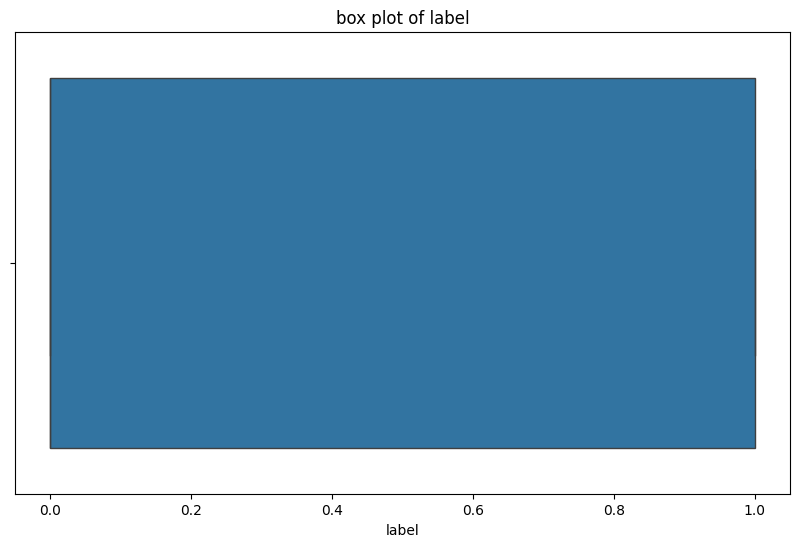

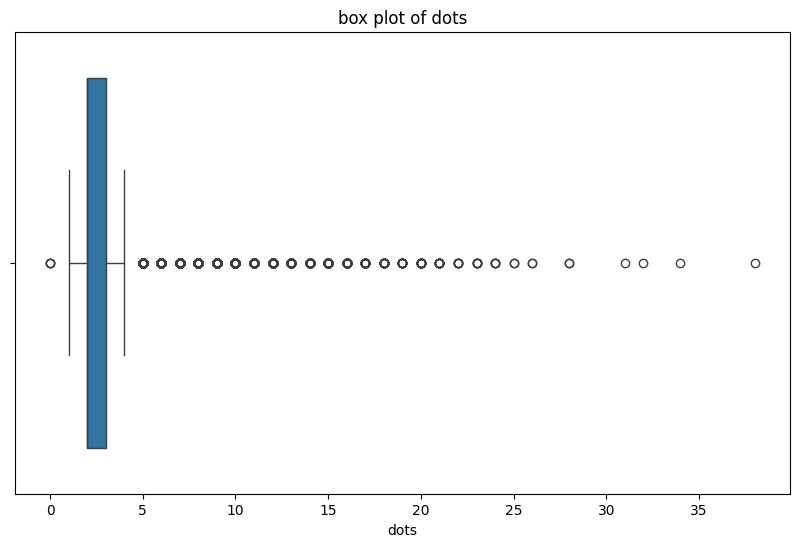

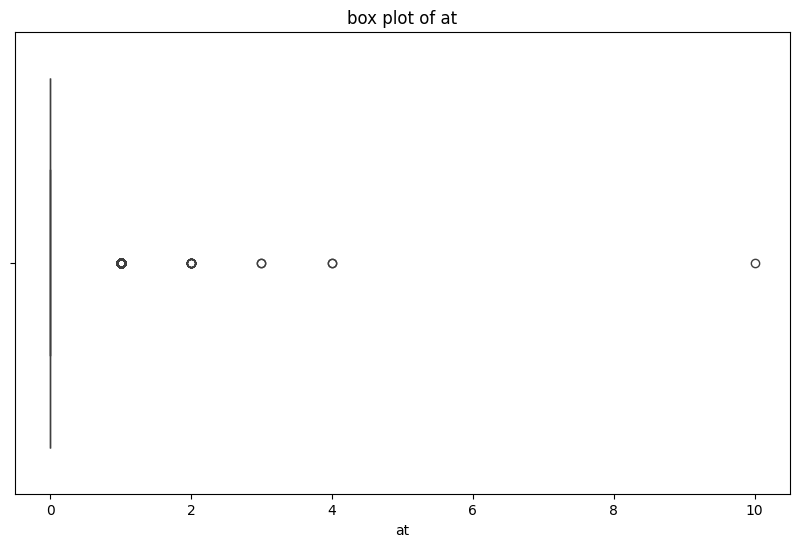

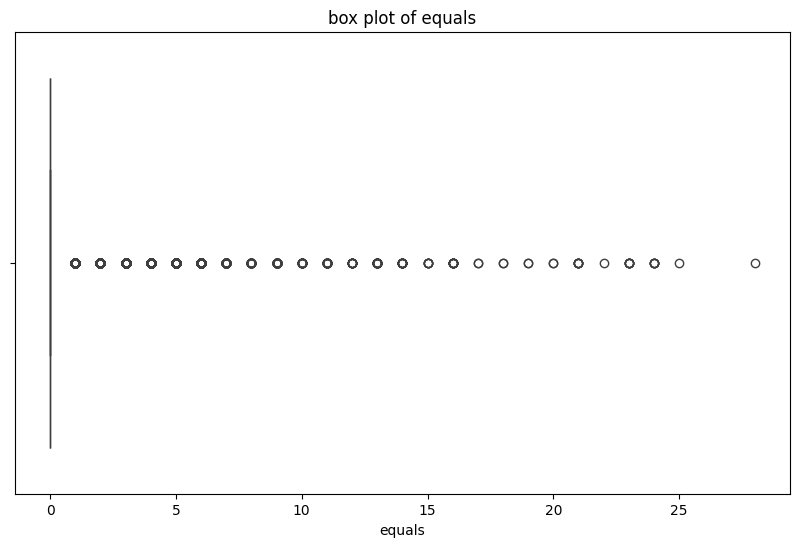

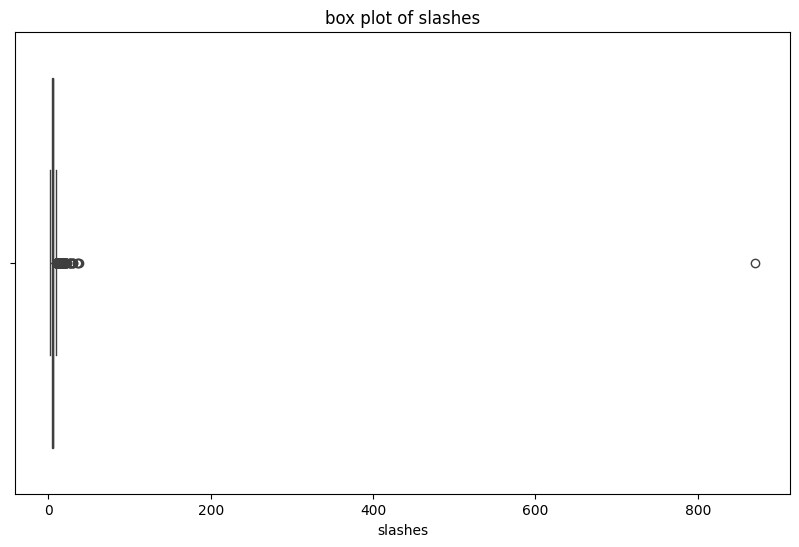

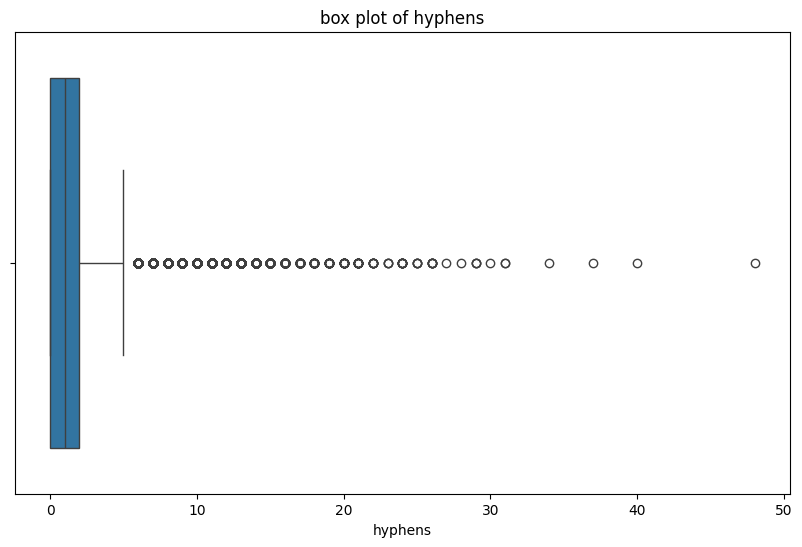

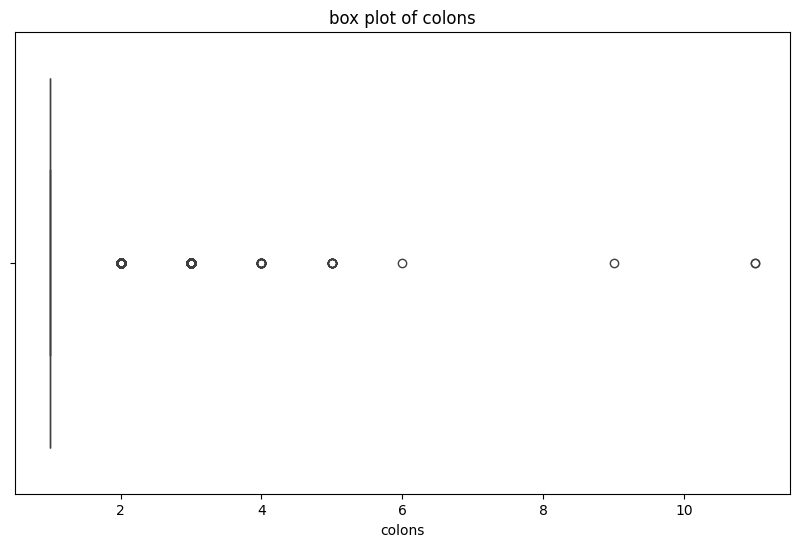

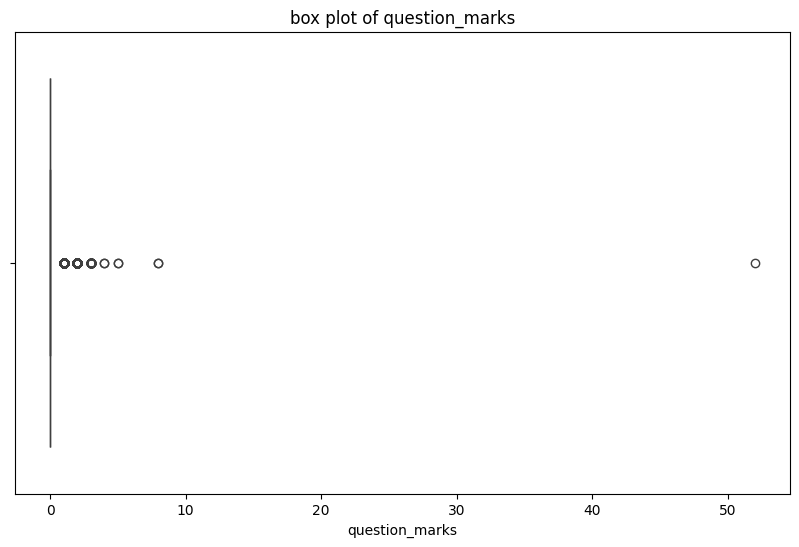

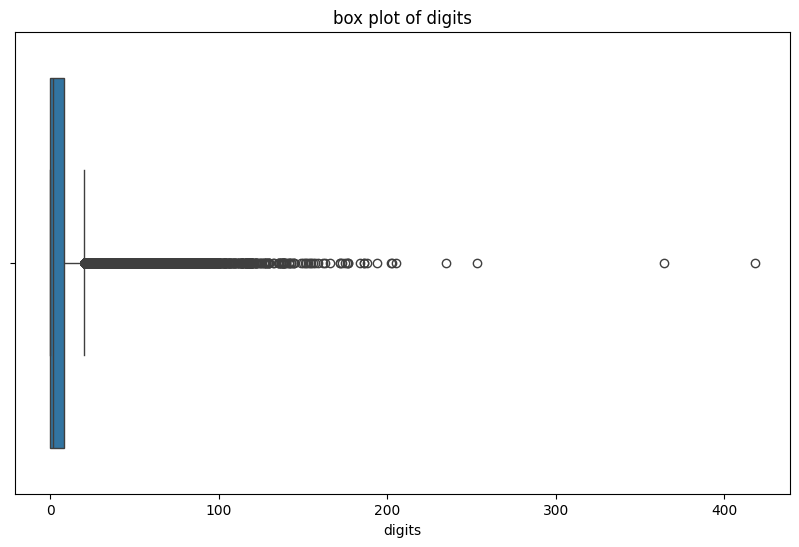

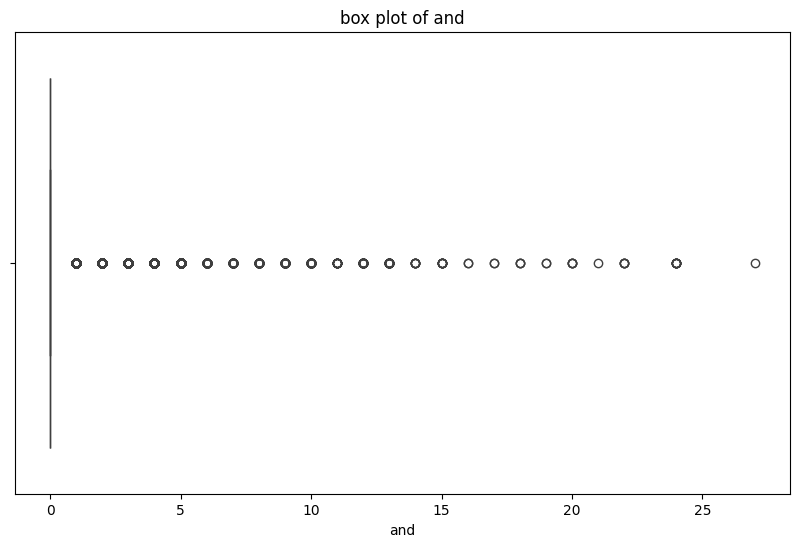

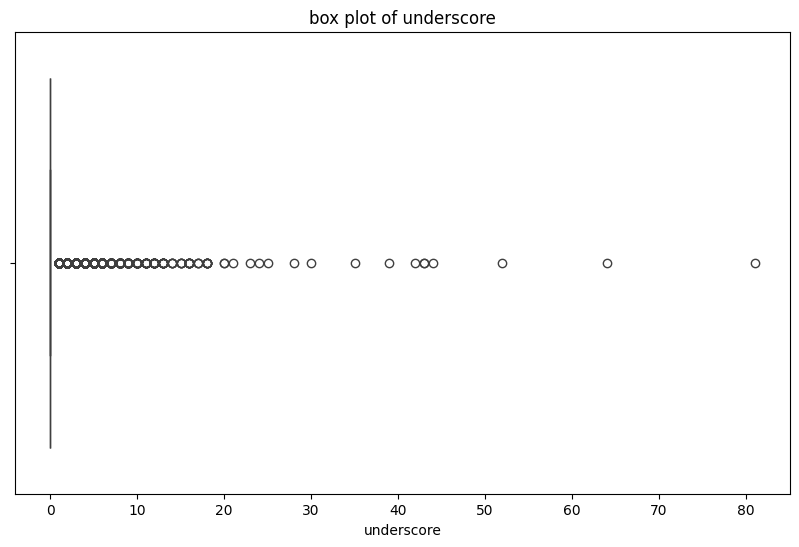

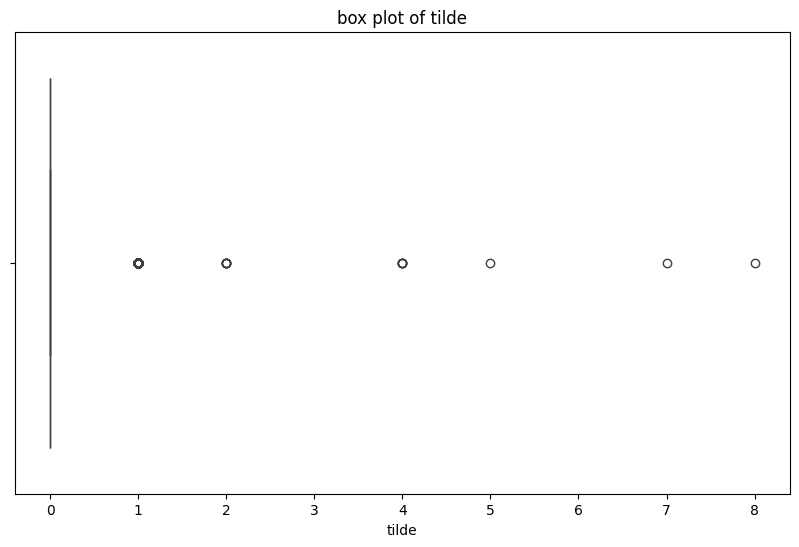

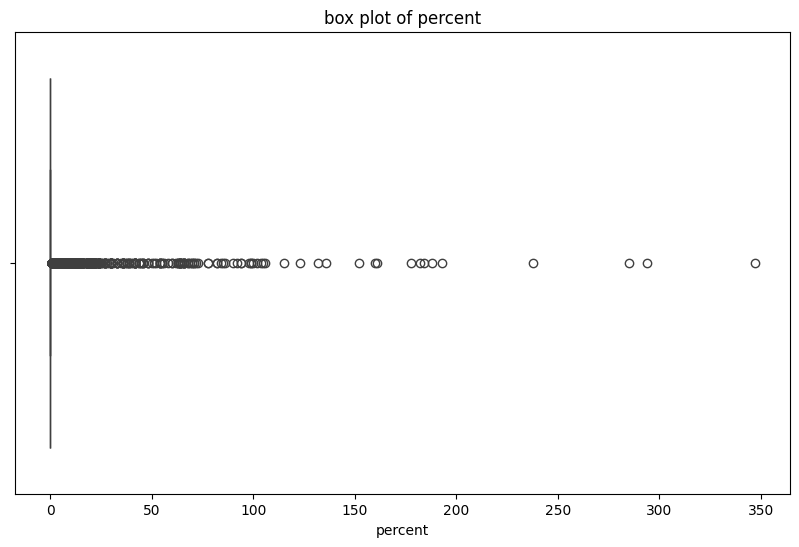

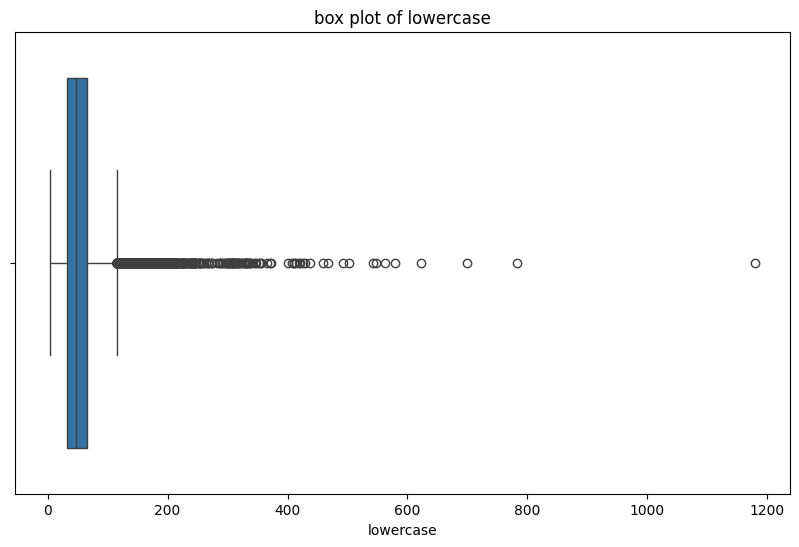

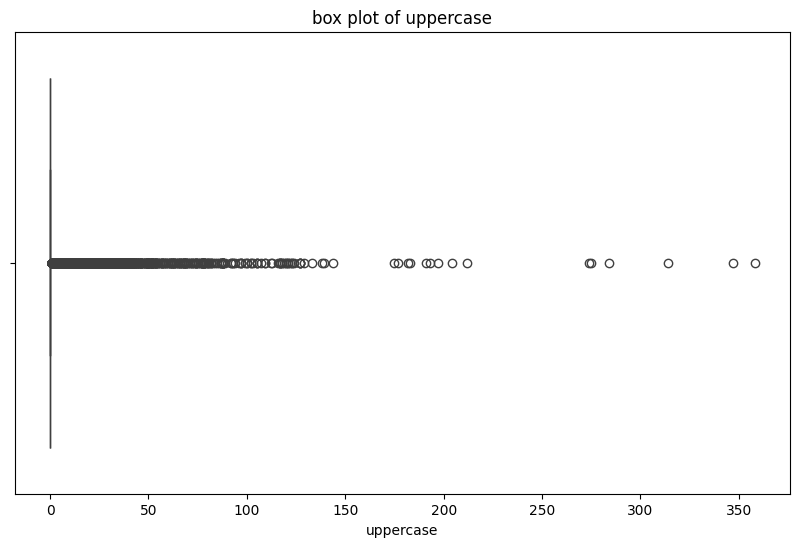

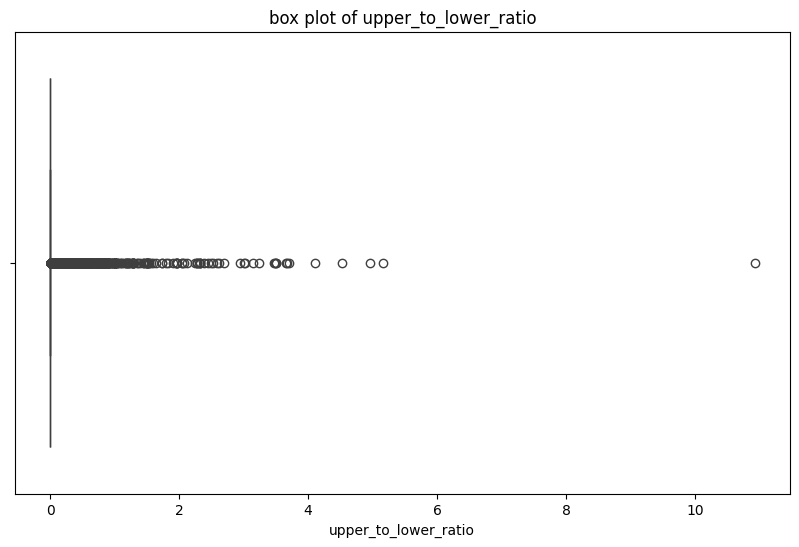

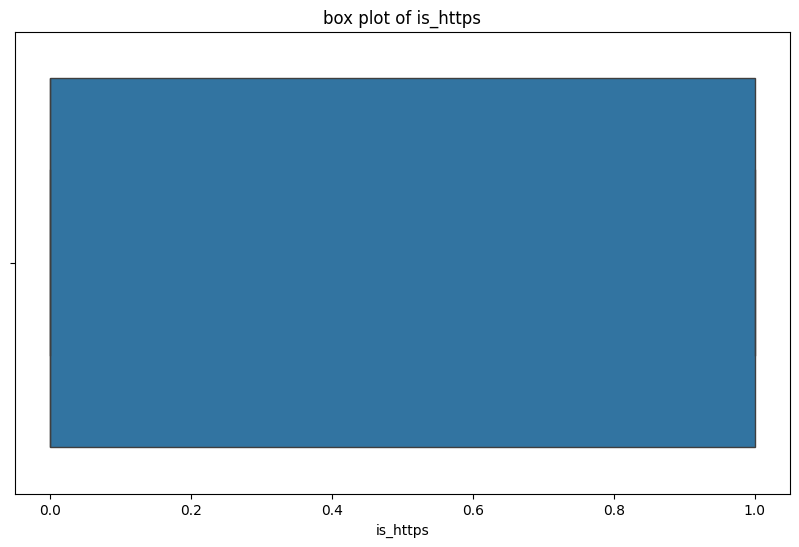

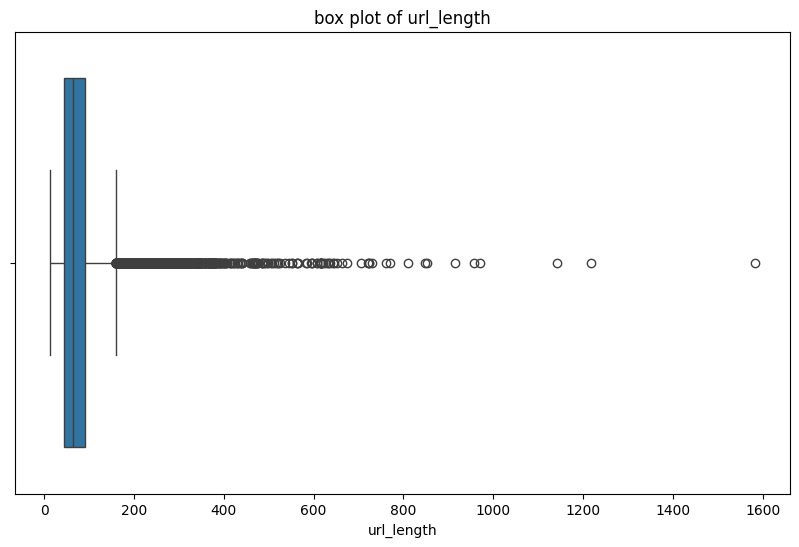

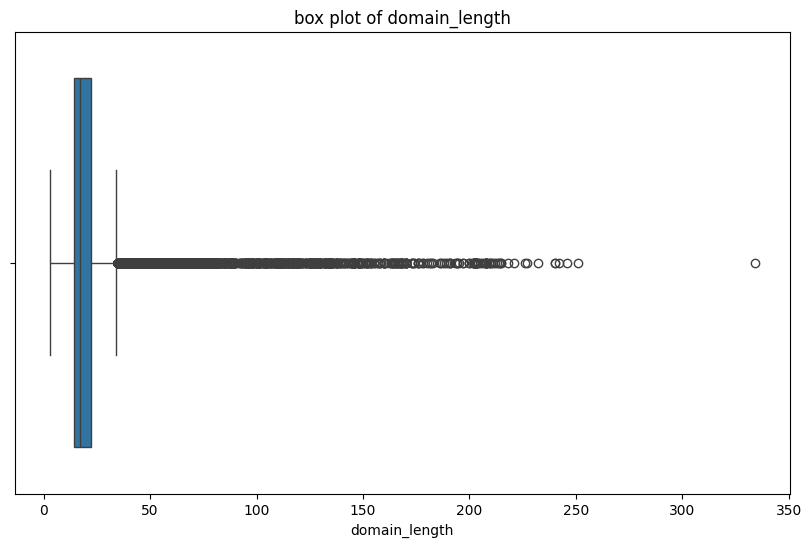

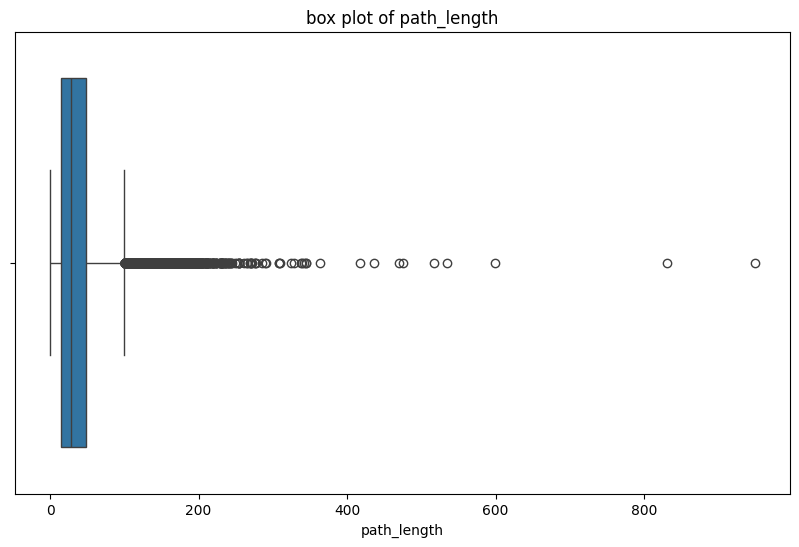

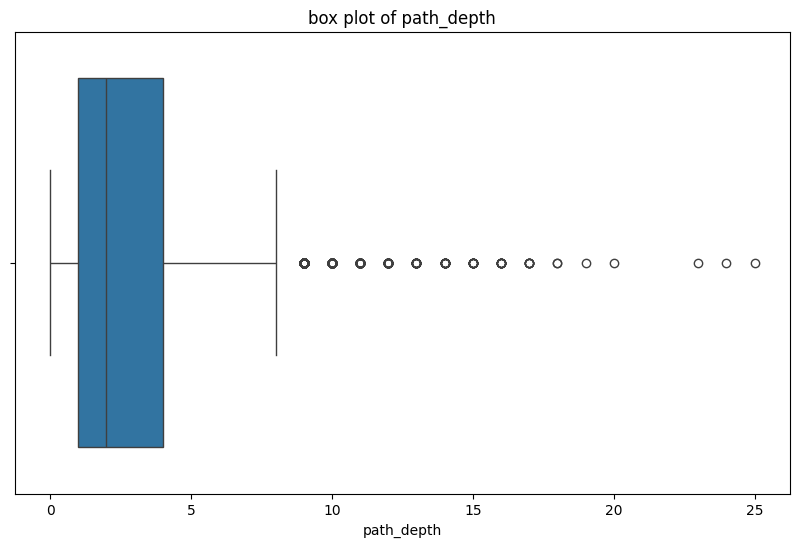

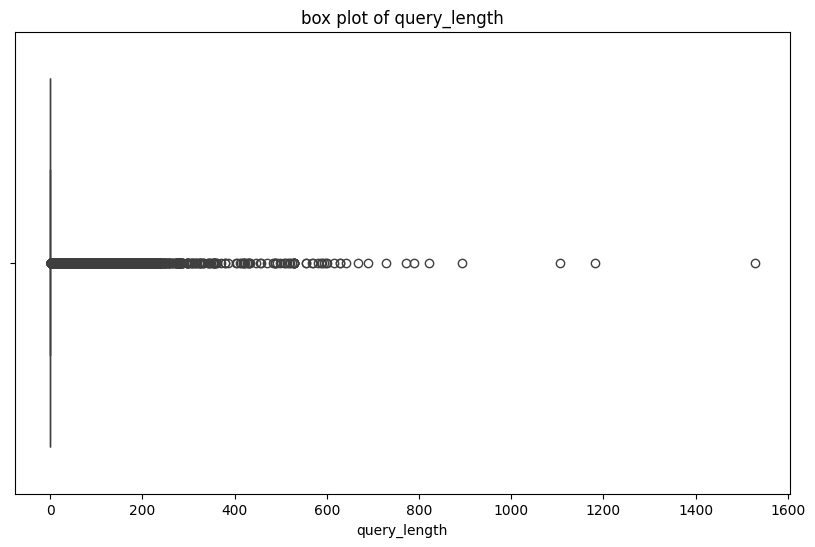

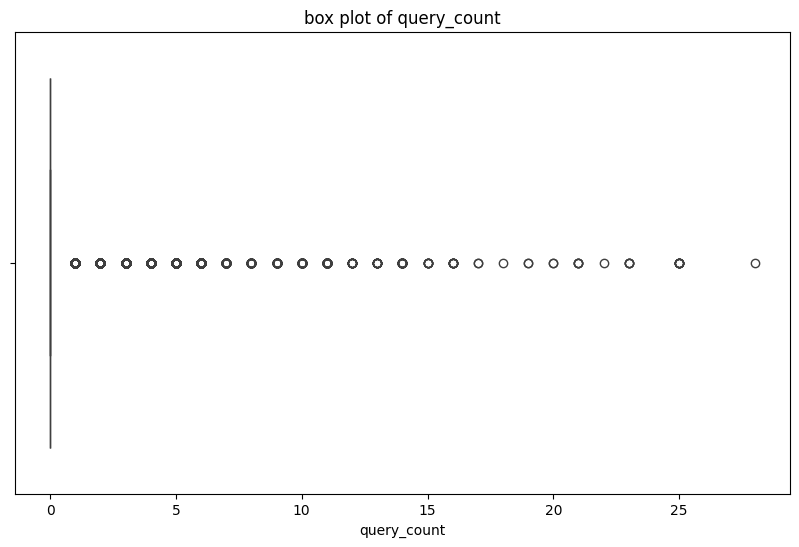

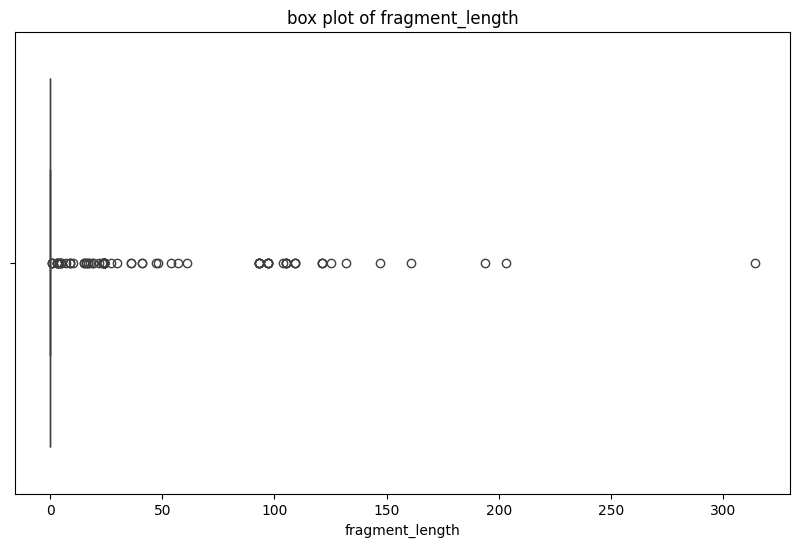

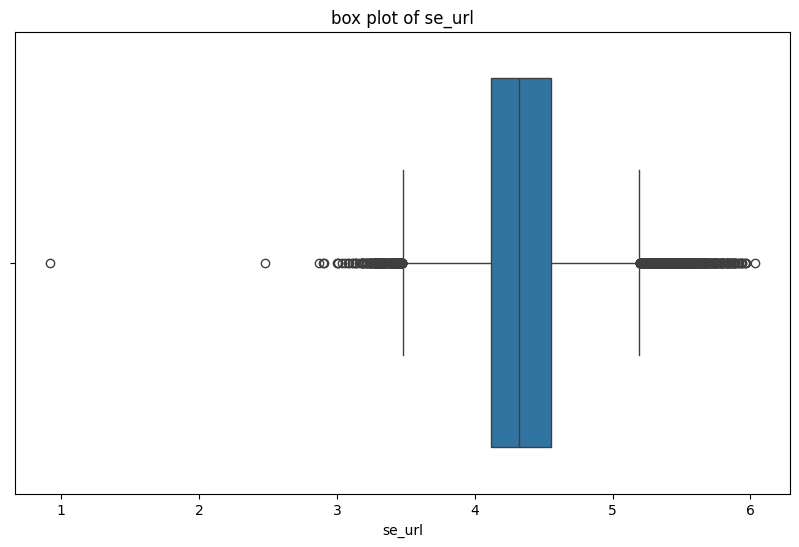

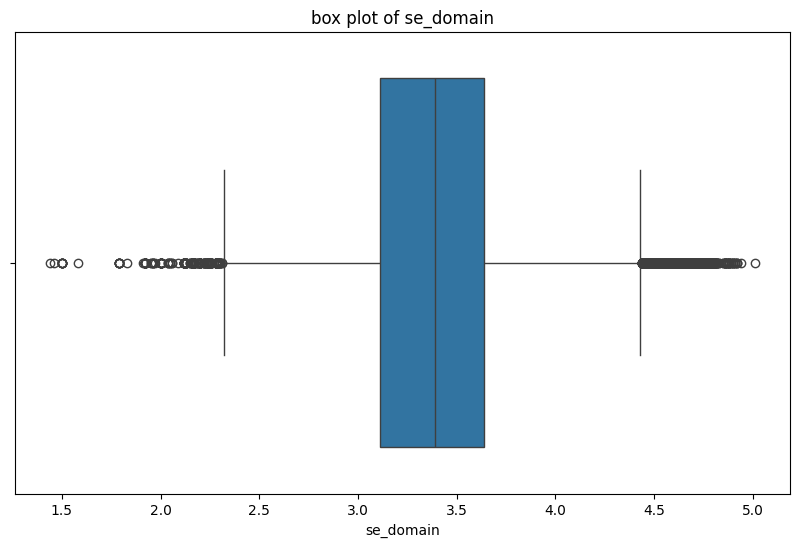

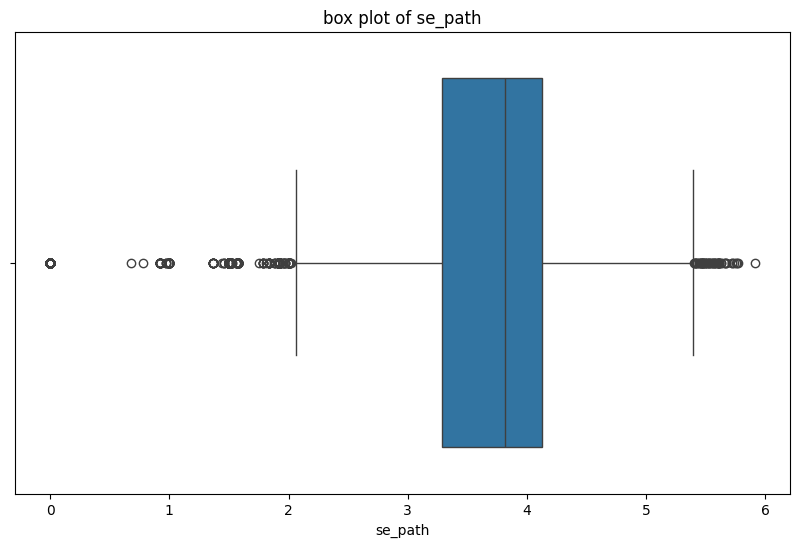

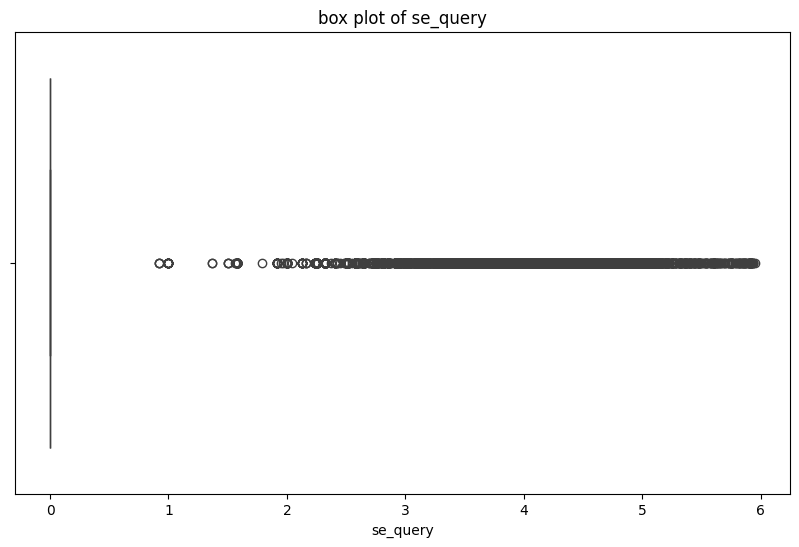

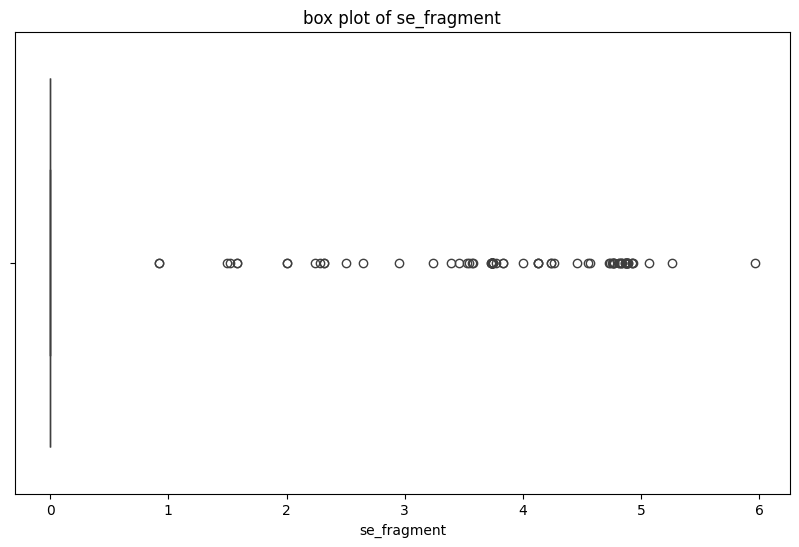

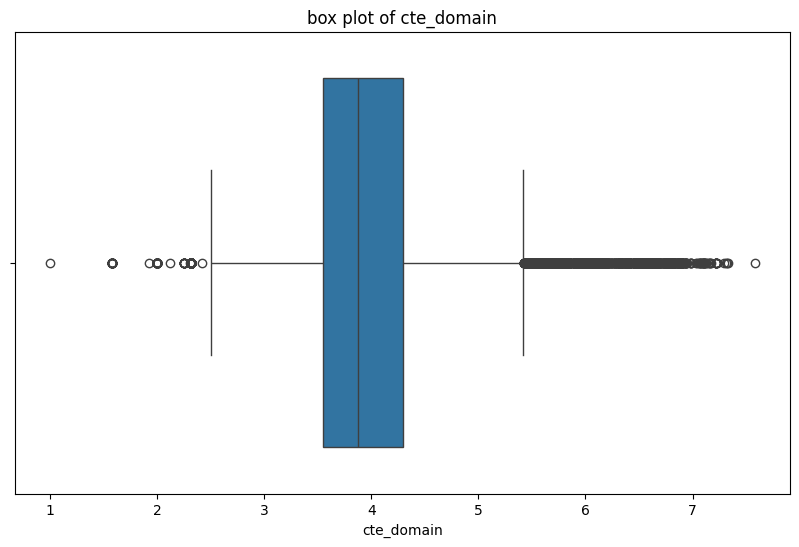

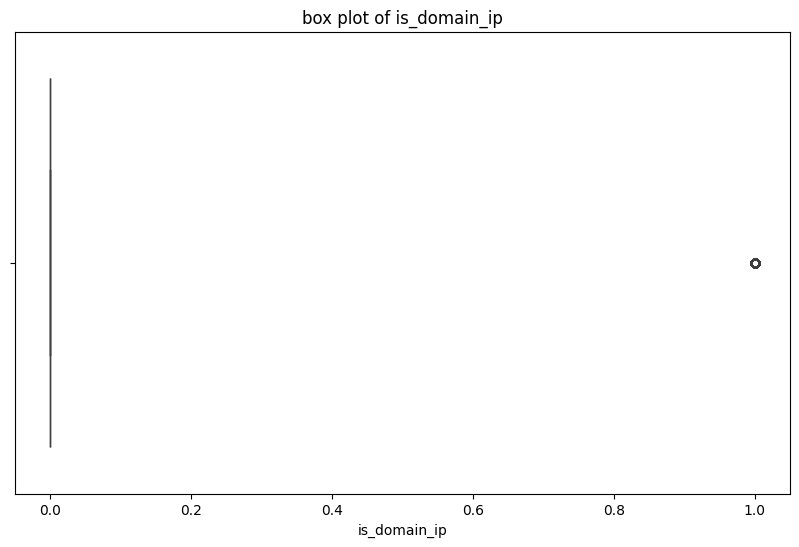

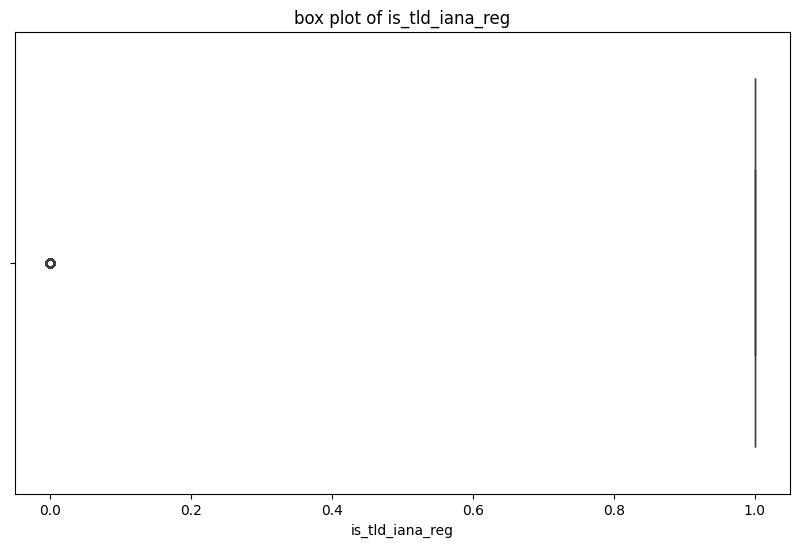

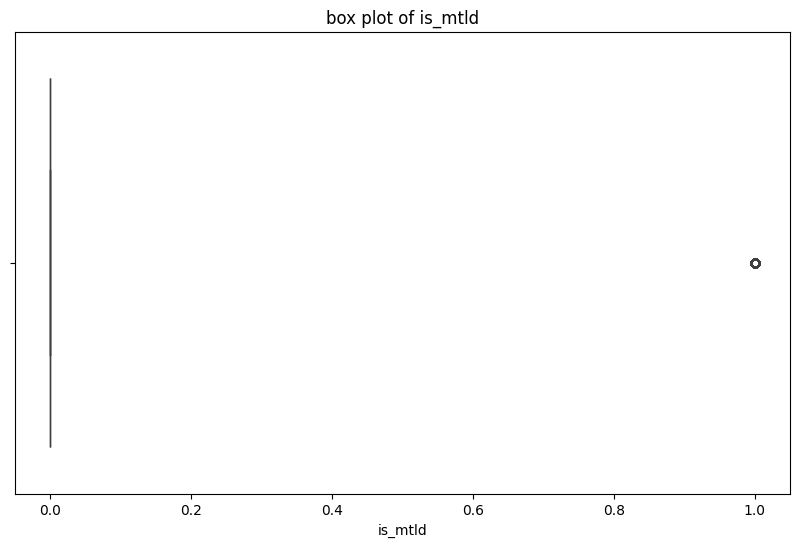

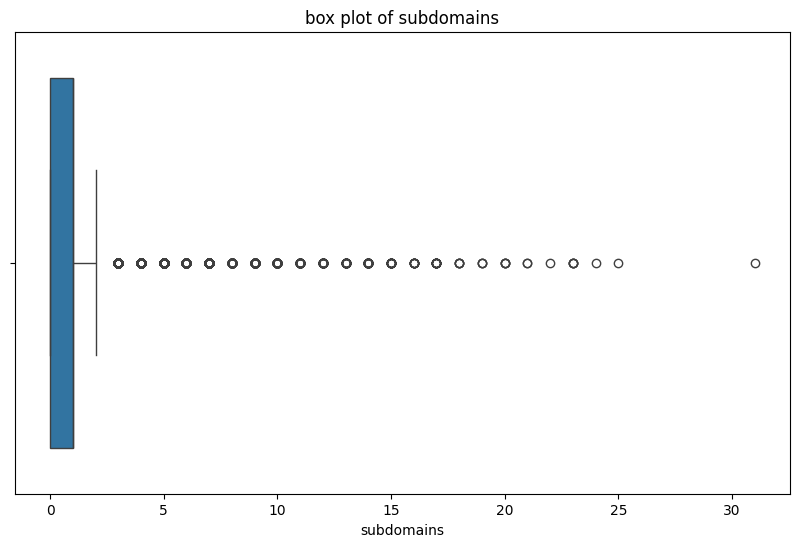

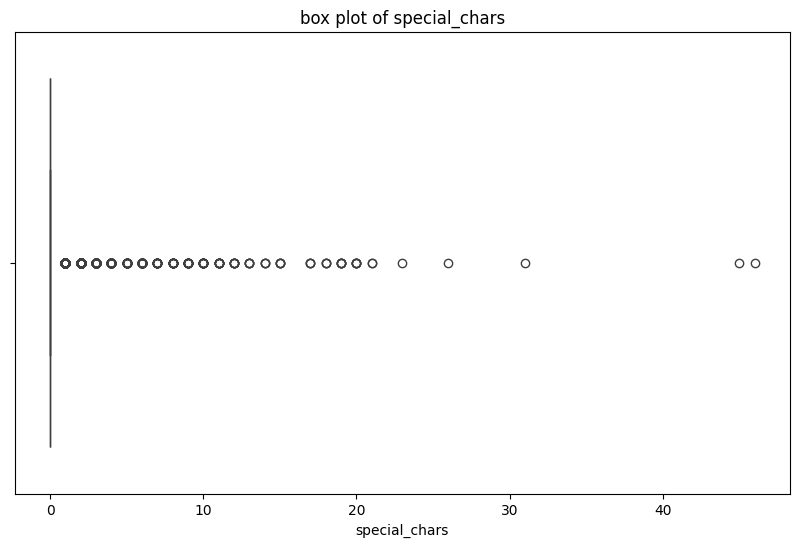

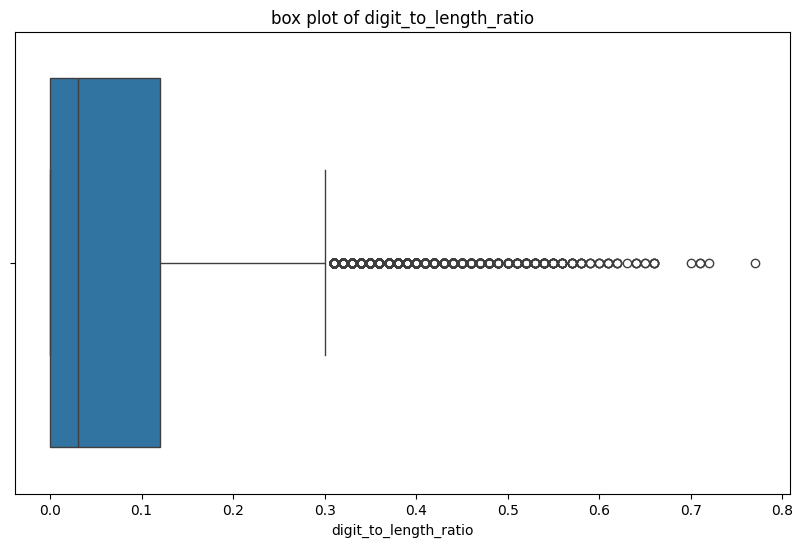

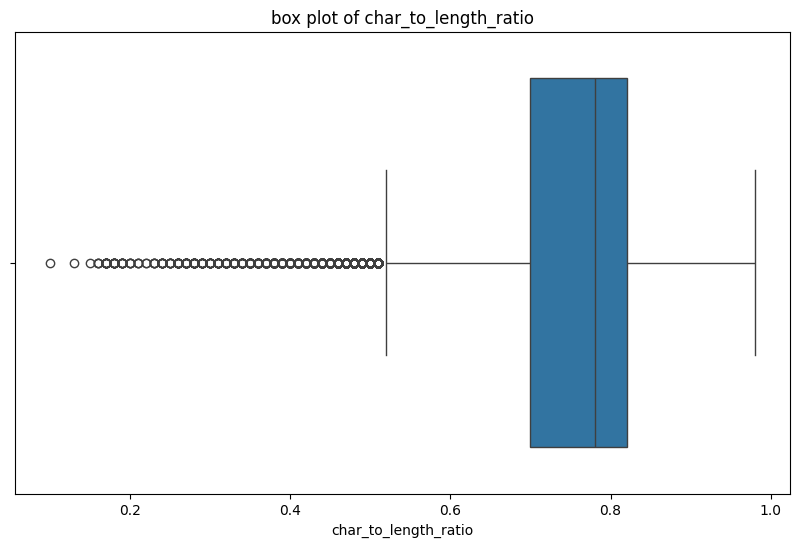

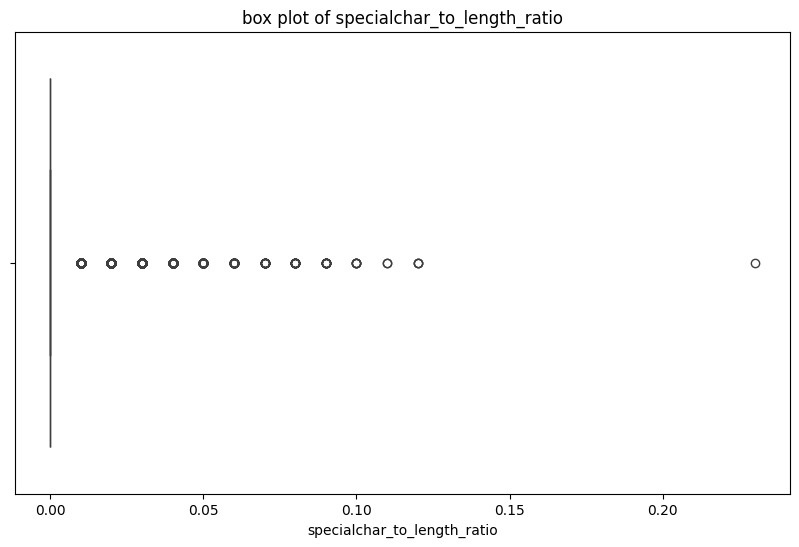

In [ ]:
numeric_features = df.select_dtypes(include=np.number).columns

for feature in numeric_features:
  plt.figure(figsize=(10, 6))
  sns.boxplot(x=df[feature])
  plt.title(f'box plot of {feature}')
  plt.show()

### Memeriksa Imbalance Target Class

Distribusi label diperiksa untuk mengetahui apakah jumlah data pada kelas 0 dan 1 seimbang. Hasil ini penting karena ketidakseimbangan kelas dapat memengaruhi performa model, terutama pada metrik recall dan precision.

Class distribution of 'label' column:
label
0.0    1437933
1.0    1121557
Name: count, dtype: int64

Class distribution percentages:
label
0.0    56.18045
1.0    43.81955
Name: proportion, dtype: float64


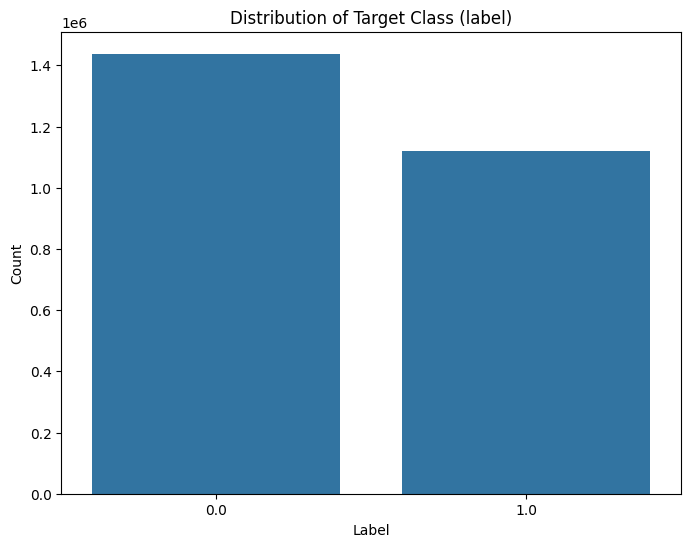

In [37]:
# Calculate value counts and percentages for the 'label' column
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("Class distribution of 'label' column:")
print(label_counts)
print("\nClass distribution percentages:")
print(label_percentages)

# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Target Class (label)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Distribusi antar class dengan label 0 dan 1 masih terbilang seimbang dengan label 0 berkisar 55.5% dari keseluruhan dataset dan label 1 berkisar 44.5% dari dataset, serta tidak perlu dilakukan teknik SMOTE

### Memeriksa skala/persebaran data

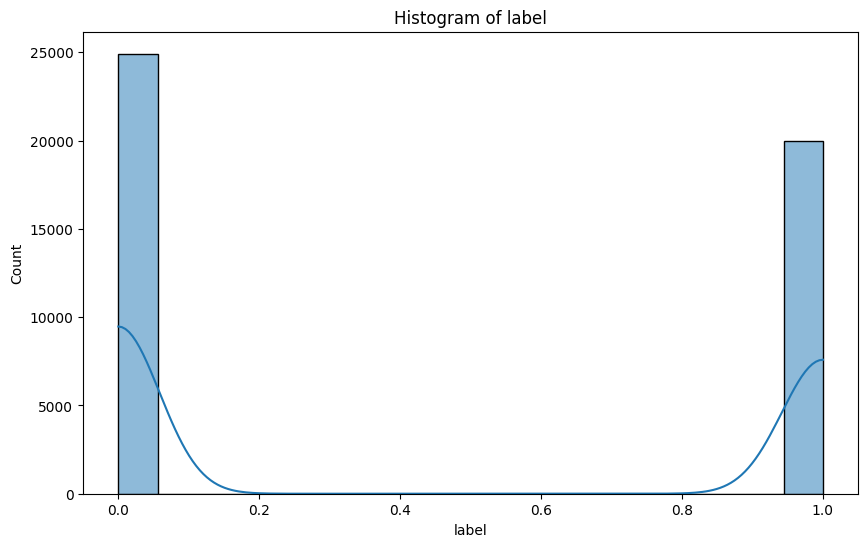

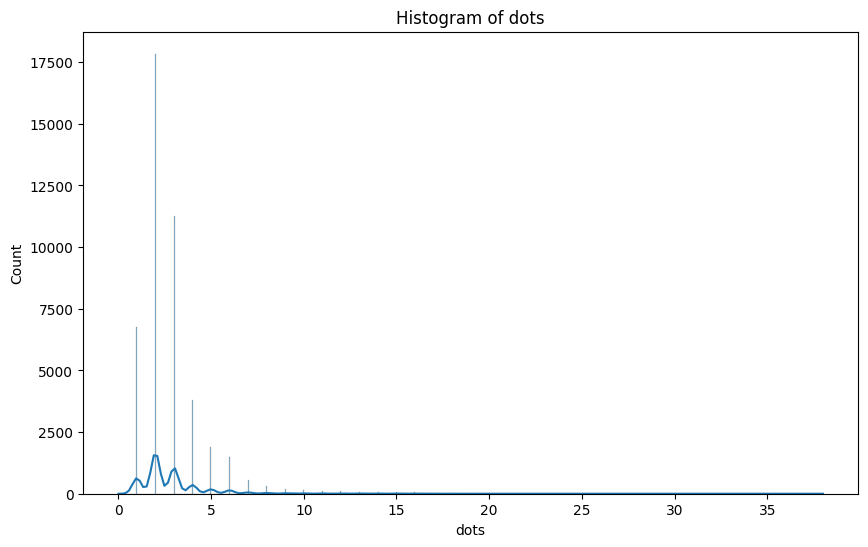

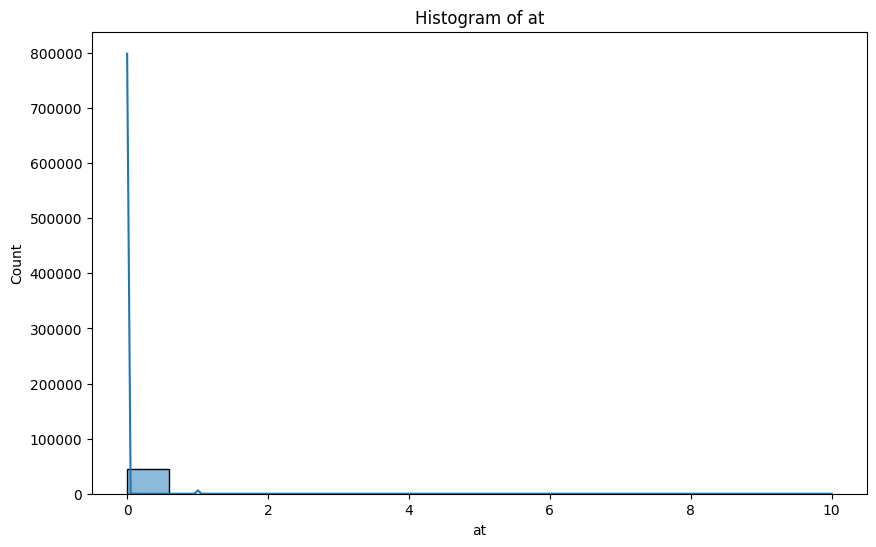

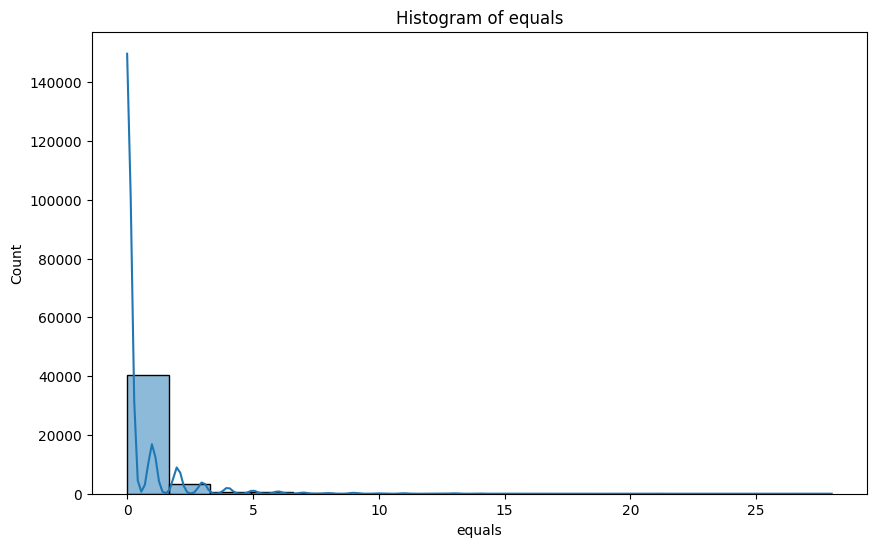

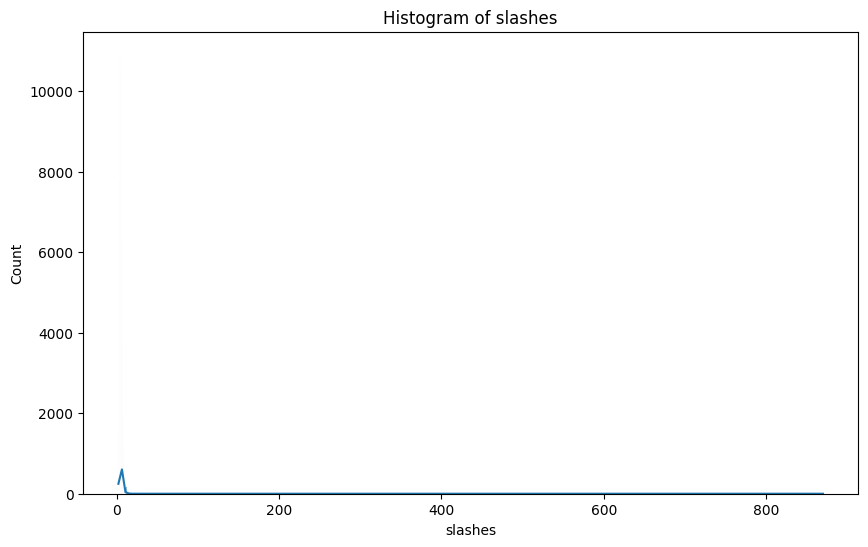

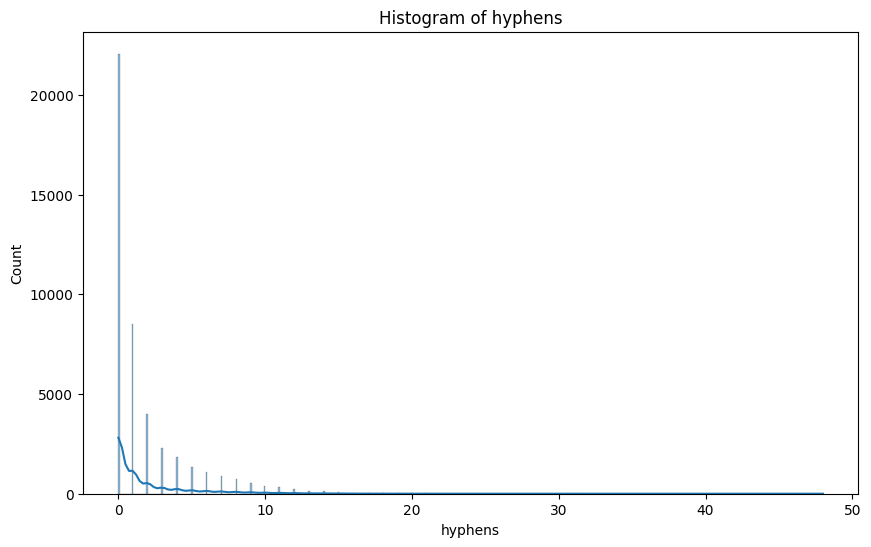

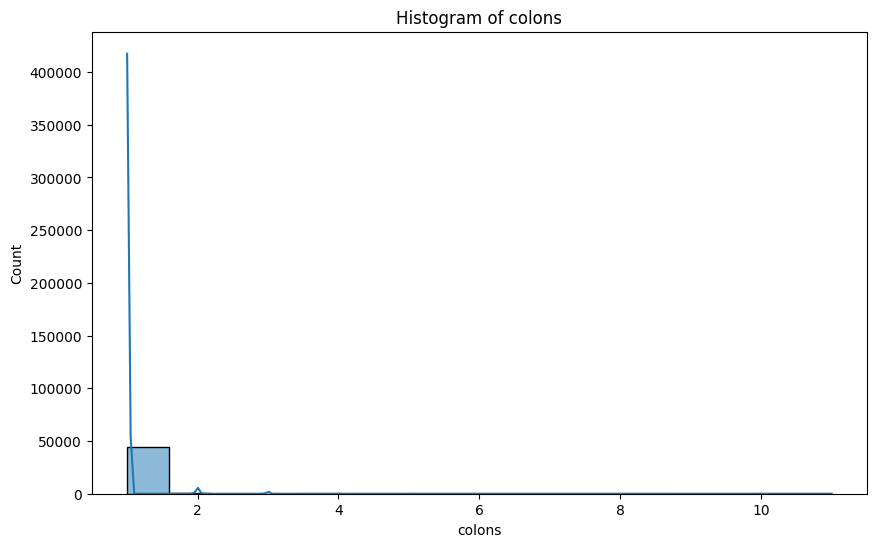

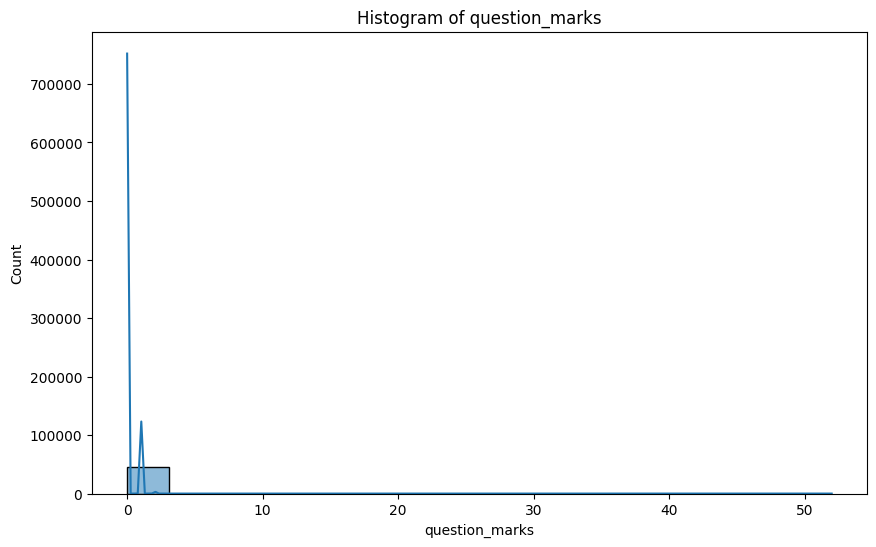

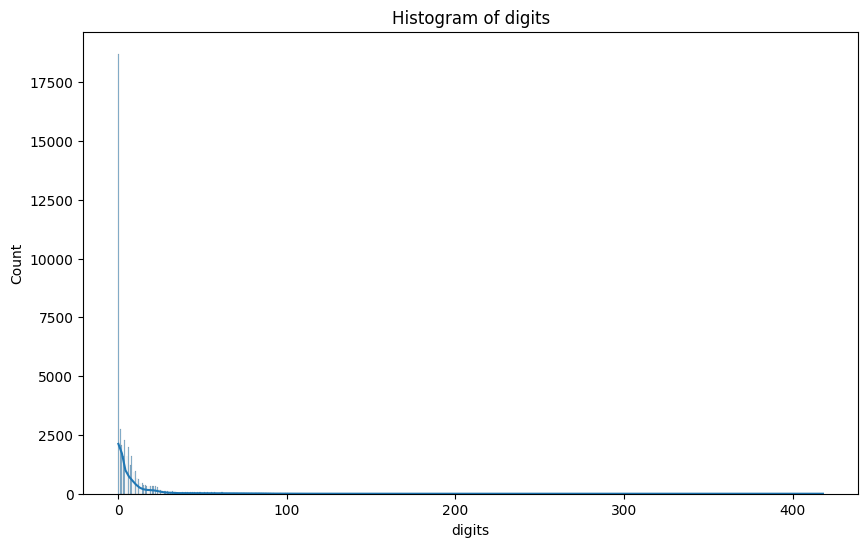

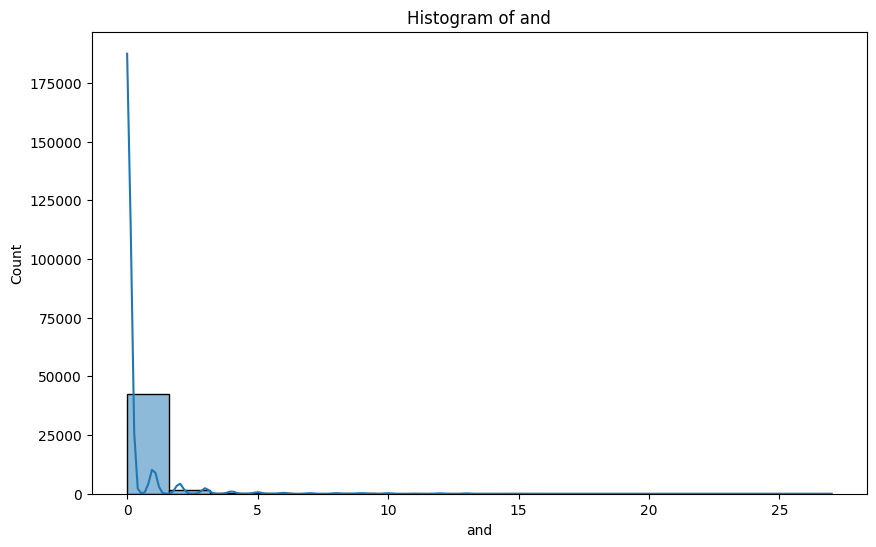

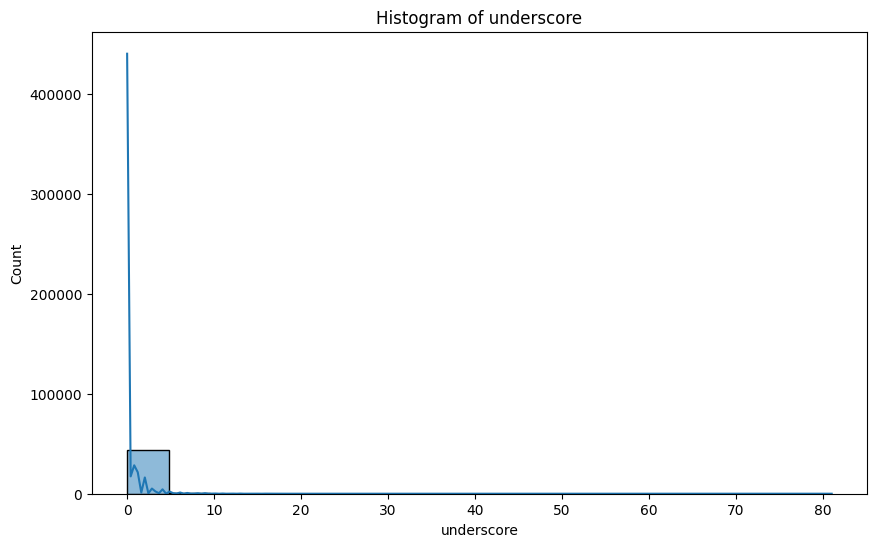

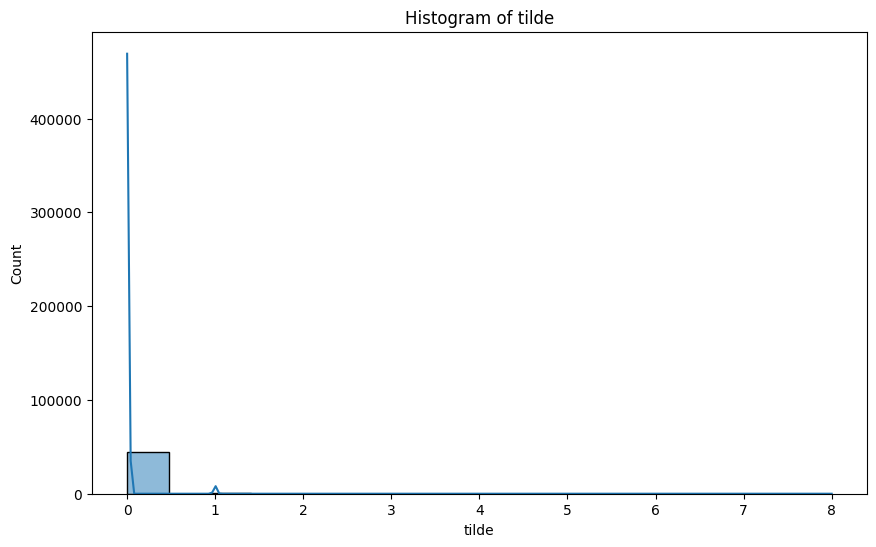

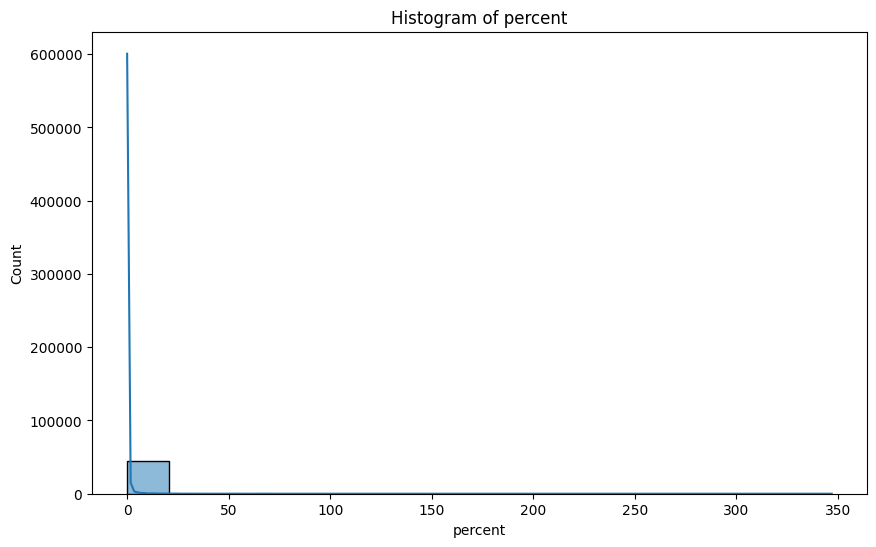

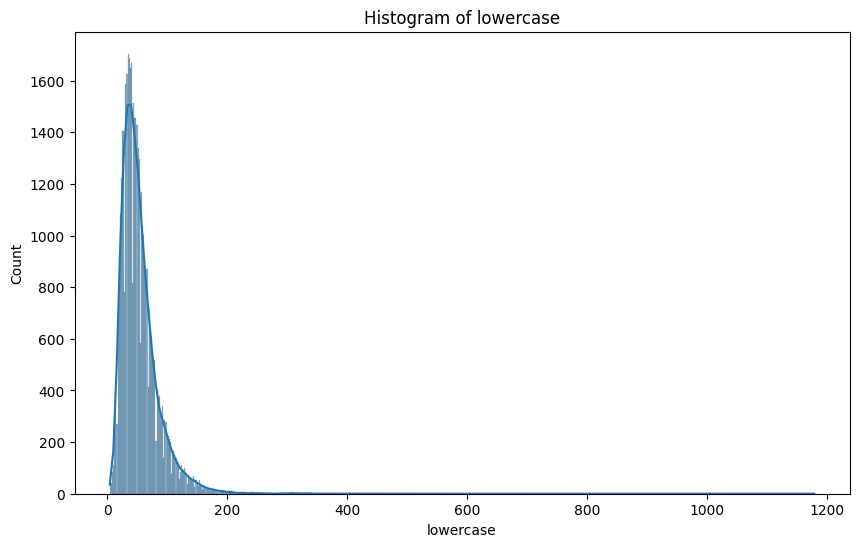

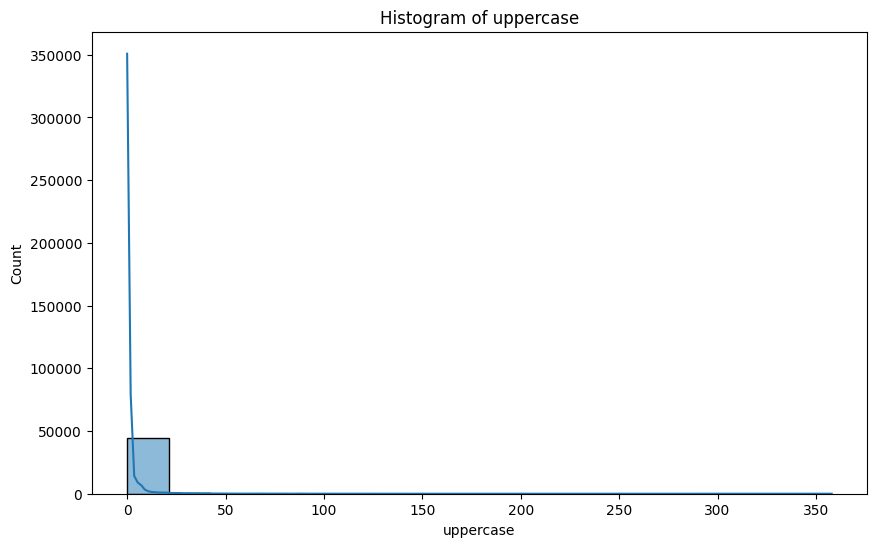

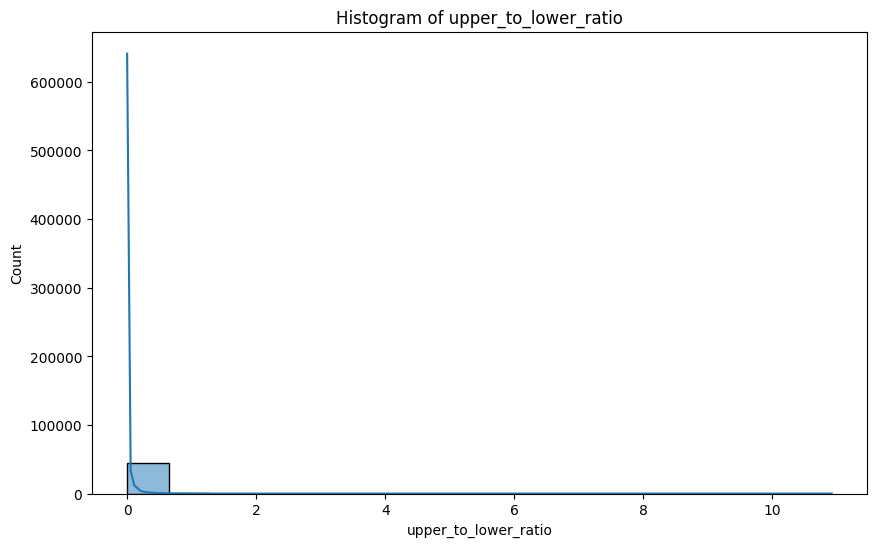

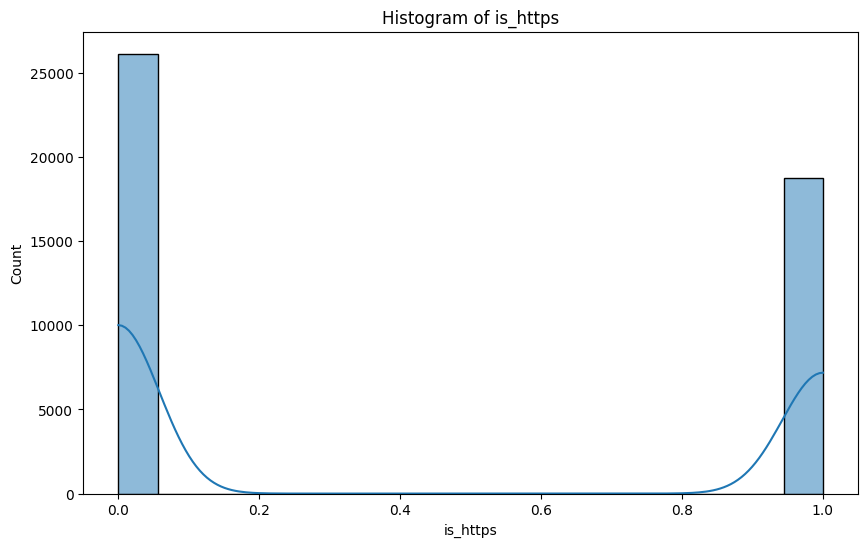

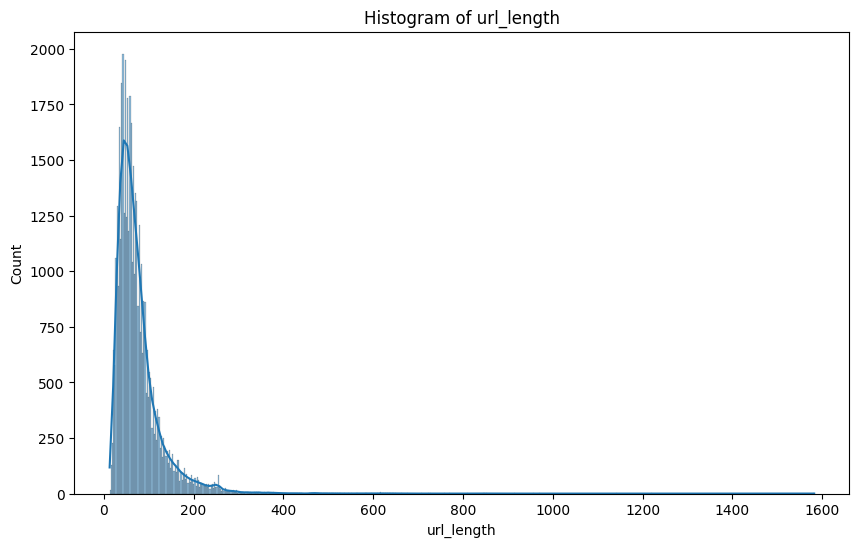

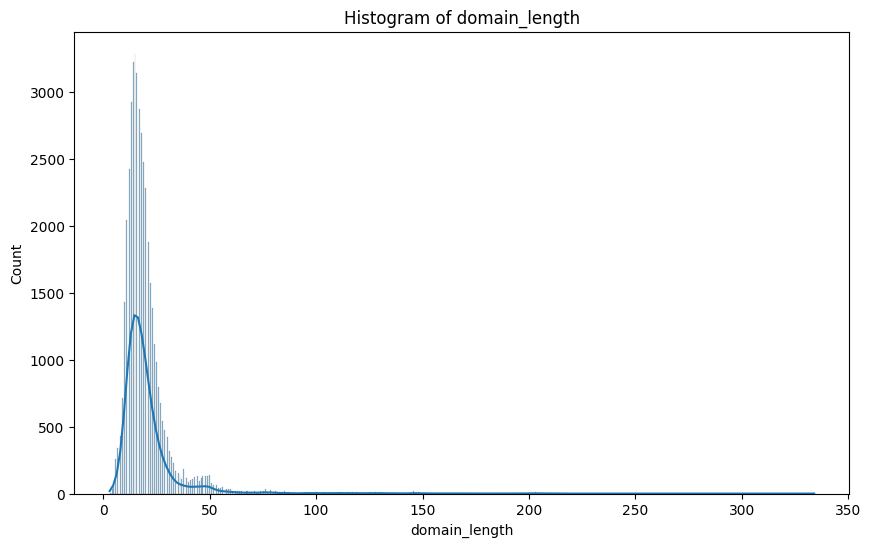

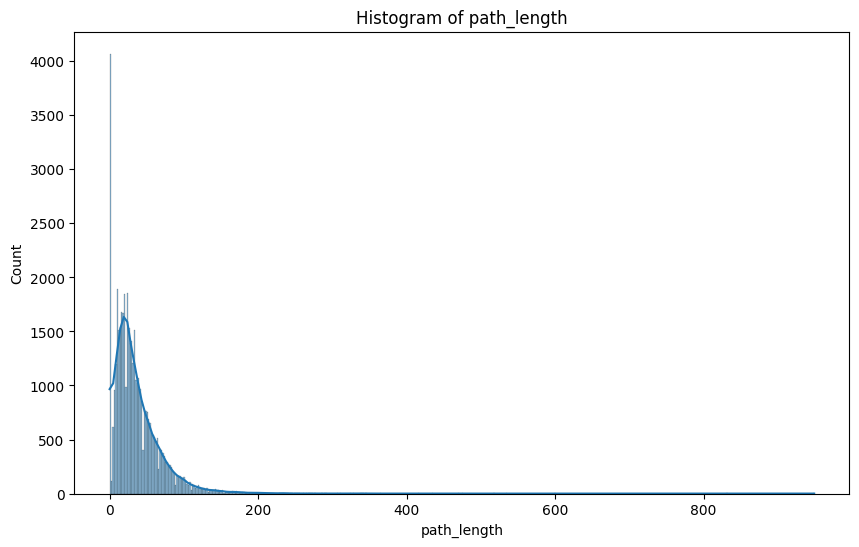

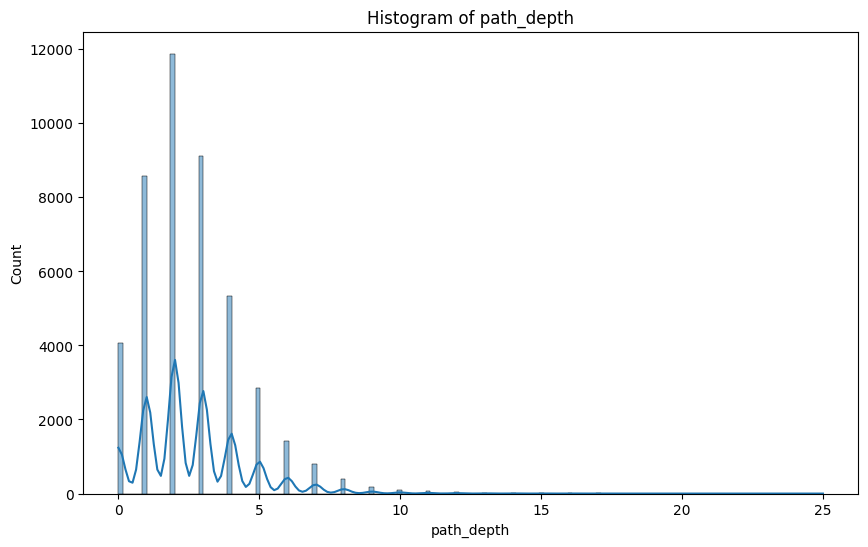

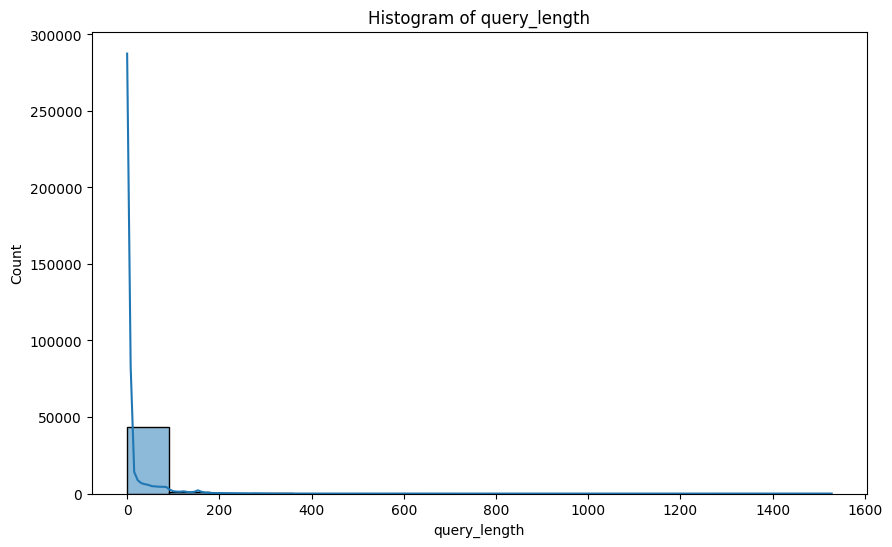

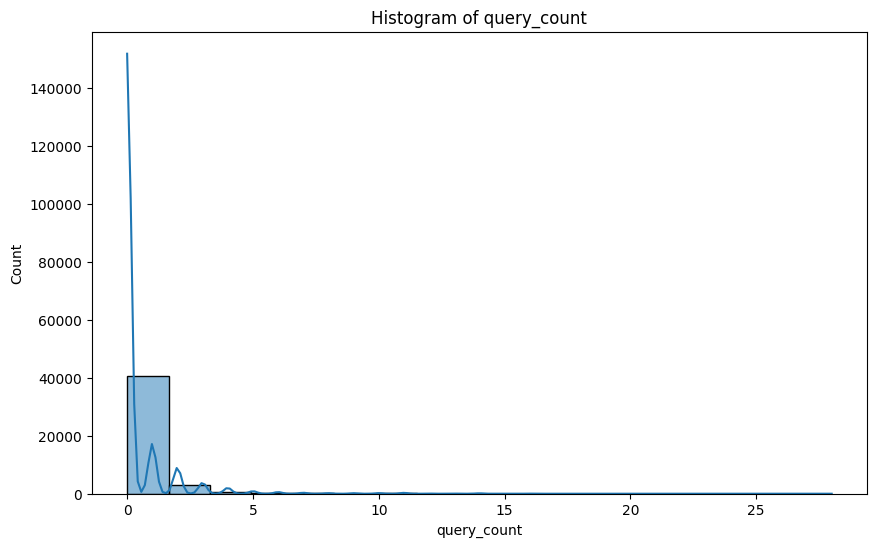

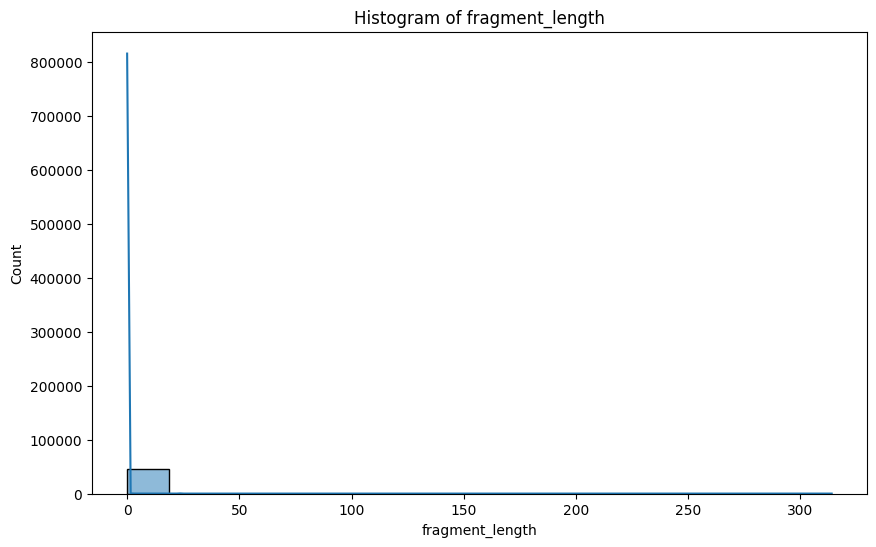

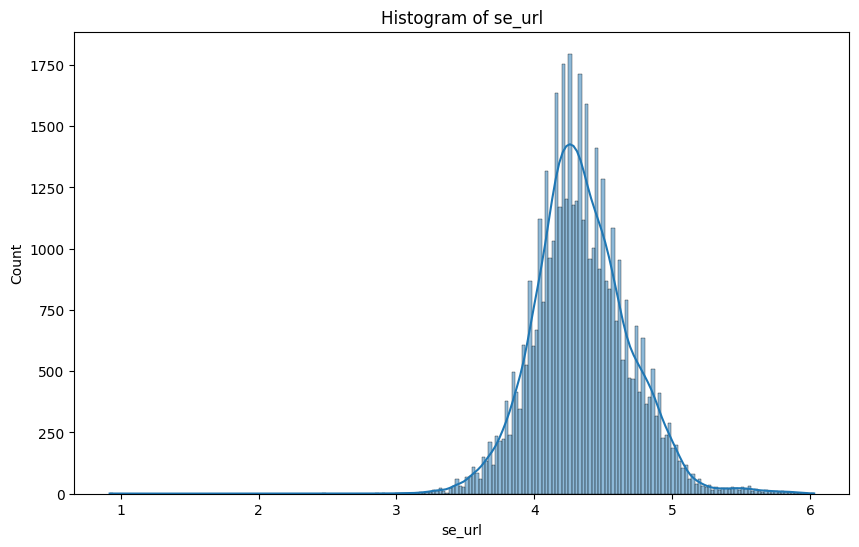

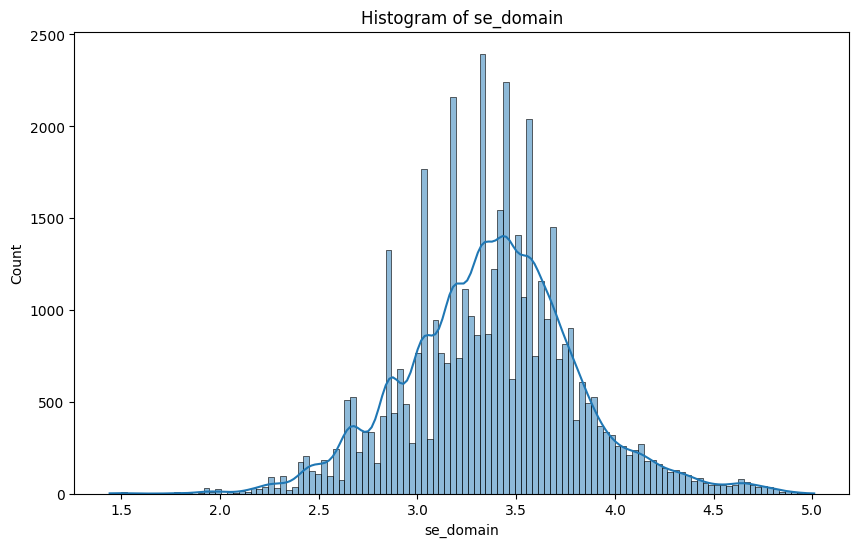

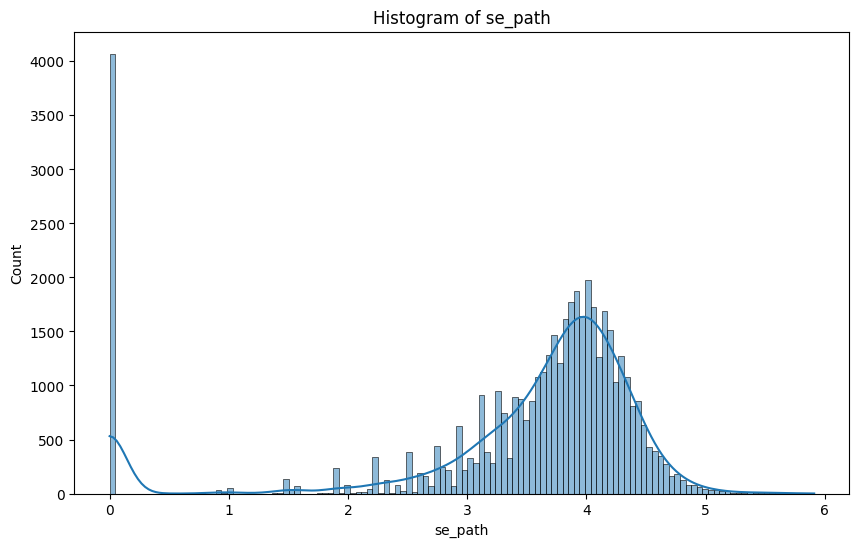

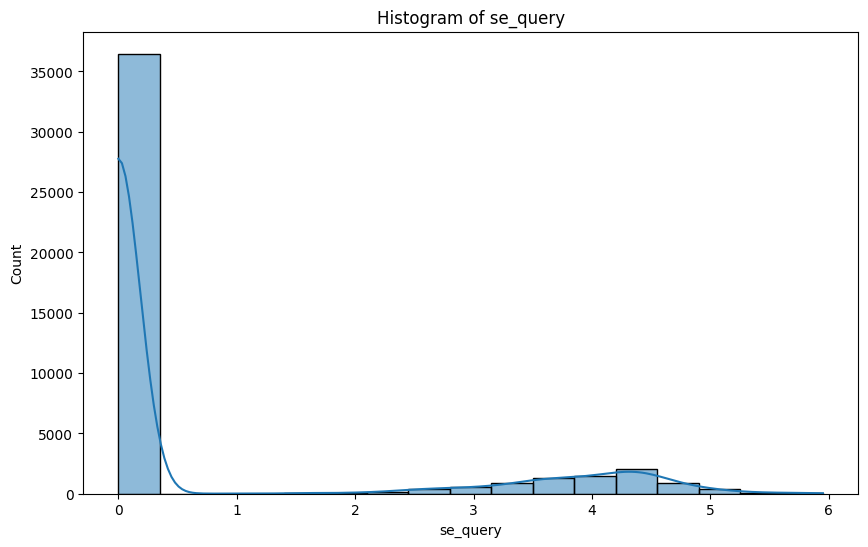

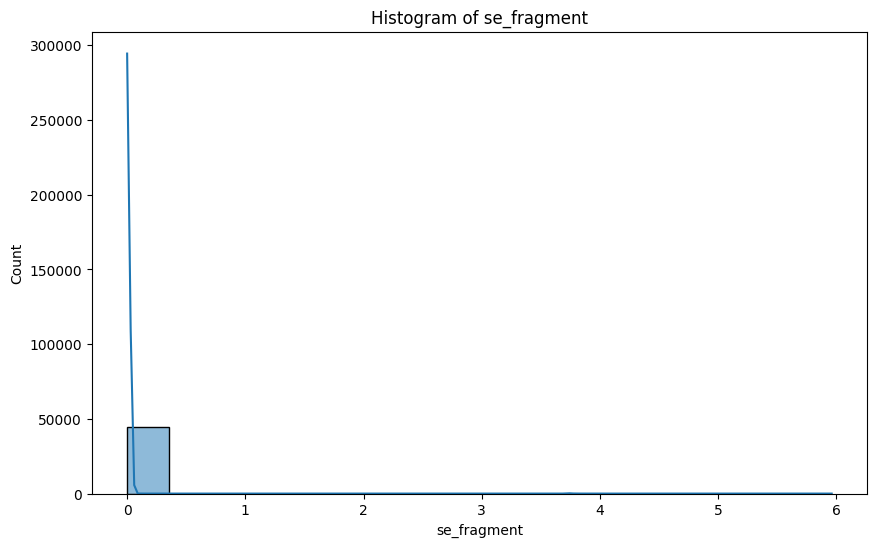

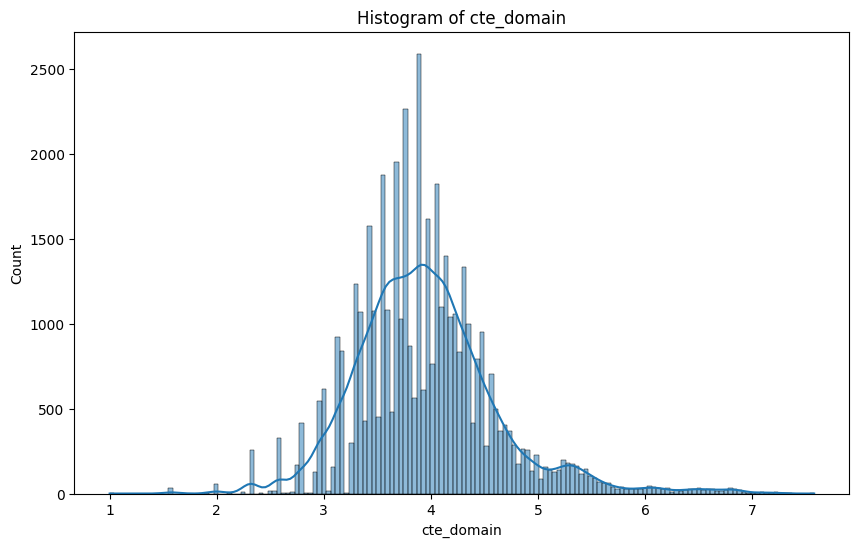

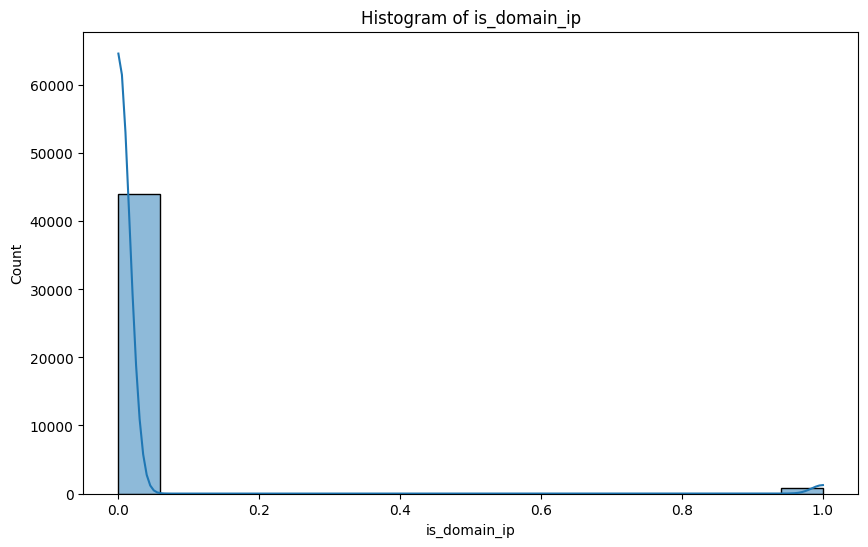

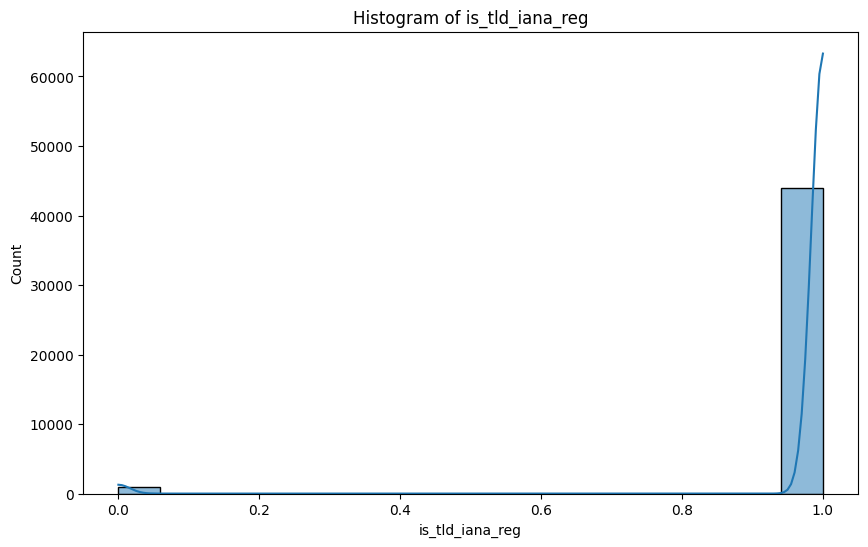

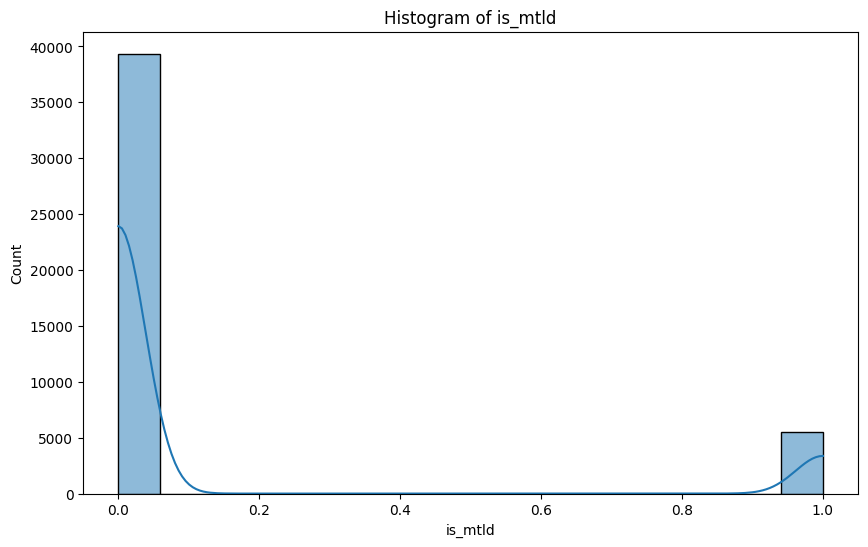

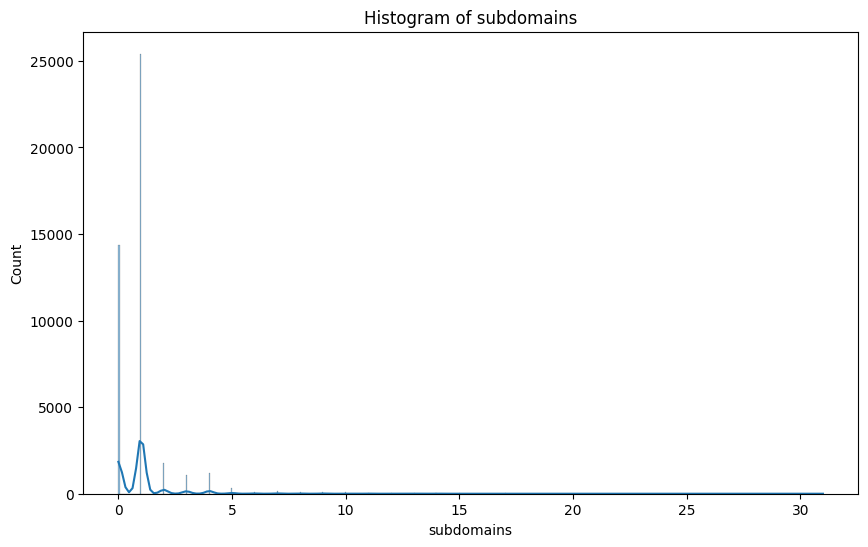

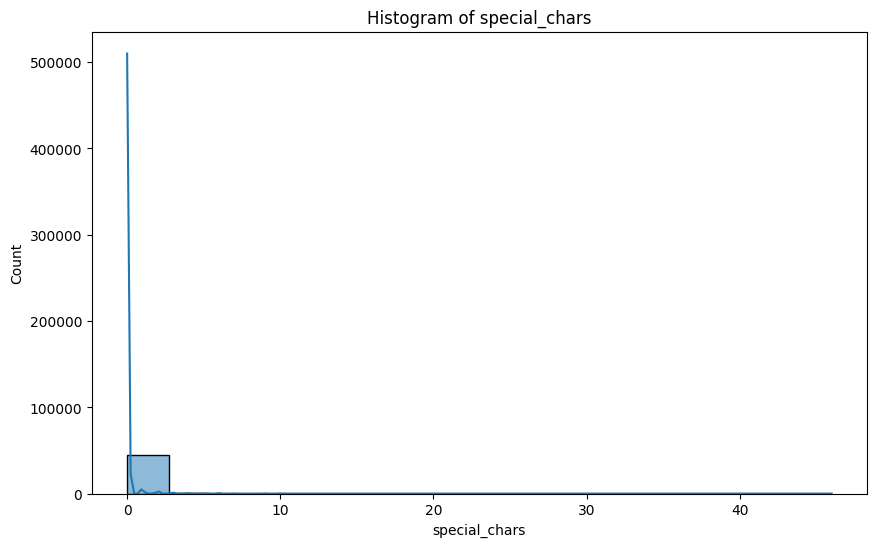

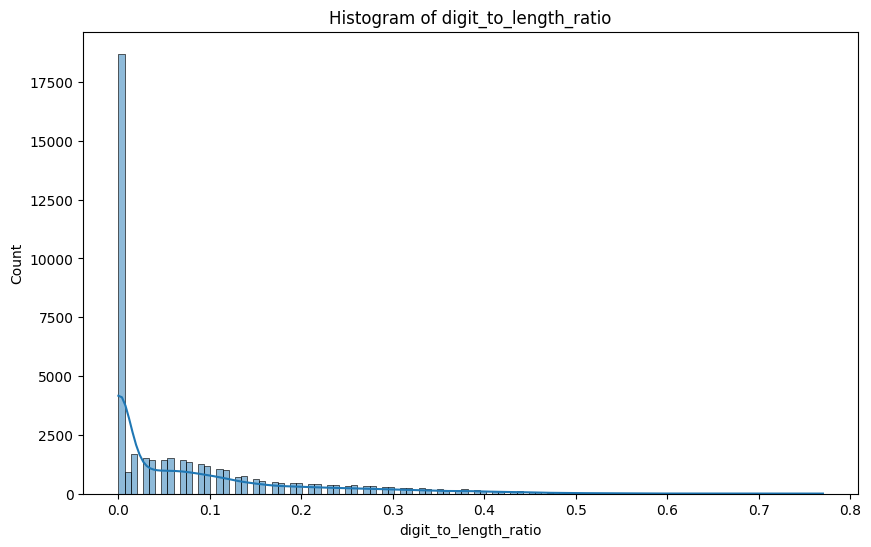

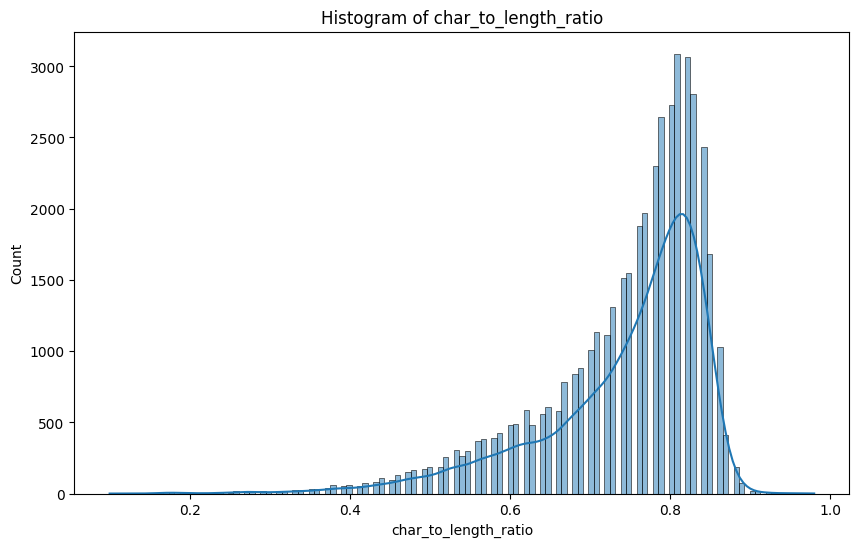

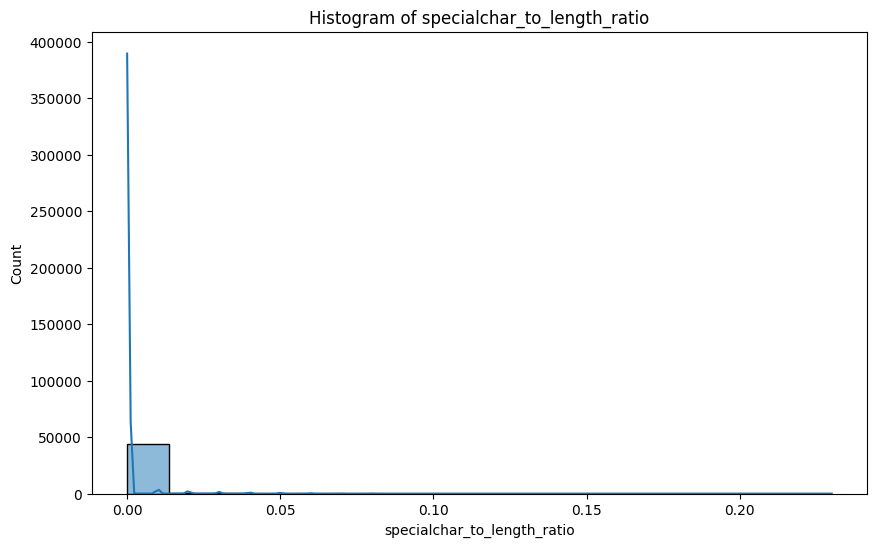

In [ ]:
for feature in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.show()

### Data Splitting

Dataset dibagi menjadi data training dan testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model pada data yang belum pernah dilihat sebelumnya. Pembagian dilakukan dengan stratify agar proporsi label 0 dan 1 tetap terjaga pada kedua subset.
pada X label dan url di drop karena label merupakan fitur target dan url merupakan kolom yang mempunyai nilai unik pada setiap baris nya

In [38]:
# Memisahkan fitur (X) dan target (Y)
X = df.drop(columns=['label', 'url'])
y = df['label']

dataset dibagi menjadi 80% untuk training dan 20% untuk testing

In [39]:
# Membagi dataset menjadi training dan testing

# train size = 80% test_size = 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print("Jumlah data untuk target: ", len(X))
print("Jumlah data train untuk target: ", len(X_train))
print("Jumlah data test untuk target: ", len(X_test))

Jumlah data untuk target:  2559490
Jumlah data train untuk target:  2047592
Jumlah data test untuk target:  511898


### Melihat data yang perlu dilakukan encoding

In [40]:
category_features = X_train.select_dtypes(include=['object']).columns
X_train[category_features]

,tld
1340195,com
787290,com
1540464,com
1446580,com
1078536,com
...,...
120021,es
467016,net
129687,info
2001568,com


### Melakukan Frequency encoding

Kolom `tld` merupakan fitur kategorikal, sehingga perlu diubah menjadi bentuk numerik sebelum digunakan oleh model. Pada proyek ini digunakan frequency encoding, yaitu mengubah setiap nilai TLD menjadi frekuensi kemunculannya pada data training. Teknik ini dipilih karena lebih hemat memori dibandingkan one-hot encoding pada dataset berukuran
  besar.

In [41]:
X_train = X_train.copy()
X_test = X_test.copy()

# isi missing value
X_train["tld"] = X_train["tld"].fillna("unknown").astype(str)
X_test["tld"] = X_test["tld"].fillna("unknown").astype(str)

# frequency encoding berdasarkan data train saja
tld_freq = X_train["tld"].value_counts(normalize=True)

X_train["tld_freq"] = X_train["tld"].map(tld_freq)
X_test["tld_freq"] = X_test["tld"].map(tld_freq).fillna(0)

# drop kolom tld asli
X_train = X_train.drop(columns=["tld"])
X_test = X_test.drop(columns=["tld"])

In [42]:
X_train.head(6).style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,dots,at,equals,slashes,hyphens,colons,question_marks,digits,and,underscore,tilde,percent,lowercase,uppercase,upper_to_lower_ratio,is_https,url_length,domain_length,path_length,path_depth,query_length,query_count,fragment_length,se_url,se_domain,se_path,se_query,se_fragment,cte_domain,is_domain_ip,is_tld_iana_reg,is_mtld,subdomains,special_chars,digit_to_length_ratio,char_to_length_ratio,specialchar_to_length_ratio,tld_freq
1340195,2.000000,0.000000,3.000000,7.000000,1.000000,1.000000,1.000000,14.000000,2.000000,0.000000,0.000000,0.000000,105.000000,37.000000,0.350000,1.000000,175.000000,15.000000,108.000000,5.000000,43.000000,3.000000,0.000000,5.610000,2.970000,5.540000,3.910000,0.000000,3.810000,0.000000,1.000000,1.000000,0.000000,2.000000,0.080000,0.810000,0.010000,0.473127
787290,4.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,46.000000,0.000000,0.000000,0.000000,78.000000,18.000000,53.000000,3.000000,0.000000,0.000000,0.000000,4.620000,3.310000,4.360000,0.000000,0.000000,3.970000,0.000000,1.000000,0.000000,1.000000,0.000000,0.280000,0.590000,0.000000,0.473127
1540464,1.000000,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,72.000000,15.000000,50.000000,4.000000,0.000000,0.000000,0.000000,4.660000,3.320000,4.360000,0.000000,0.000000,3.660000,0.000000,1.000000,0.000000,0.000000,0.000000,0.330000,0.560000,0.000000,0.473127
1446580,3.000000,0.000000,0.000000,3.000000,2.000000,1.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,49.000000,0.000000,0.000000,1.000000,67.000000,29.000000,30.000000,1.000000,0.000000,0.000000,0.000000,4.490000,3.910000,4.060000,0.000000,0.000000,4.740000,0.000000,1.000000,0.000000,1.000000,0.000000,0.130000,0.730000,0.000000,0.473127
1078536,2.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.000000,0.000000,0.000000,0.000000,53.000000,17.000000,21.000000,3.000000,7.000000,1.000000,0.000000,4.110000,3.380000,3.650000,2.520000,0.000000,3.880000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.810000,0.000000,0.473127
1786760,6.000000,1.000000,2.000000,8.000000,0.000000,1.000000,1.000000,38.000000,1.000000,0.000000,0.000000,0.000000,123.000000,0.000000,0.000000,0.000000,181.000000,46.000000,49.000000,5.000000,78.000000,2.000000,0.000000,4.860000,3.800000,3.950000,4.550000,0.000000,5.230000,0.000000,1.000000,0.000000,3.000000,0.000000,0.210000,0.680000,0.000000,0.038523


In [43]:
# Combine X_train and y_train into a single DataFrame
train_df = X_train.copy()
train_df['label'] = y_train

# Save the combined DataFrame to a CSV file
train_df.to_csv('dataset_train_clean.csv', index=False)
print("X_train and y_train combined and saved to dataset_train_clean.csv")

X_train and y_train combined and saved to dataset_train_clean.csv


menyimpan dataset yang sudah melewati tahapan cleaning & processing

# **4. Data exploration**

Pada tahap data exploration, dilakukan visualisasi untuk memahami pola hubungan antara fitur dengan label. Visualisasi seperti histogram, heatmap korelasi, distribusi label berdasarkan fitur tertentu, serta rata-rata fitur per label digunakan untuk melihat karakteristik yang membedakan URL benign dan malicious.

### Visualisasi distribusi data (Histogram)

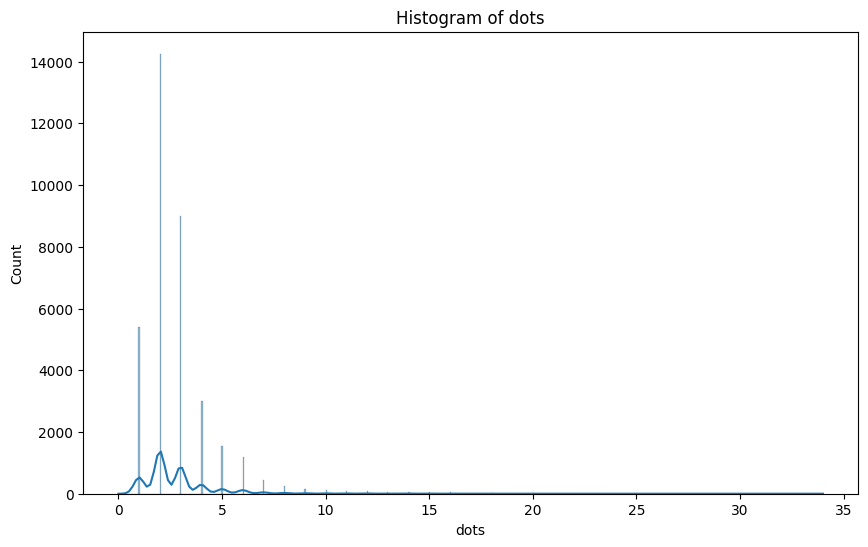

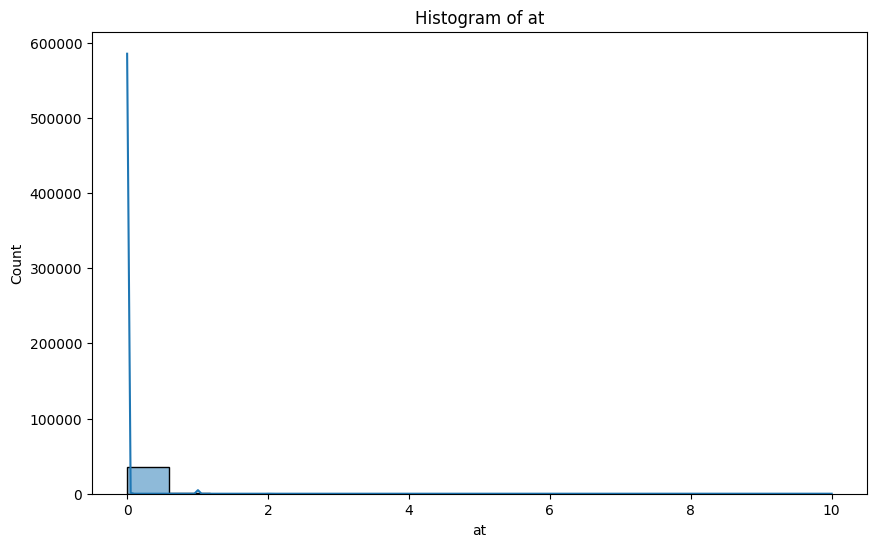

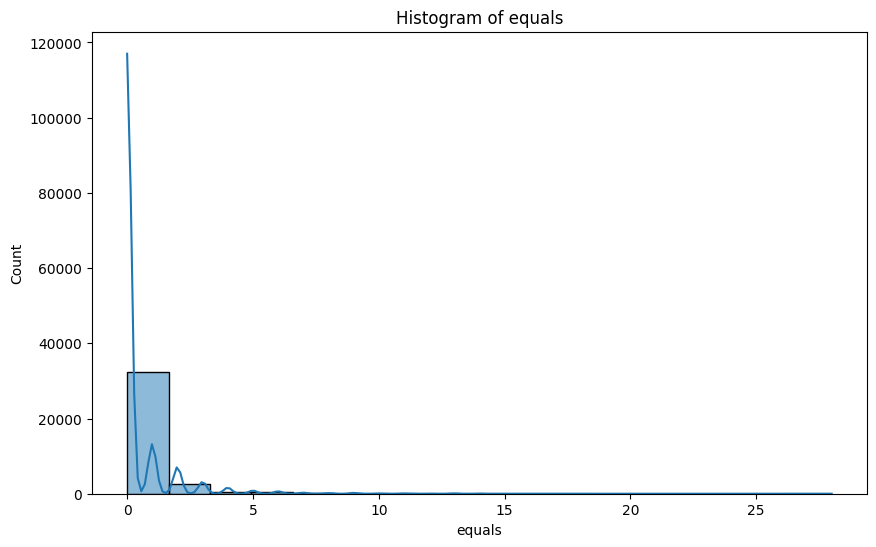

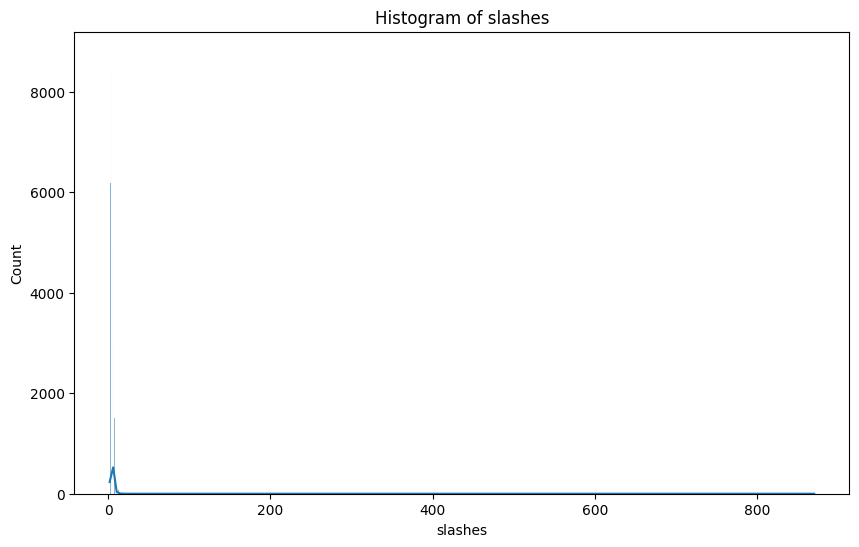

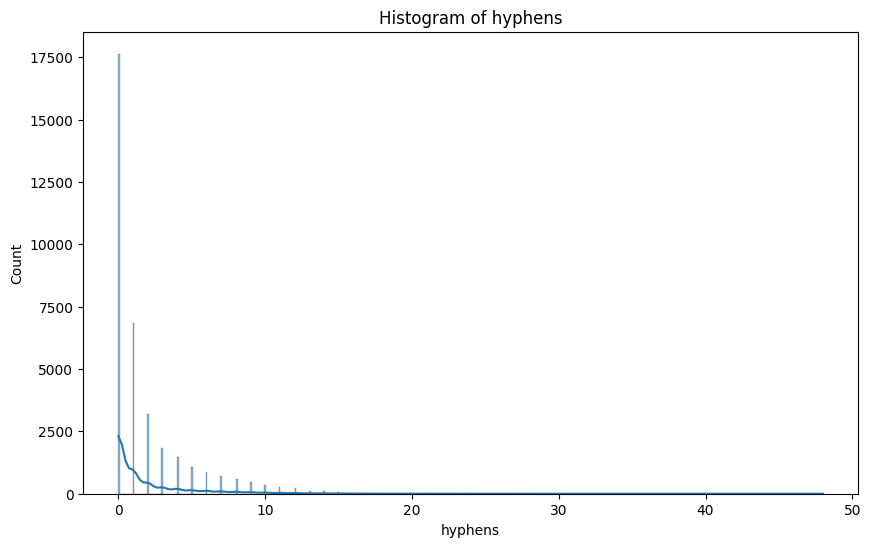

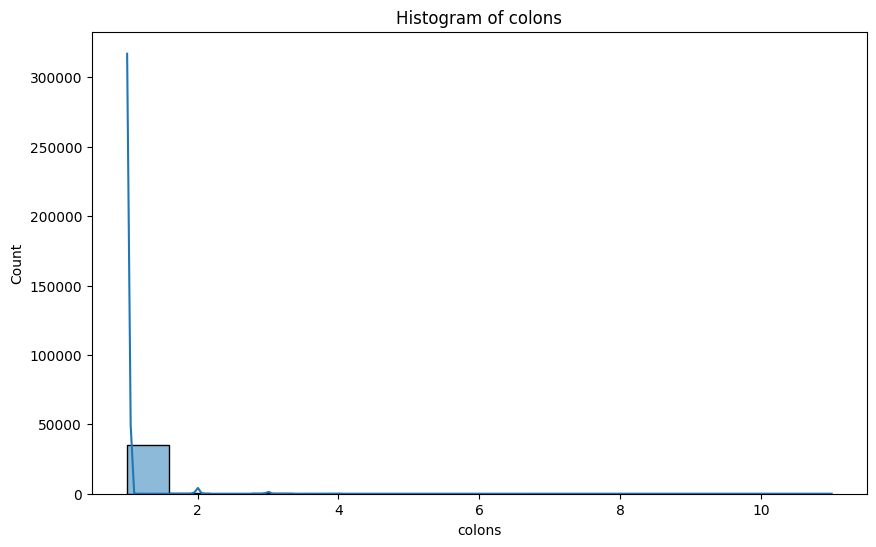

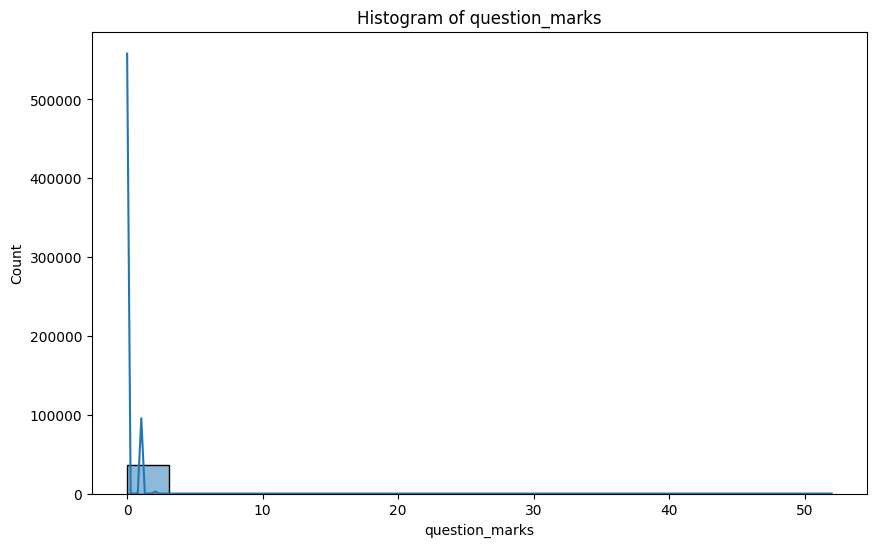

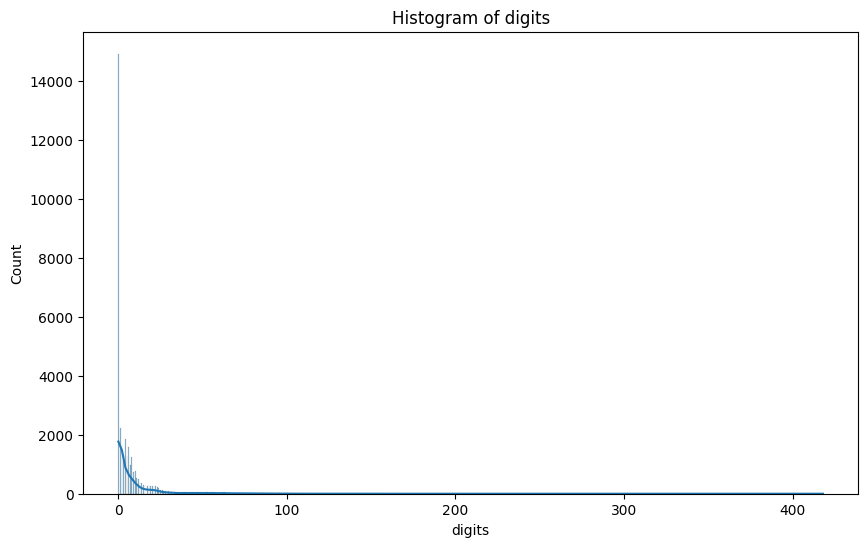

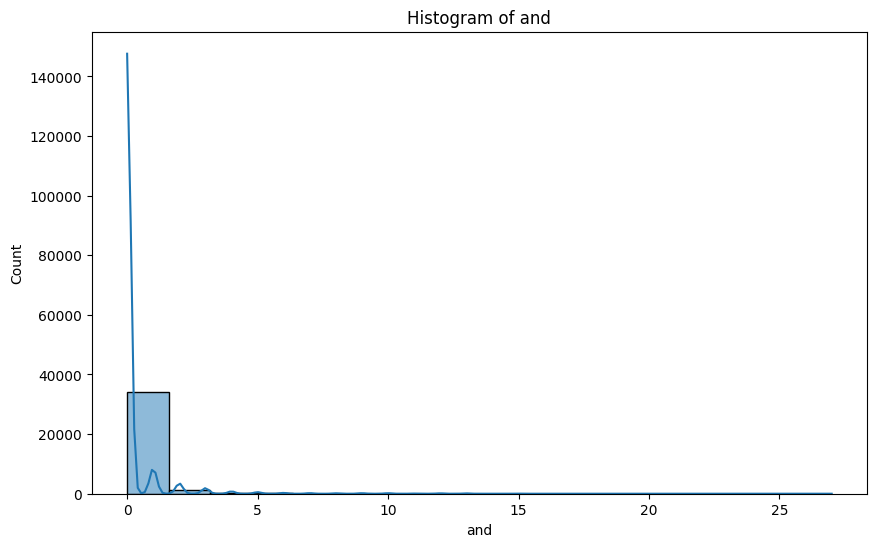

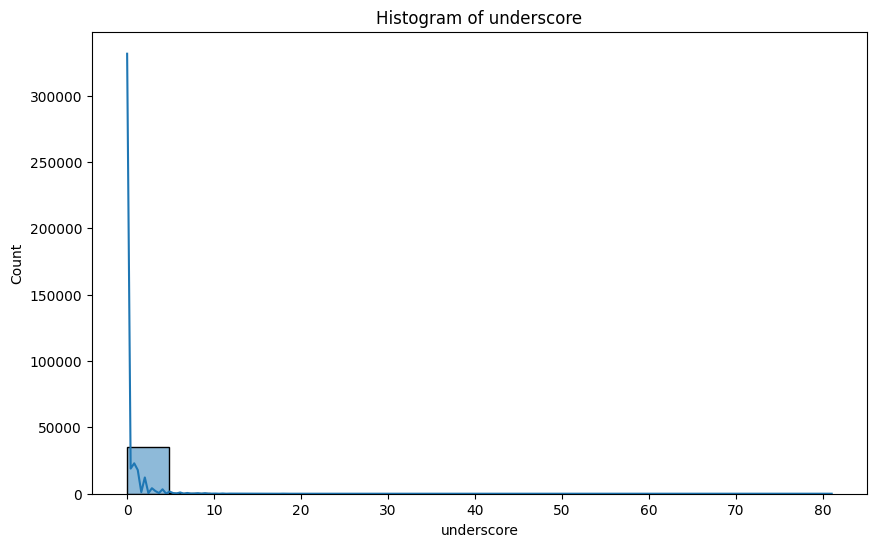

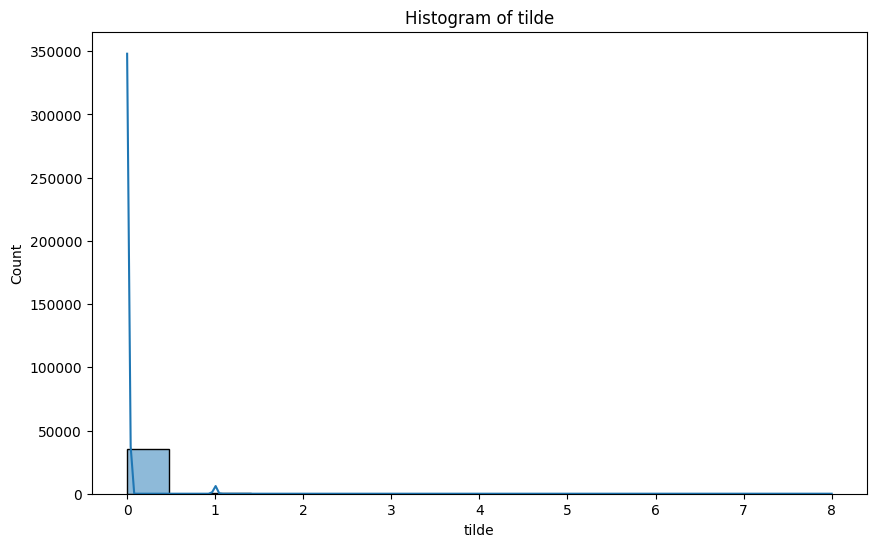

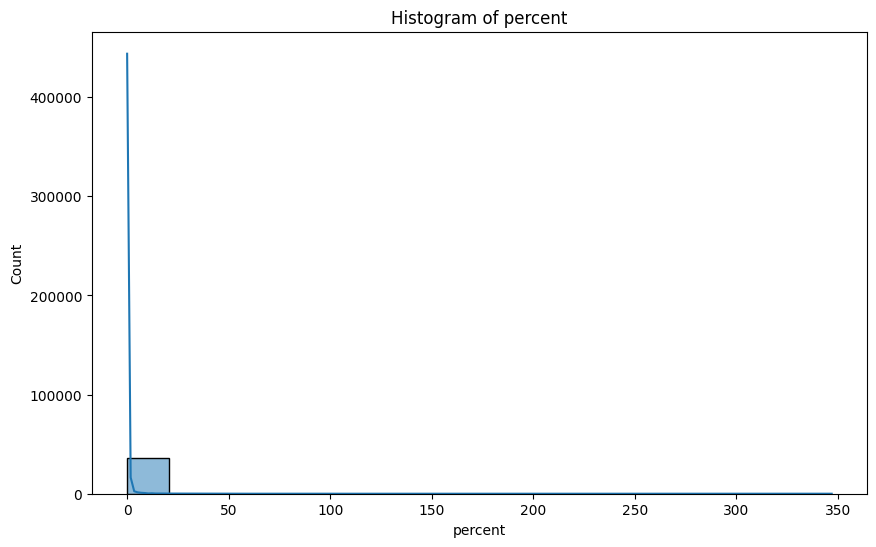

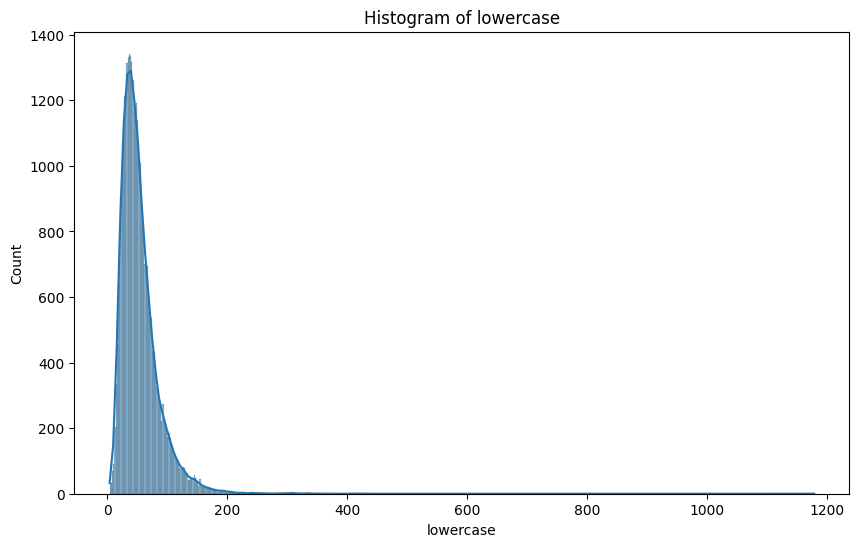

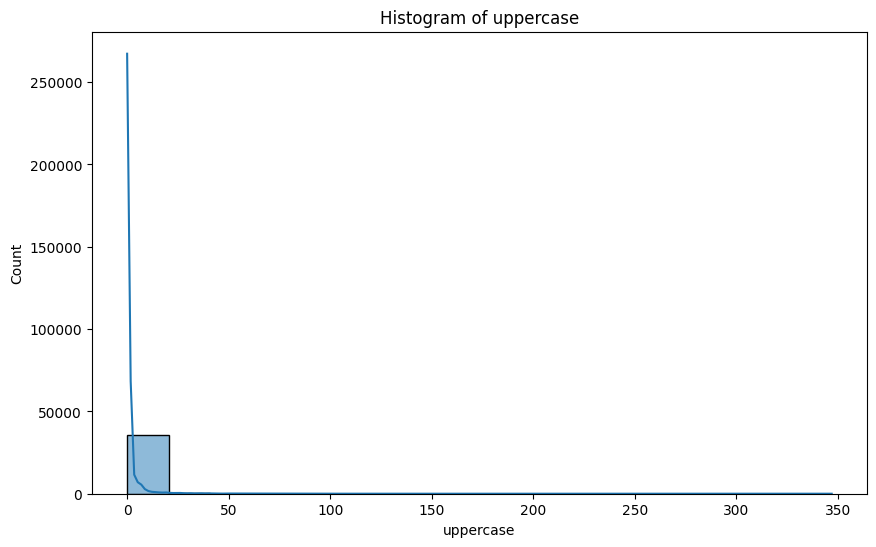

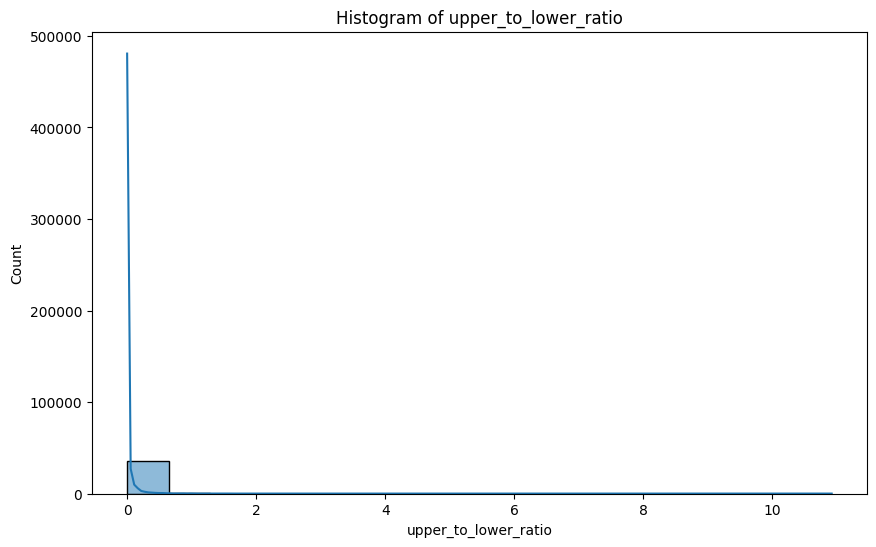

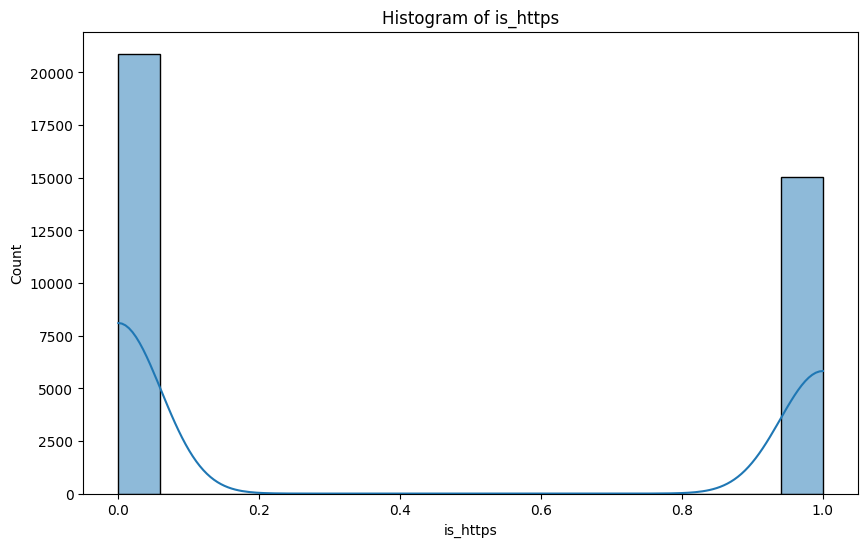

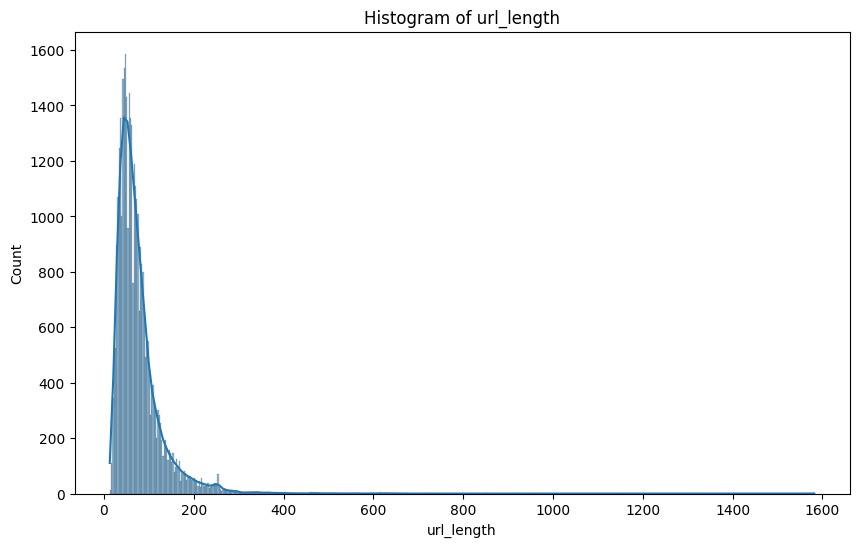

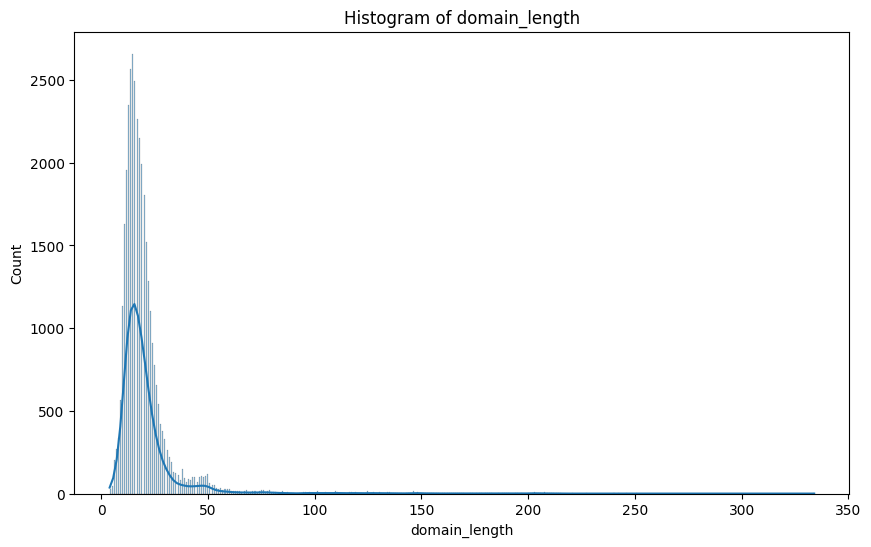

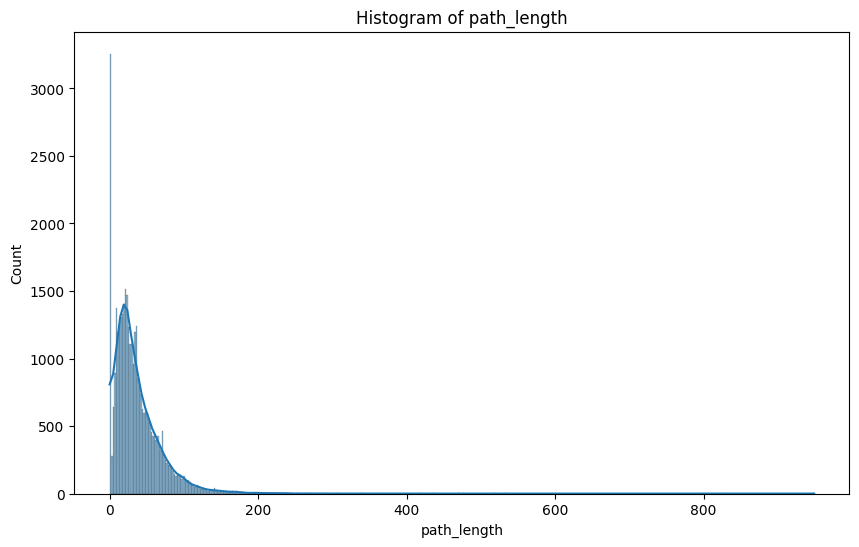

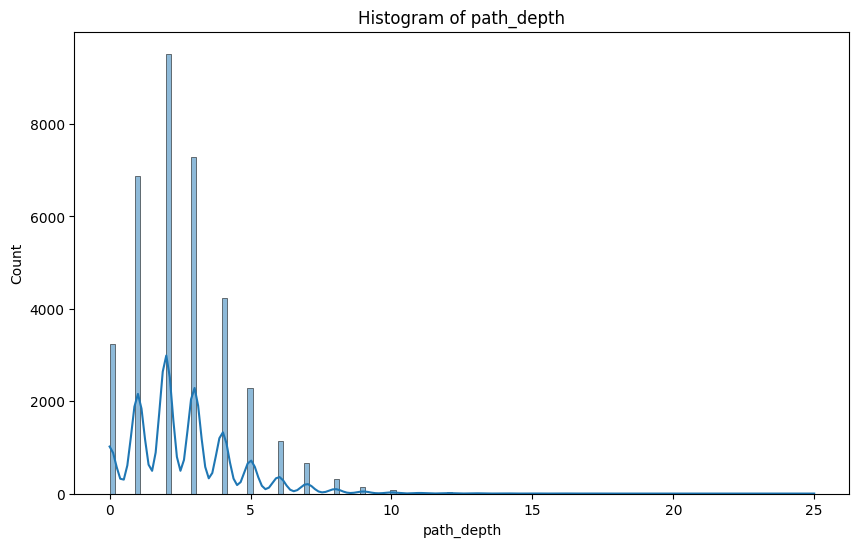

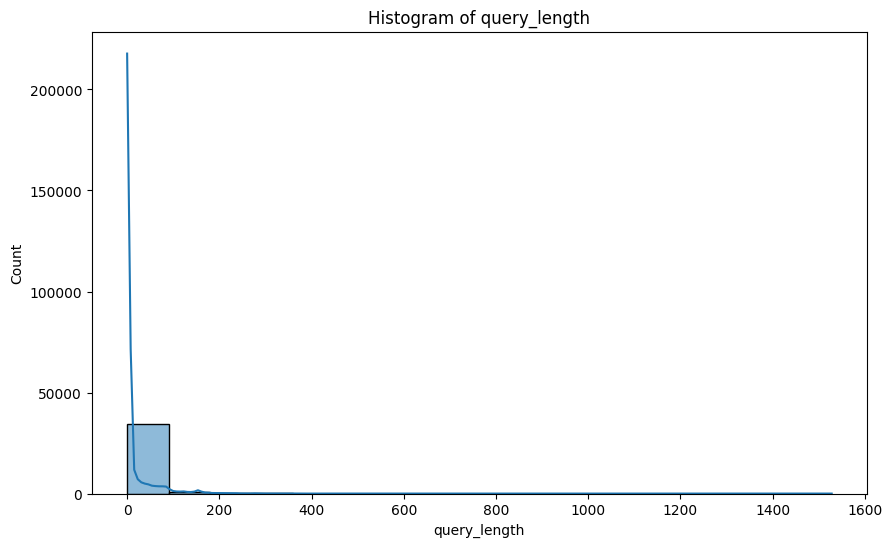

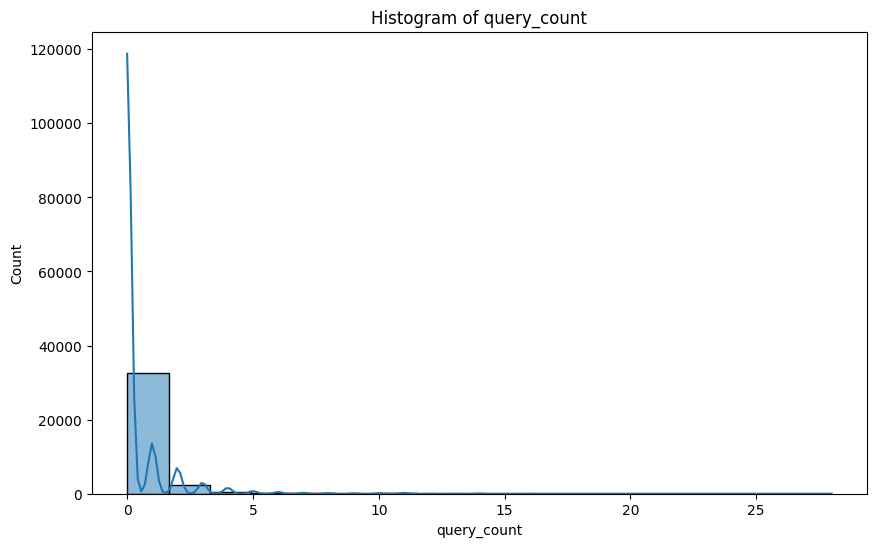

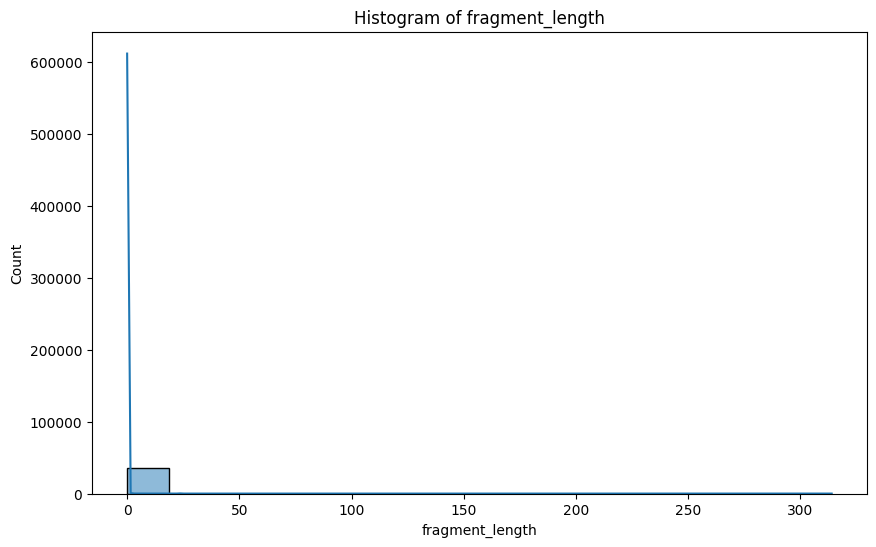

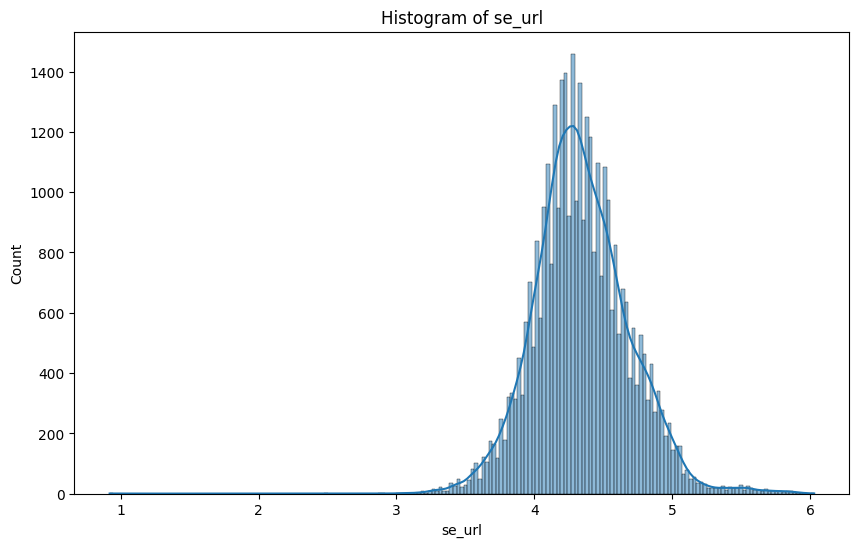

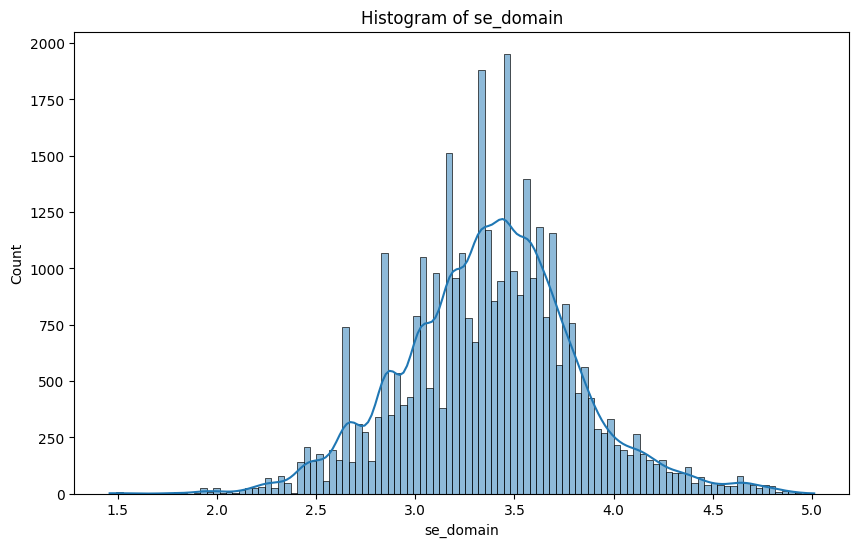

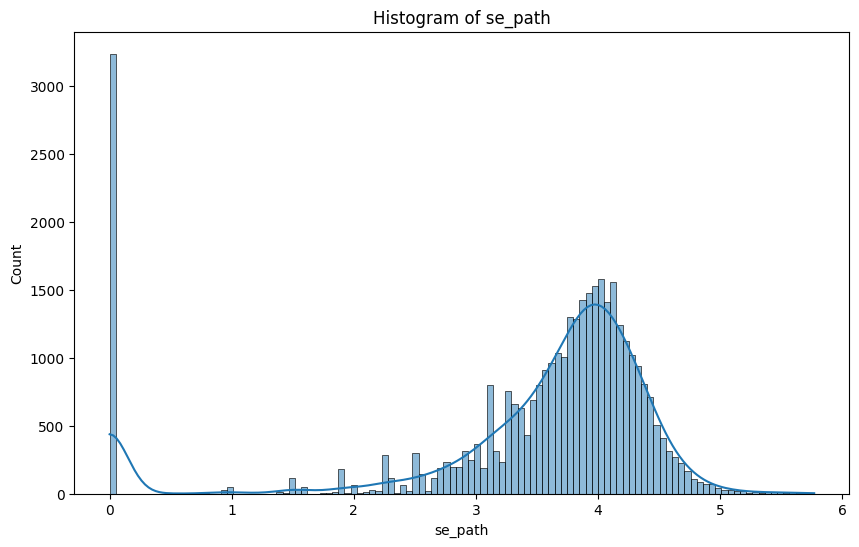

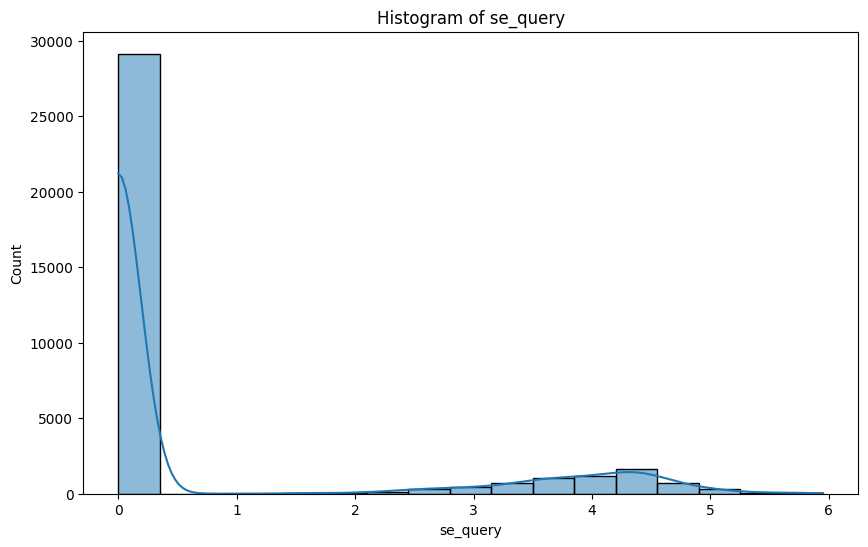

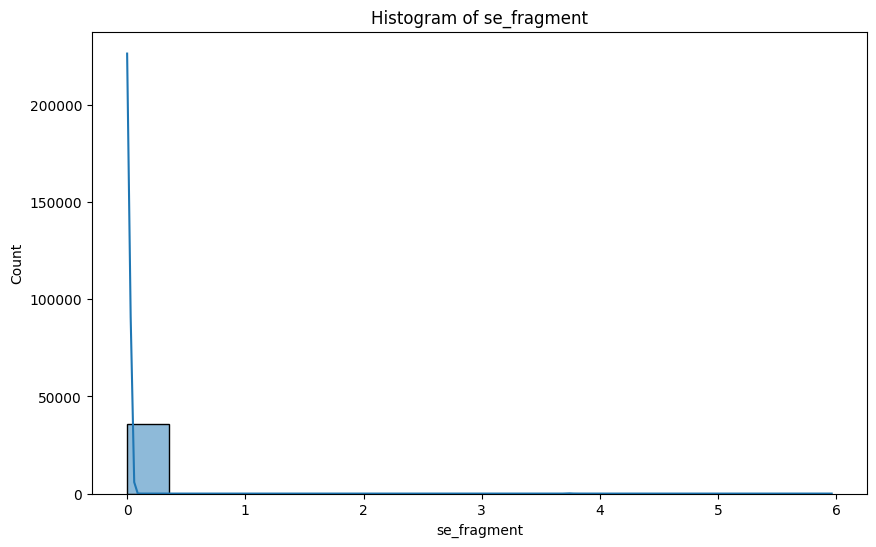

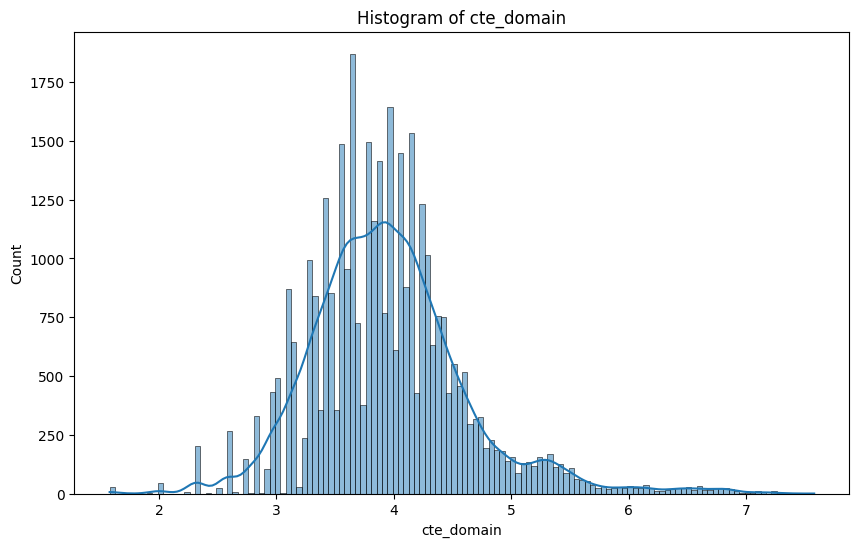

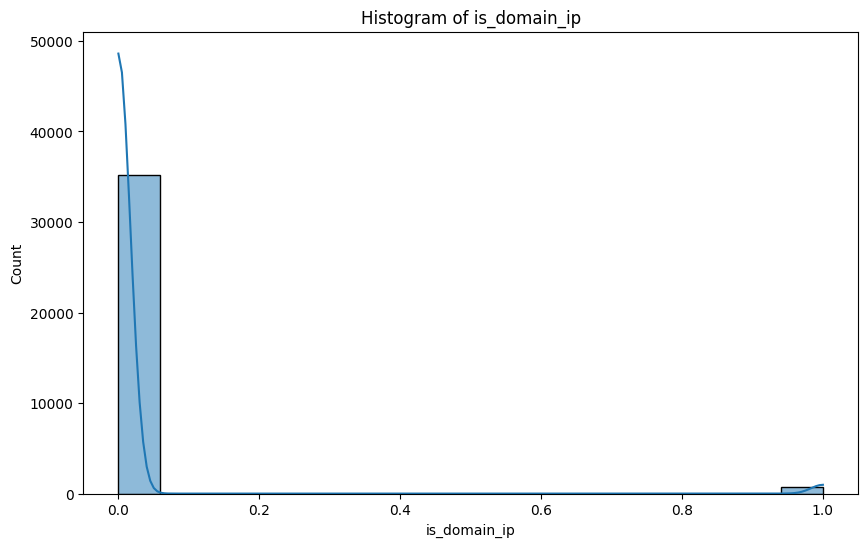

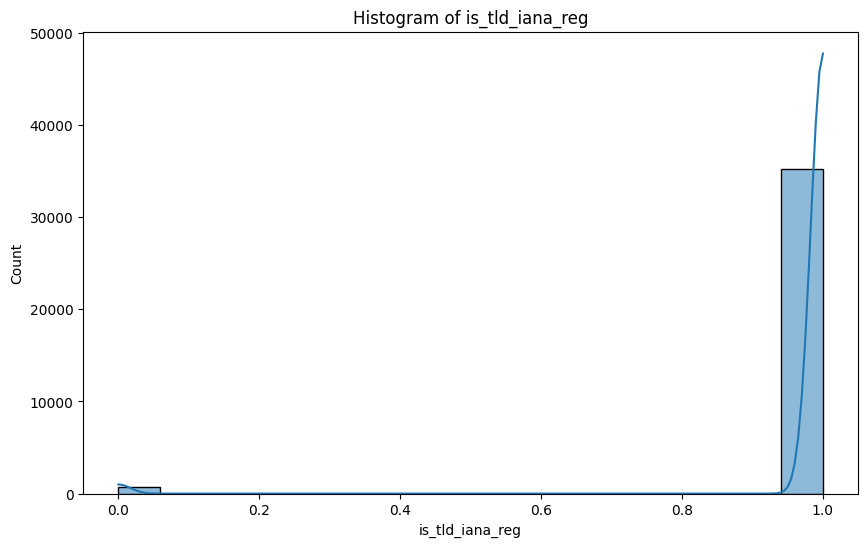

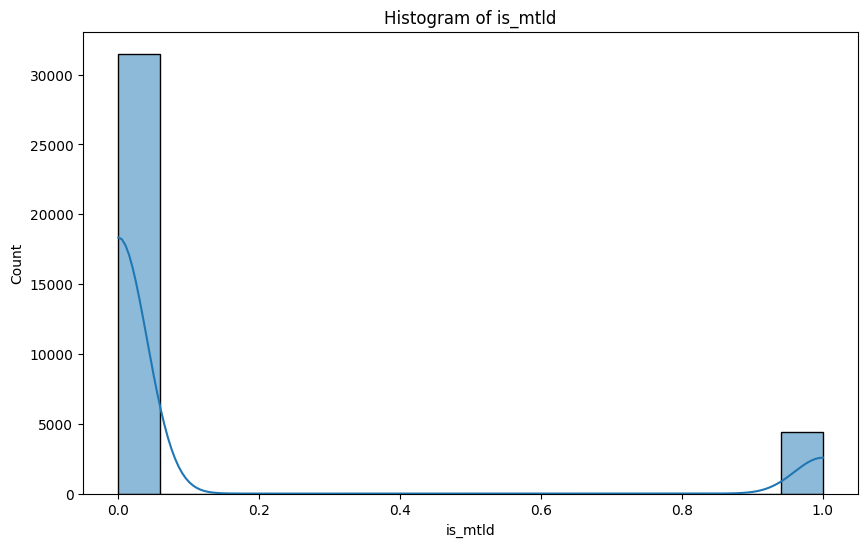

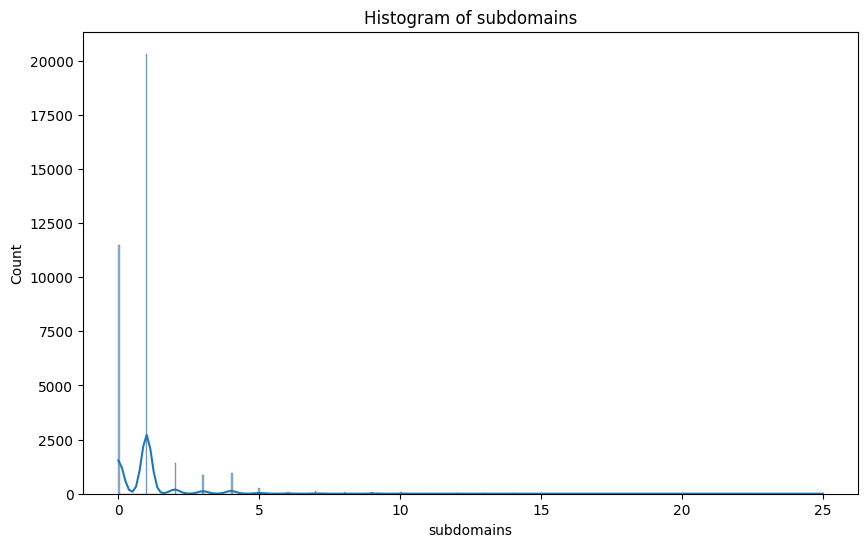

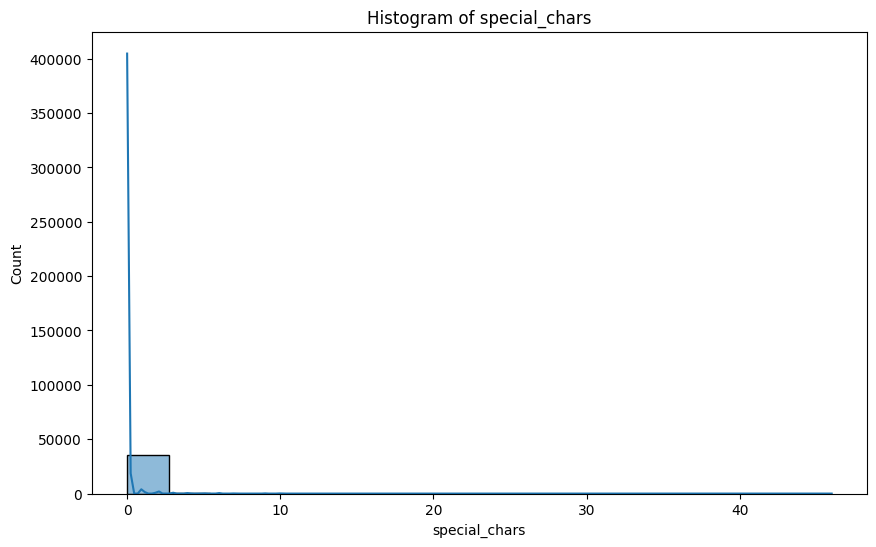

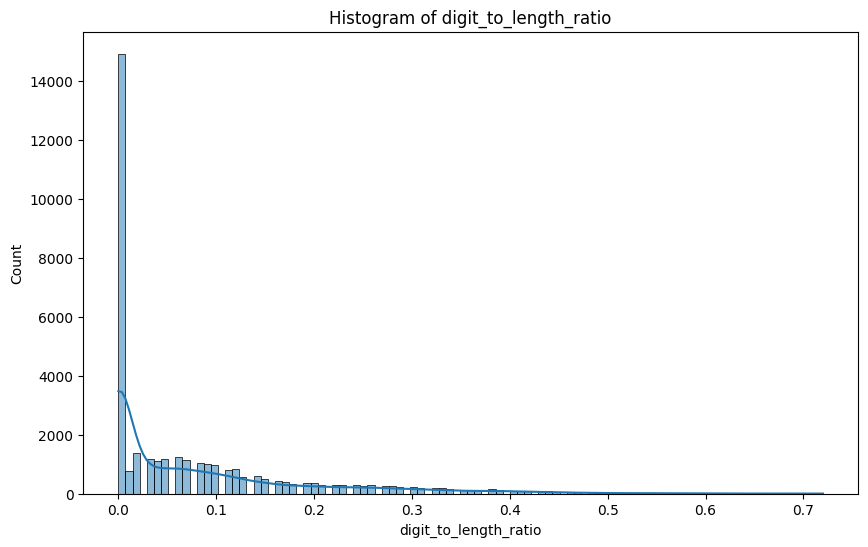

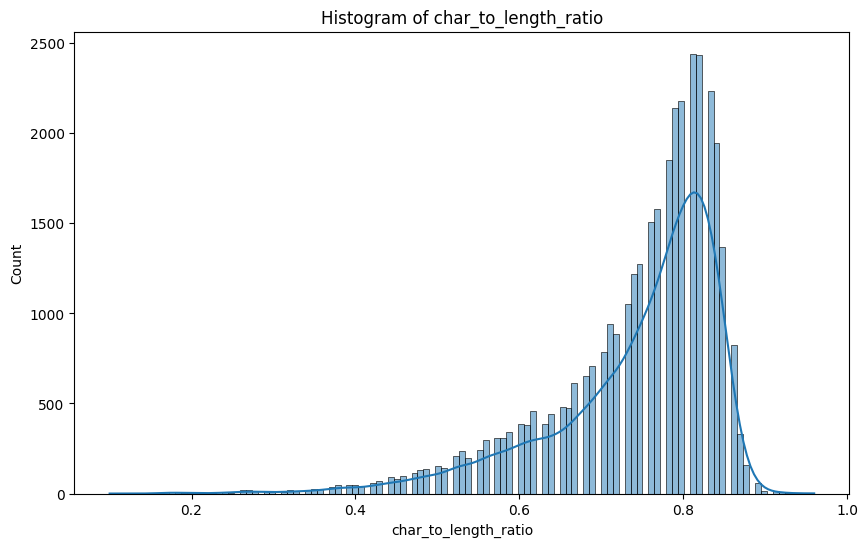

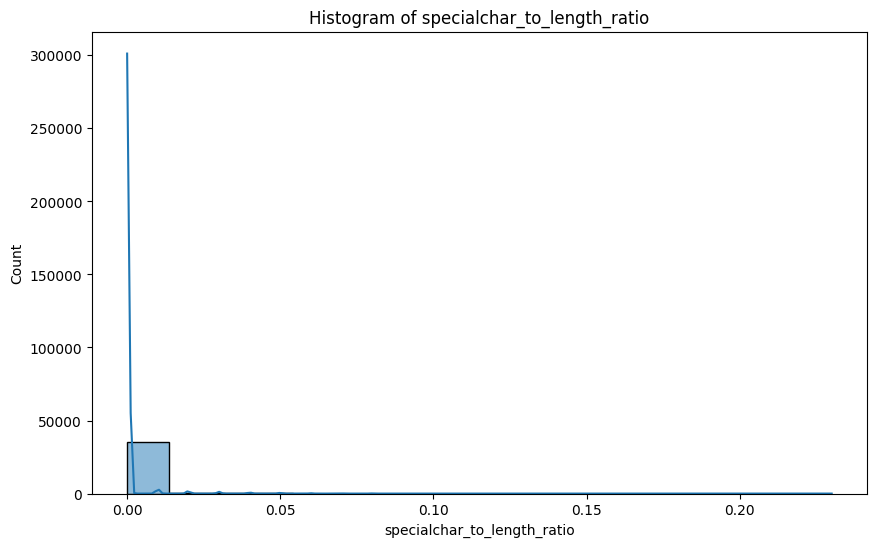

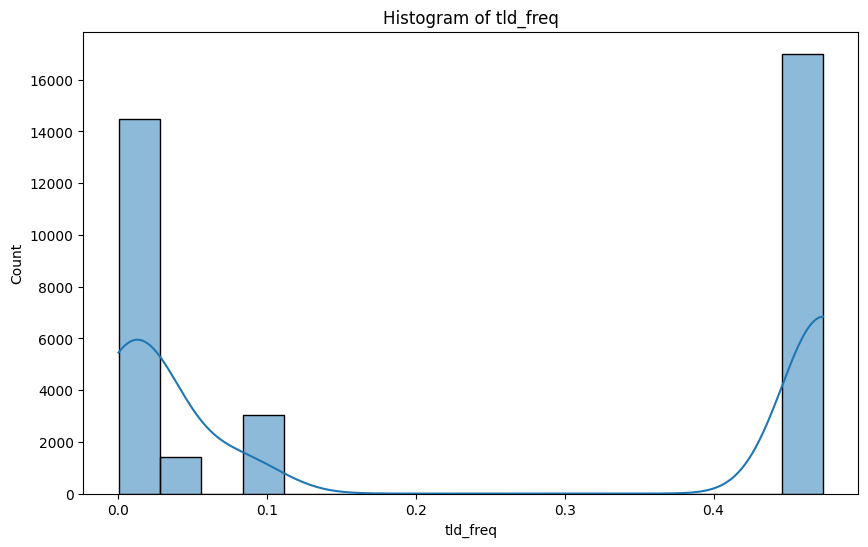

In [ ]:
for feature in X_train.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.show()

### Heatmap Correlation Matrix

korelasi setiap fitur dengan fitur lainnya

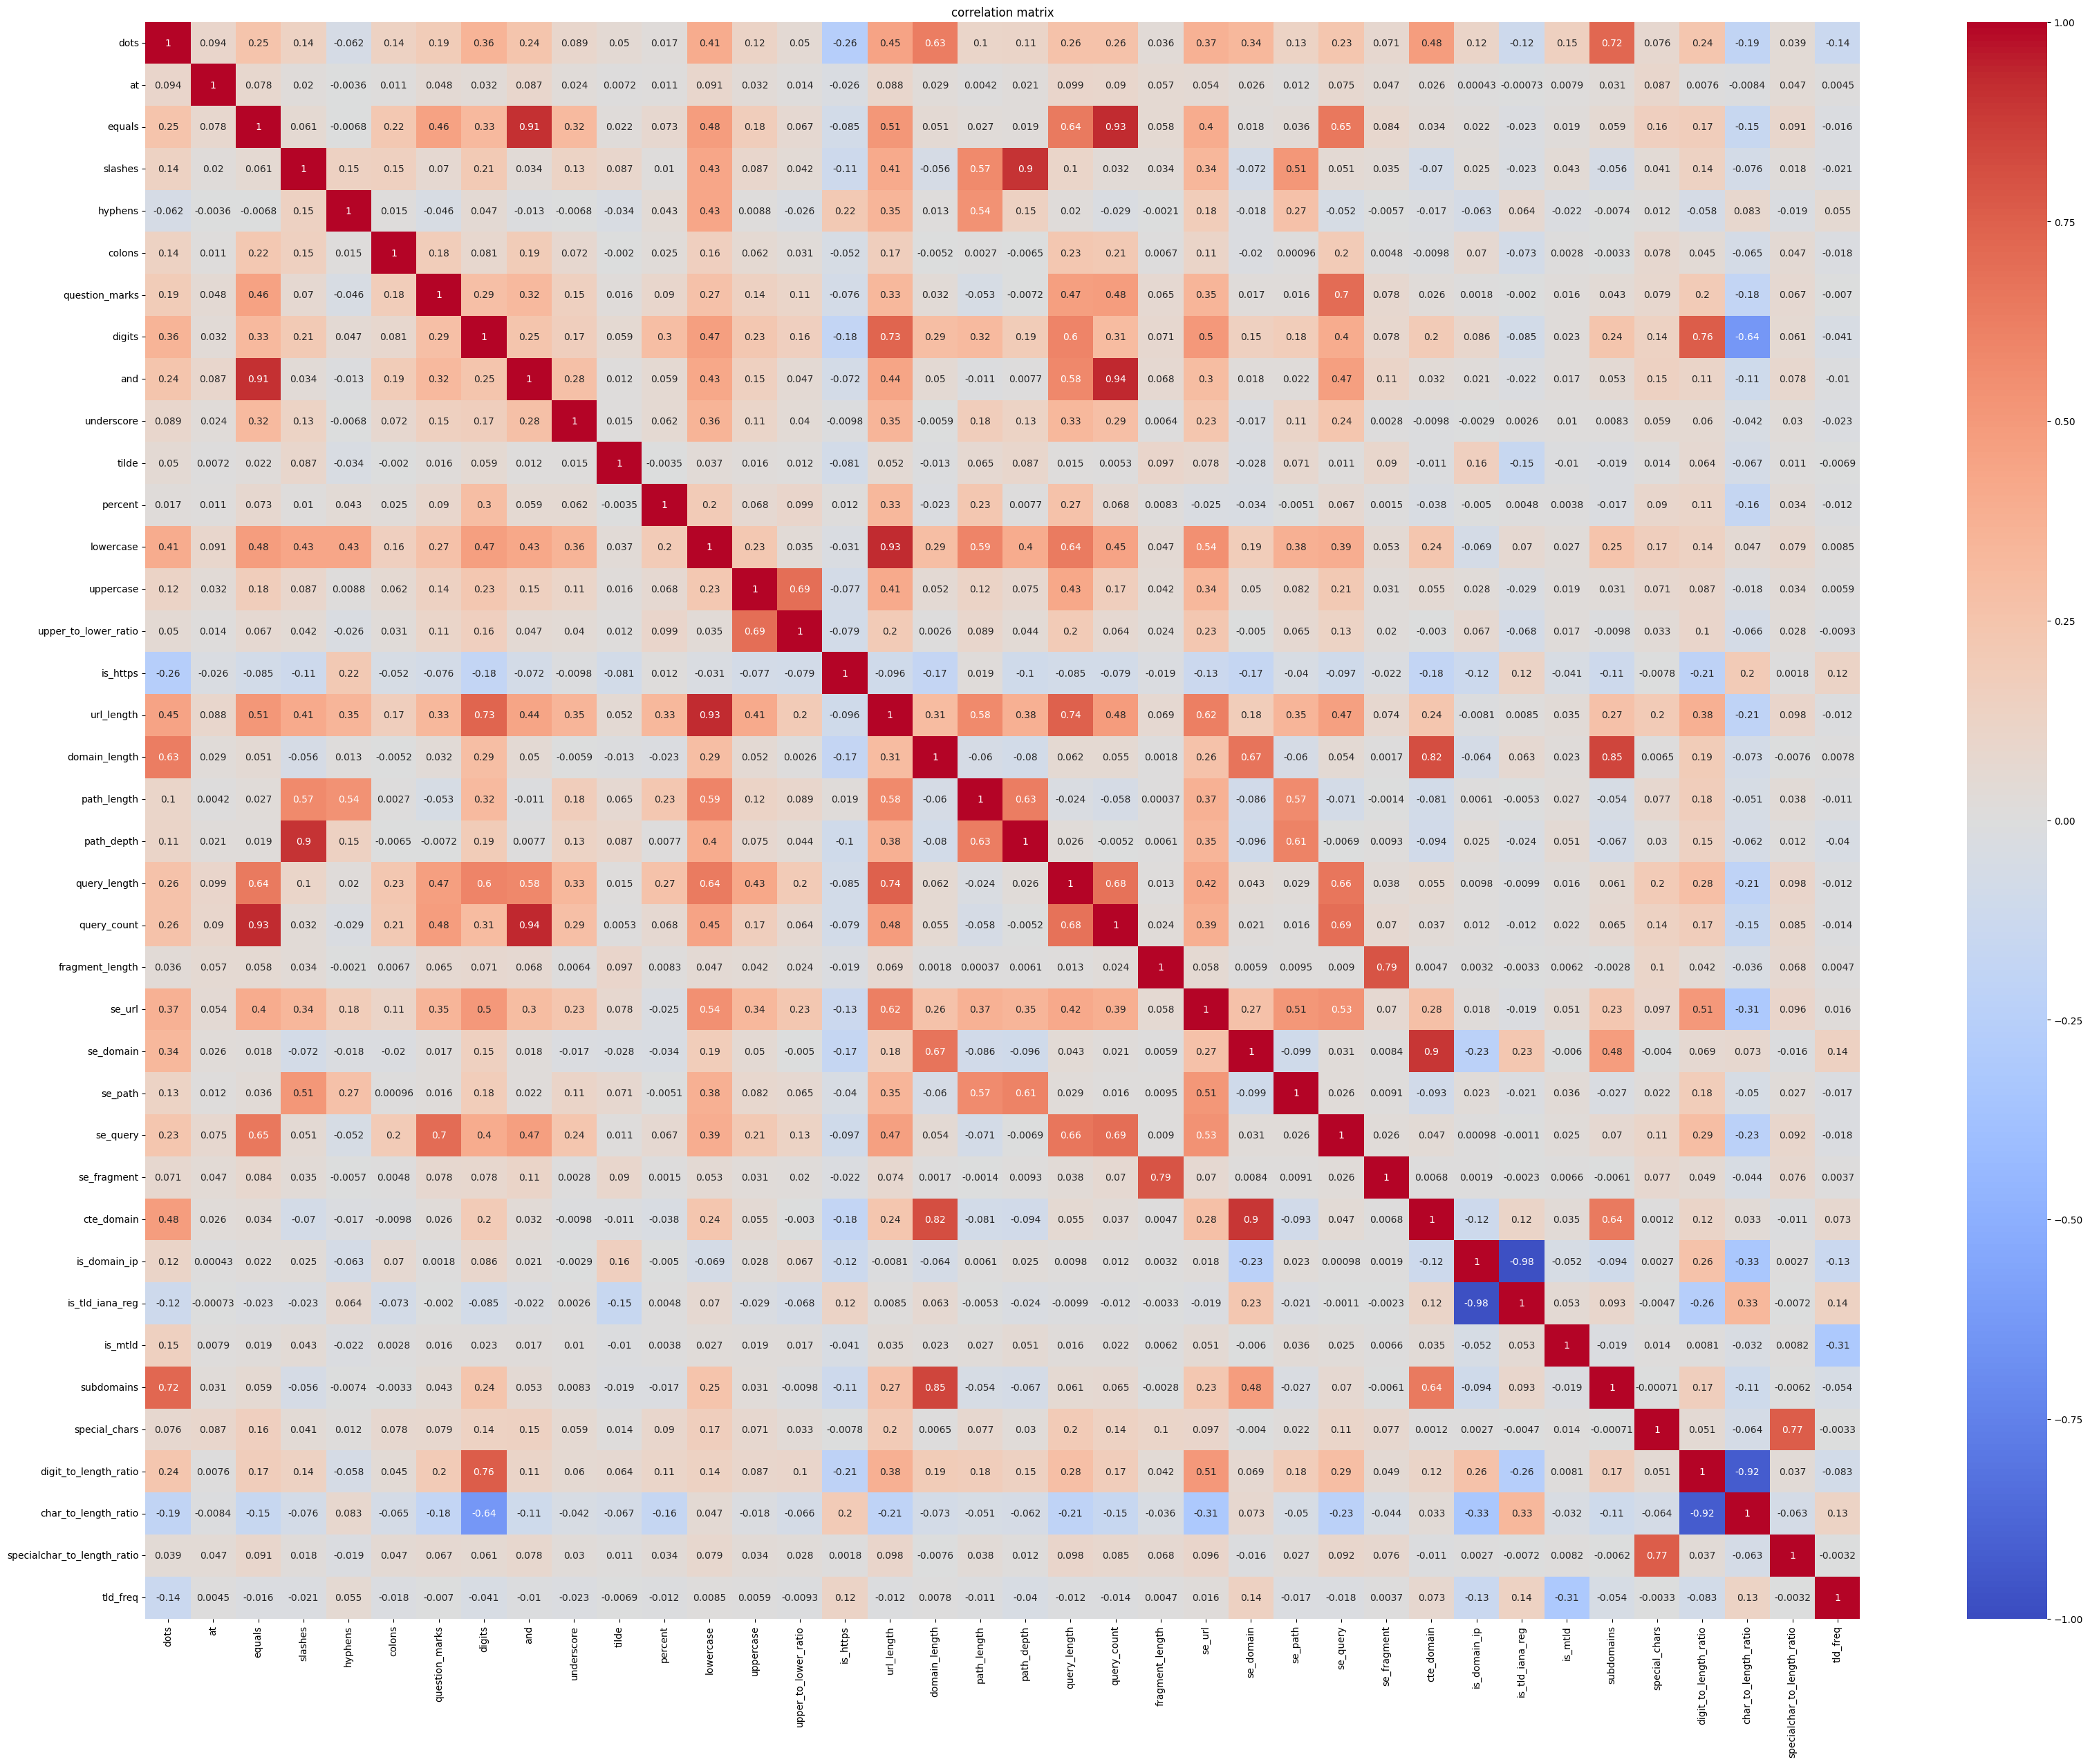

In [44]:
plt.figure(figsize=(40, 30))
correlation_matrix = X_train.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('correlation matrix')
plt.show()

### Matriks korelasi (Hanya dengan variable target)

korelasi fitur yang ada dengan fitur target (Label)

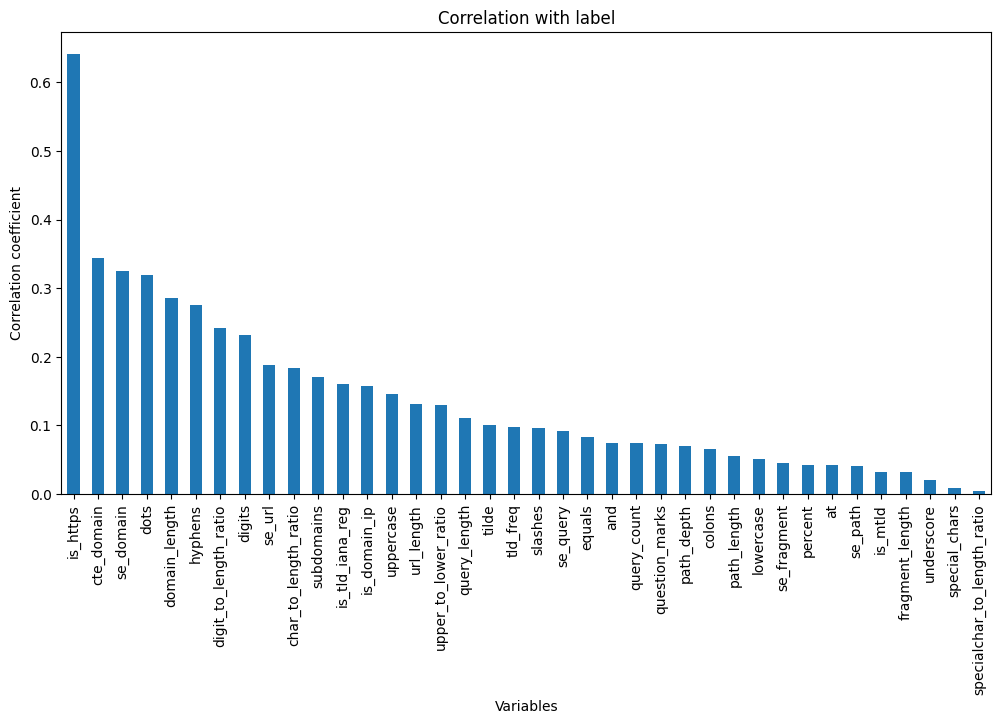

In [45]:
corr_df = X_train.copy()
corr_df["label"] = y_train

target_corr = corr_df.corr(numeric_only=True)["label"]

target_corr_sorted = target_corr.drop("label").abs().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
target_corr_sorted.plot(kind="bar")
plt.title("Correlation with label")
plt.xlabel("Variables")
plt.ylabel("Correlation coefficient")
plt.show()

### Jumlah Label Berdasarkan fitur is_https

<Figure size 800x500 with 0 Axes>

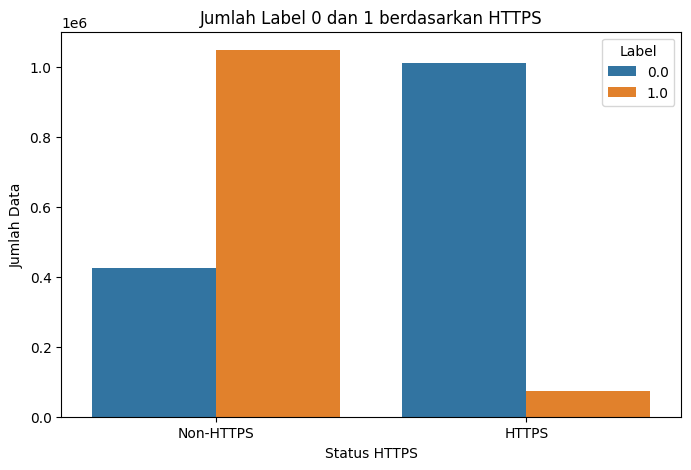

In [46]:
plt.figure(figsize=(8, 5))

# Kalau ingin label is_https lebih jelas:

df_plot = df.copy()
df_plot["is_https_label"] = df_plot["is_https"].map({
    0: "Non-HTTPS",
    1: "HTTPS"
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_plot,
    x="is_https_label",
    hue="label"
)

plt.title("Jumlah Label 0 dan 1 berdasarkan HTTPS")
plt.xlabel("Status HTTPS")
plt.ylabel("Jumlah Data")
plt.legend(title="Label")
plt.show()

### Jumlah label Berdasarkan Beberapa Fitur

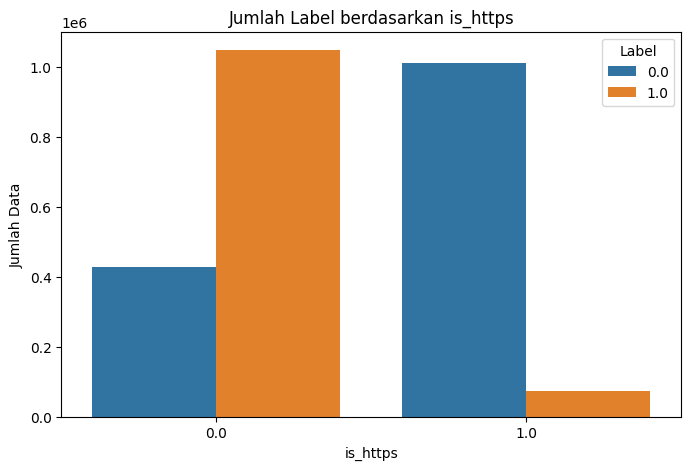

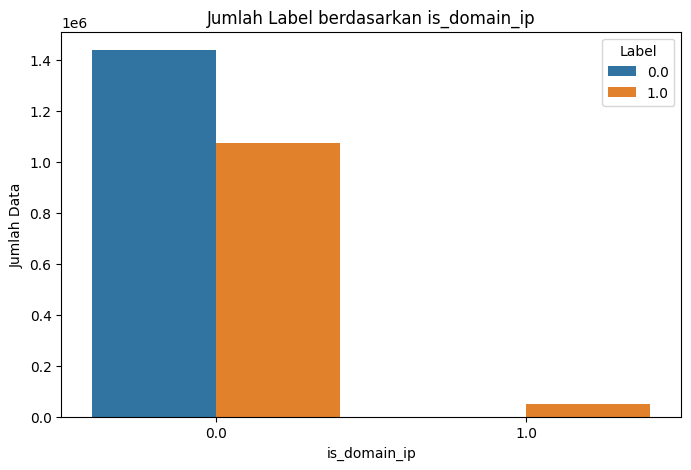

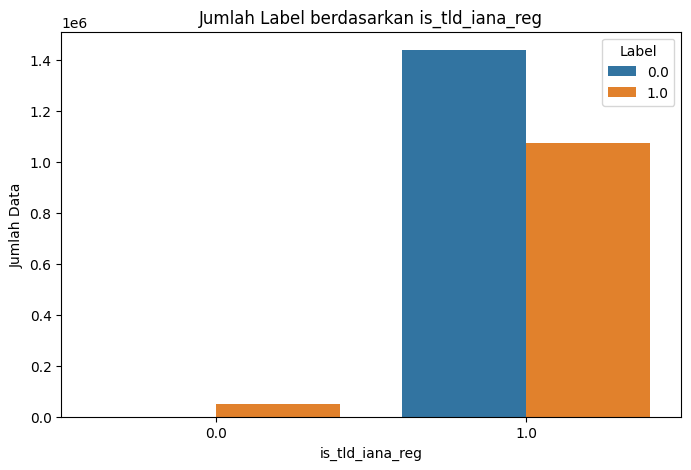

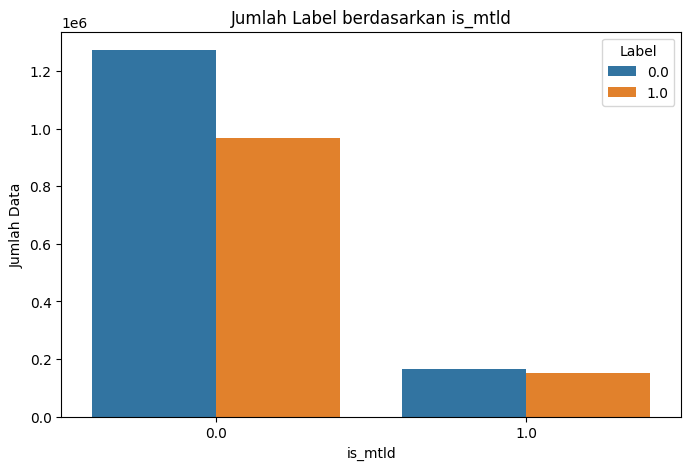

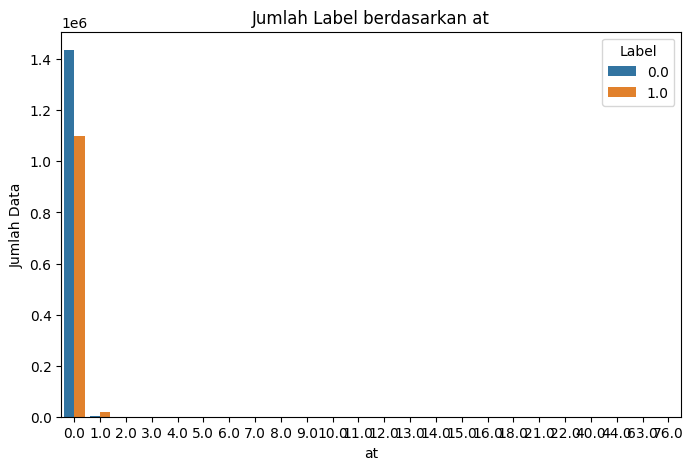

In [47]:
binary_features = ["is_https", "is_domain_ip", "is_tld_iana_reg", "is_mtld", "at"]

for feature in binary_features:
    if feature in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=feature, hue="label")
        plt.title(f"Jumlah Label berdasarkan {feature}")
        plt.xlabel(feature)
        plt.ylabel("Jumlah Data")
        plt.legend(title="Label")
        plt.show()

### Top TLD Berdasarkan Label

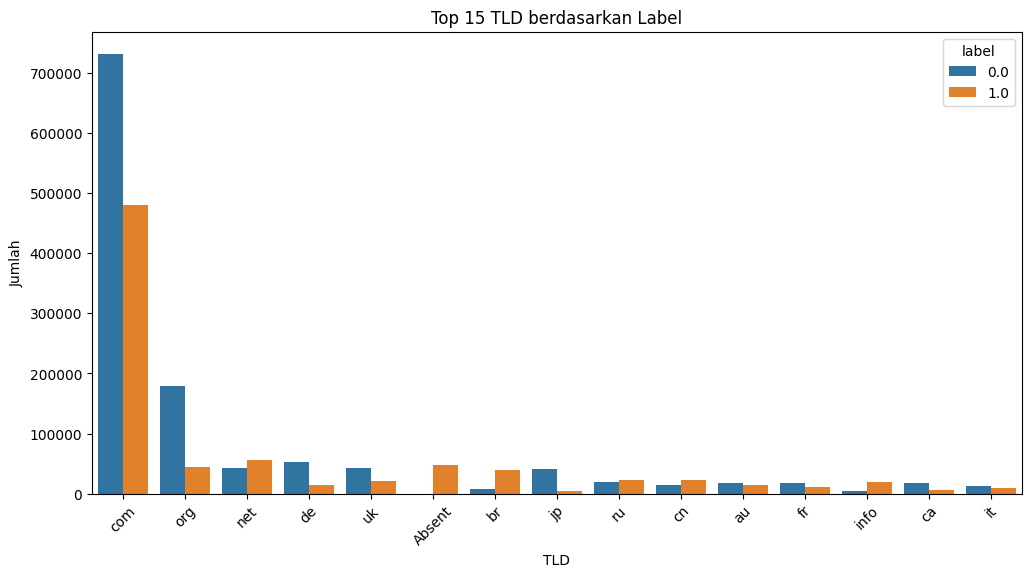

In [48]:
top_tld = df["tld"].value_counts().head(15).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df["tld"].isin(top_tld)],
    x="tld",
    hue="label",
    order=top_tld
)
plt.title("Top 15 TLD berdasarkan Label")
plt.xlabel("TLD")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

### Rata-rata Fitur Per-label

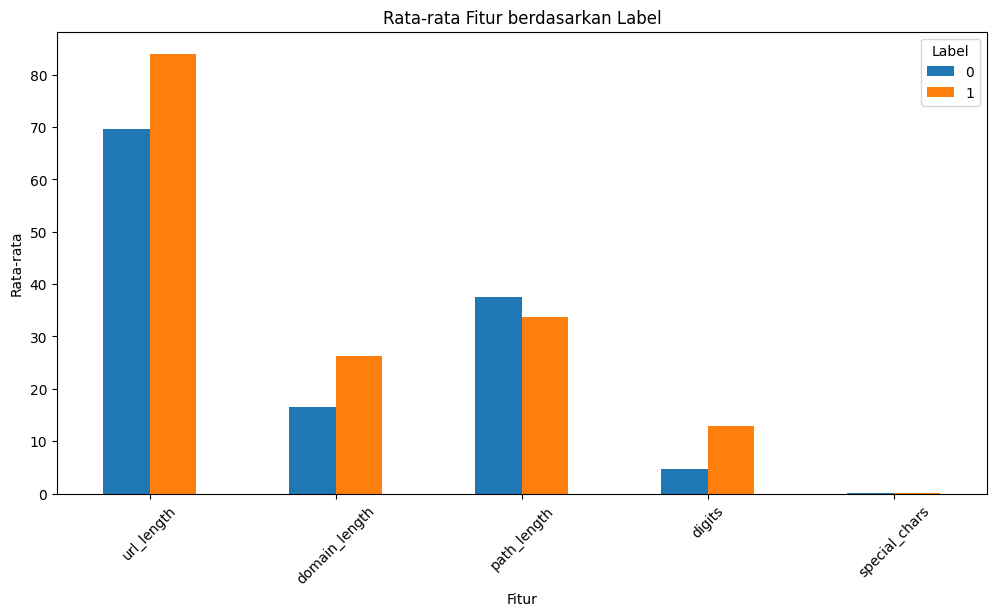

In [ ]:
features = ["url_length", "domain_length", "path_length", "digits", "special_chars"]

mean_by_label = df.groupby("label")[features].mean().T

mean_by_label.plot(kind="bar", figsize=(12, 6))
plt.title("Rata-rata Fitur berdasarkan Label")
plt.xlabel("Fitur")
plt.ylabel("Rata-rata")
plt.xticks(rotation=45)
plt.legend(title="Label")
plt.show()

# **5. Data modeling**

Pada tahap modeling, beberapa algoritma klasifikasi dilatih menggunakan data training, kemudian dievaluasi menggunakan data testing. Model yang digunakan meliputi XGBoost, Random Forest, LightGBM, dan CatBoost. Perbandingan dilakukan untuk mengetahui model mana yang memberikan performa terbaik dalam mendeteksi URL malicious.

### XGBoost Model

In [49]:
!pip install xgboost

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93    287587
         1.0       0.89      0.94      0.92    224311

    accuracy                           0.92    511898
   macro avg       0.92      0.93      0.92    511898
weighted avg       0.93      0.92      0.92    511898



<Figure size 1000x600 with 0 Axes>

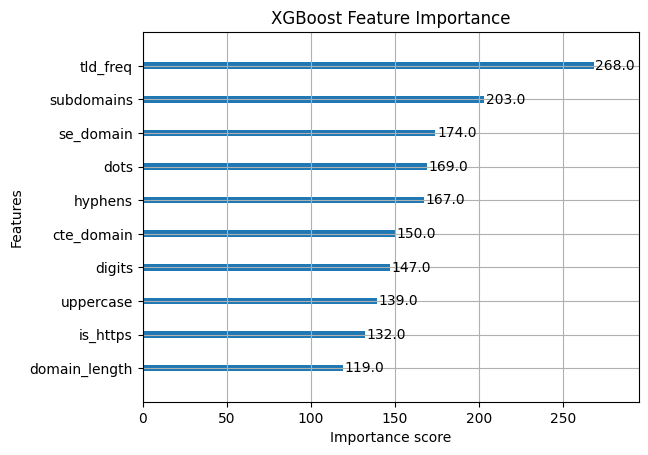

Optimal threshold: 0.5338714718818665
Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93    287587
         1.0       0.90      0.93      0.92    224311

    accuracy                           0.93    511898
   macro avg       0.92      0.93      0.93    511898
weighted avg       0.93      0.93      0.93    511898



In [50]:
# Recalculate scale_pos_weight with correct unscaled y_train
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    random_state=42,
    eval_metric = 'auc'
)

# Train model
xgb_model.fit(X_train, y_train)

# Buat prediksi
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Evaluasi
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasikan Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('XGBoost Feature Importance')
plt.show()

# Atur threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_threshold}")

# Aplikasikan threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

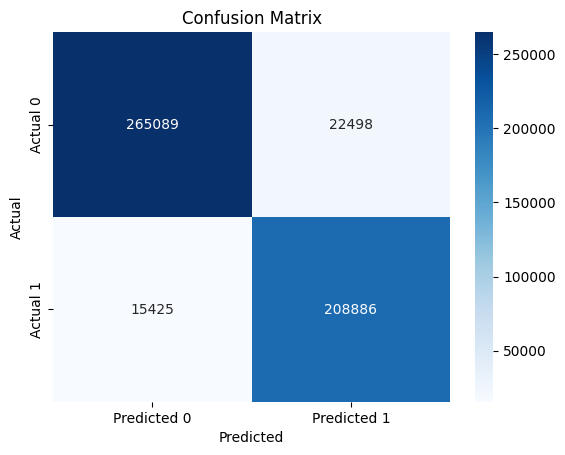

In [53]:
cm = confusion_matrix(y_test, y_pred_optimal)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Menyimpan model XGBoost

In [54]:
import pickle

In [55]:
from joblib import dump, load

# Simpan model XGBoost ke file .joblib
dump(xgb_model, "xgb_model.joblib")
print("XGBoost model saved as xgb_model.joblib")

# Untuk load kembali
xgb_model_loaded = load("xgb_model.joblib")


XGBoost model saved as xgb_model.joblib


### Random forest

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93    287587
         1.0       0.89      0.94      0.91    224311

    accuracy                           0.92    511898
   macro avg       0.92      0.92      0.92    511898
weighted avg       0.92      0.92      0.92    511898



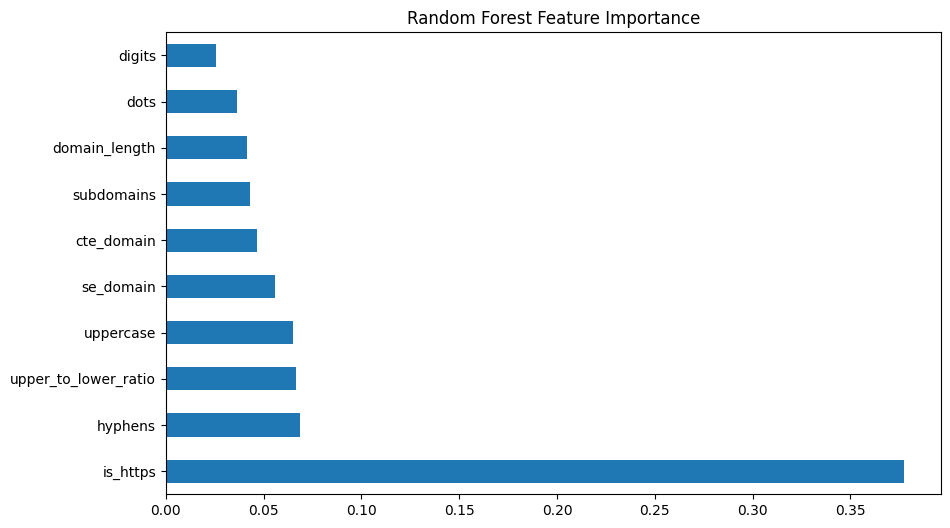

Optimal threshold: 0.5352942829129738
Random Forest Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    287587
         1.0       0.90      0.92      0.91    224311

    accuracy                           0.92    511898
   macro avg       0.92      0.92      0.92    511898
weighted avg       0.92      0.92      0.92    511898



In [56]:
from sklearn.ensemble import RandomForestClassifier

# Class weight dictionary or 'balanced' option
class_weights = {0: 1, 1: (len(y_train[y_train==0]) / len(y_train[y_train==1]))}
# Alternatively: class_weights = 'balanced'

# Define the model with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot feature importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.show()

# Finding optimal threshold
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_proba_rf)
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-10)
optimal_threshold_rf = thresholds_rf[np.argmax(f1_scores_rf)]

# Apply optimal threshold
y_pred_rf_optimal = (y_pred_proba_rf >= optimal_threshold_rf).astype(int)
print(f"Optimal threshold: {optimal_threshold_rf}")
print("Random Forest Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_rf_optimal))

Menyimpan model Random Forest

In [57]:
# Simpan model XGBoost ke file .joblib
dump(xgb_model, "rf_model.joblib")
print("rf model saved as rf_model.joblib")

# Untuk load kembali
xgb_model_loaded = load("rf_model.joblib")


rf model saved as rf_model.joblib


### LightGBM

LightGBM Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95    287587
         1.0       0.93      0.95      0.94    224311

    accuracy                           0.95    511898
   macro avg       0.95      0.95      0.95    511898
weighted avg       0.95      0.95      0.95    511898



<Figure size 1000x600 with 0 Axes>

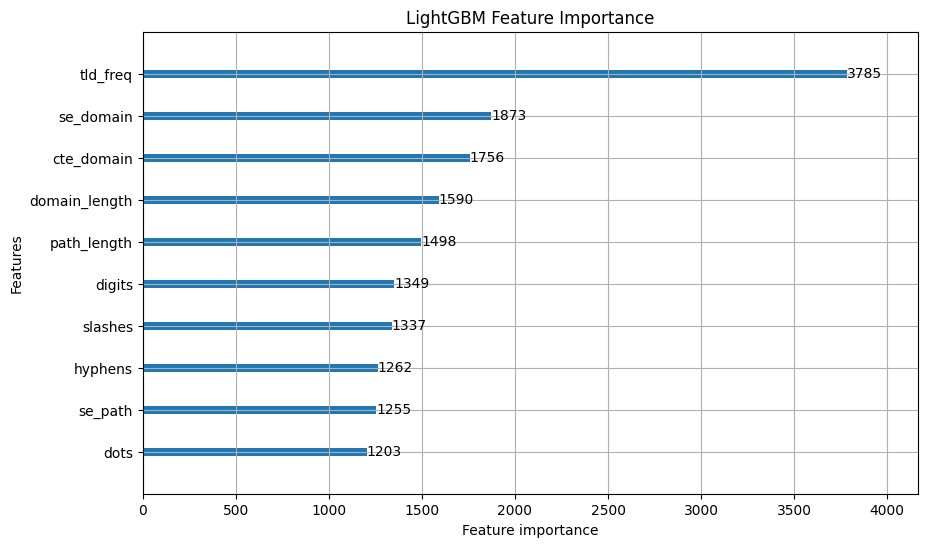

Optimal threshold: 0.5119020229513724
LightGBM Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95    287587
         1.0       0.93      0.95      0.94    224311

    accuracy                           0.95    511898
   macro avg       0.95      0.95      0.95    511898
weighted avg       0.95      0.95      0.95    511898



In [60]:
import lightgbm as lgb

class_weight = len(y_train) / (2 * np.bincount(y_train))

# Create dataset objects
train_data = lgb.Dataset(X_train, label=y_train, weight=class_weight[y_train.values.astype(int)])
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, weight=class_weight[y_test.values.astype(int)])

# Set parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'is_unbalance': False  # Handle imbalanced datasets
}

# Train model
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
)

# Make predictions
y_pred_proba_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
y_pred_lgb = (y_pred_proba_lgb >= 0.5).astype(int)

# Evaluate
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))

# Plot feature importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=10, figsize=(10, 6))
plt.title('LightGBM Feature Importance')
plt.show()

precision_lgb, recall_lgb, thresholds_lgb = precision_recall_curve(y_test, y_pred_proba_lgb)
f1_scores_lgb = 2 * (precision_lgb * recall_lgb) / (precision_lgb + recall_lgb + 1e-10)
optimal_idx = np.argmax(f1_scores_lgb)
optimal_threshold_lgb = thresholds_lgb[optimal_idx] if optimal_idx < len(thresholds_lgb) else 0.5

# Apply optimal threshold
y_pred_lgb_optimal = (y_pred_proba_lgb >= optimal_threshold_lgb).astype(int)
print(f"Optimal threshold: {optimal_threshold_lgb}")
print("LightGBM Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_lgb_optimal))

Menyimpan model LightGBM

In [61]:
# Simpan model LightGBM ke file .joblib
dump(lgb_model, "lgb_model.joblib")
print("LightGBM model saved as lgb_model.joblib")

# Untuk load kembali
xgb_model_loaded = load("lgb_model.joblib")


LightGBM model saved as lgb_model.joblib


### CatBoost

In [62]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


0:	test: 0.9367587	best: 0.9367587 (0)	total: 2.23s	remaining: 18m 32s
100:	test: 0.9748144	best: 0.9748144 (100)	total: 1m 39s	remaining: 6m 32s
200:	test: 0.9801923	best: 0.9801923 (200)	total: 3m 11s	remaining: 4m 45s
300:	test: 0.9828083	best: 0.9828083 (300)	total: 4m 38s	remaining: 3m 3s
400:	test: 0.9842838	best: 0.9842838 (400)	total: 6m 4s	remaining: 1m 29s
499:	test: 0.9852642	best: 0.9852642 (499)	total: 7m 28s	remaining: 0us

bestTest = 0.9852642186
bestIteration = 499

CatBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94    287587
         1.0       0.91      0.94      0.93    224311

    accuracy                           0.94    511898
   macro avg       0.93      0.94      0.93    511898
weighted avg       0.94      0.94      0.94    511898



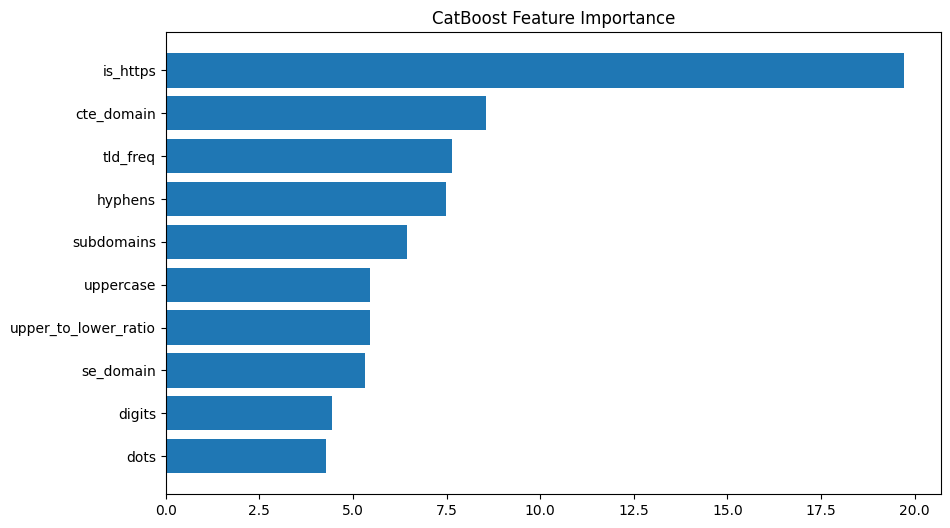

Optimal threshold: 0.5547746271581411
CatBoost Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94    287587
         1.0       0.92      0.93      0.93    224311

    accuracy                           0.94    511898
   macro avg       0.94      0.94      0.94    511898
weighted avg       0.94      0.94      0.94    511898



In [63]:
from catboost import CatBoostClassifier, Pool

class_weights = {0: 1, 1: len(y_train[y_train==0]) / len(y_train[y_train==1])}

categorical_features_indices = []

train_pool = Pool(X_train, y_train, cat_features=categorical_features_indices)
test_pool = Pool(X_test, y_test, cat_features=categorical_features_indices)

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    class_weights=class_weights,
    verbose=100
)

# Train model
catboost_model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=50,
)

# Make predictions
y_pred_proba_cat = catboost_model.predict_proba(X_test)[:, 1]
y_pred_cat = catboost_model.predict(X_test)

# Evaluate
print("CatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat))

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance = catboost_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-10:]
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
plt.title('CatBoost Feature Importance')
plt.show()

# Optimal Threshold
precision_cat, recall_cat, thresholds_cat = precision_recall_curve(y_test, y_pred_proba_cat)
f1_scores_cat = 2 * (precision_cat * recall_cat) / (precision_cat + recall_cat + 1e-10)
optimal_idx = np.argmax(f1_scores_cat)
optimal_threshold_cat = thresholds_cat[optimal_idx] if optimal_idx < len(thresholds_cat) else 0.5

# Apply optimal threshold
y_pred_cat_optimal = (y_pred_proba_cat >= optimal_threshold_cat).astype(int)
print(f"Optimal threshold: {optimal_threshold_cat}")
print("CatBoost Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_cat_optimal))

Menyimpan model CatBoost

In [64]:
# Simpan model CatBoost ke file .joblib
dump(catboost_model, "catboost_model.joblib")
print("CatBoost model saved as catboost_model.joblib")

# Untuk load kembali
catboost_model_loaded = load("catboost_model.joblib")

CatBoost model saved as catboost_model.joblib


### Komparasi antar model

Hasil evaluasi dari setiap model dibandingkan berdasarkan metrik accuracy, precision, recall, F1-score, dan ROC-AUC. Perbandingan ini digunakan untuk menentukan model terbaik, tidak hanya berdasarkan akurasi, tetapi juga kemampuan model dalam mendeteksi URL malicious secara tepat.

In [65]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    # Classification metrics
    print(f"\n{model_name} Evaluation:")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Malicious', 'Malicious'],
                yticklabels=['Not Malicious', 'Malicious'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'pr_auc': pr_auc
    }



XGBoost Evaluation:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93    287587
         1.0       0.90      0.93      0.92    224311

    accuracy                           0.93    511898
   macro avg       0.92      0.93      0.93    511898
weighted avg       0.93      0.93      0.93    511898



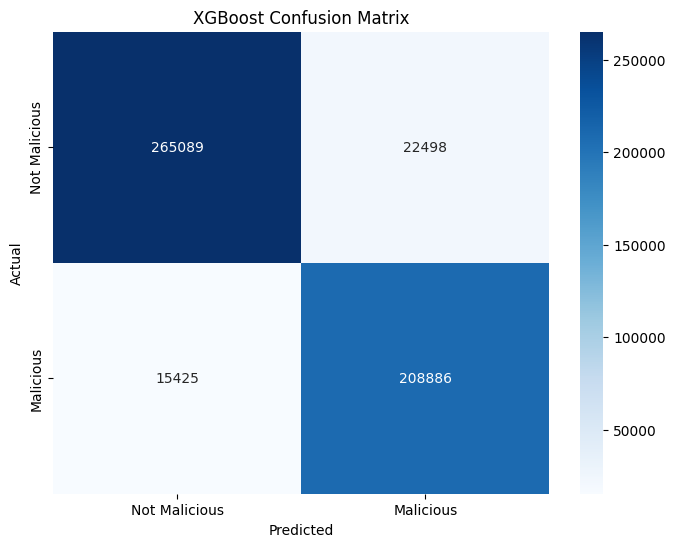

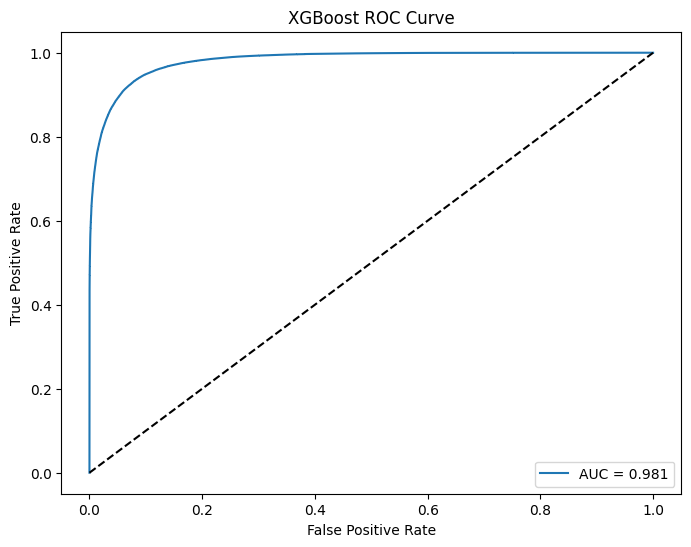

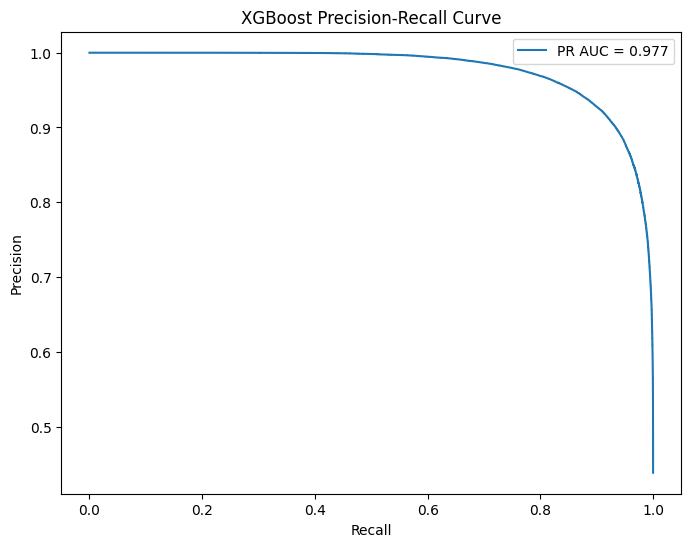


Random Forest Evaluation:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93    287587
         1.0       0.90      0.92      0.91    224311

    accuracy                           0.92    511898
   macro avg       0.92      0.92      0.92    511898
weighted avg       0.92      0.92      0.92    511898



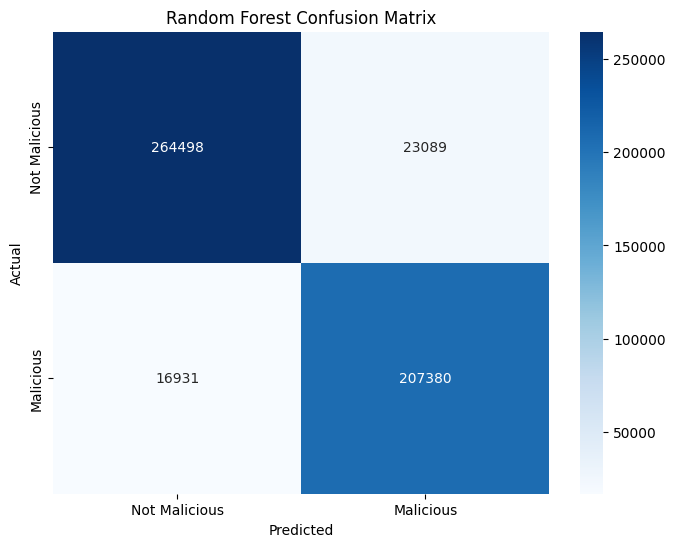

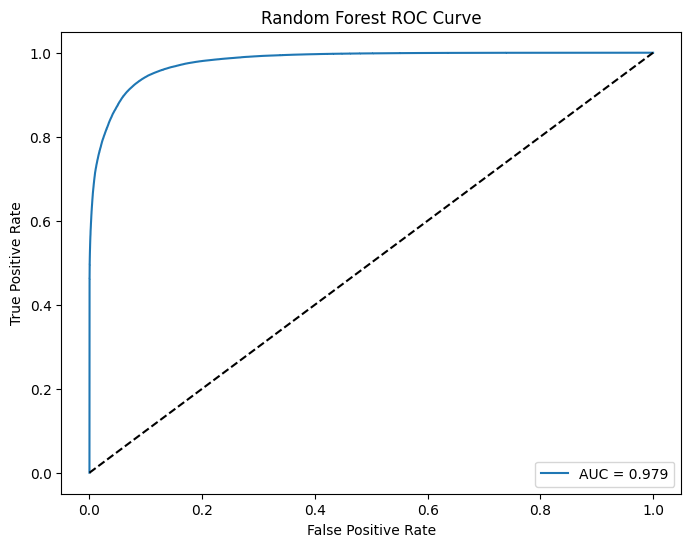

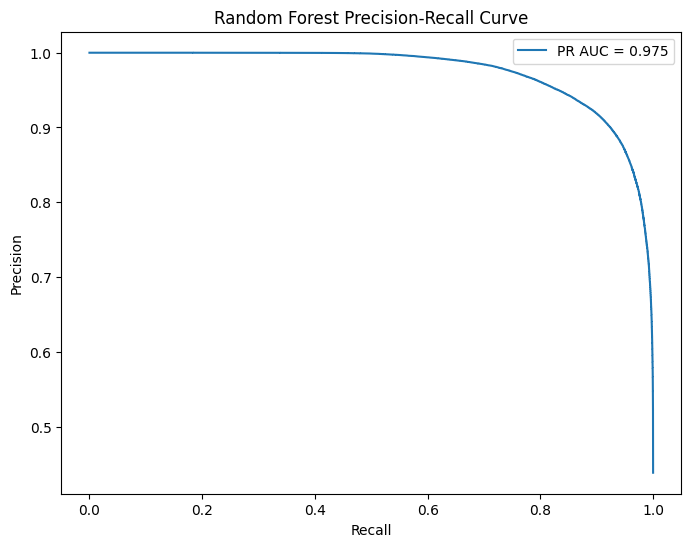


LightGBM Evaluation:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95    287587
         1.0       0.93      0.95      0.94    224311

    accuracy                           0.95    511898
   macro avg       0.95      0.95      0.95    511898
weighted avg       0.95      0.95      0.95    511898



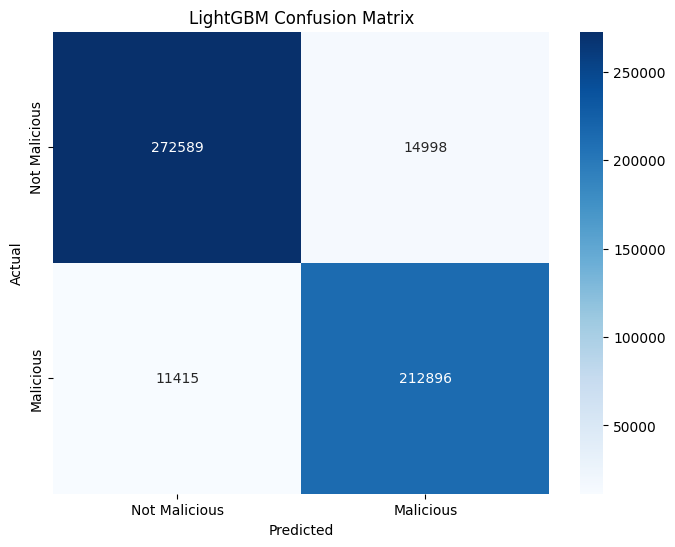

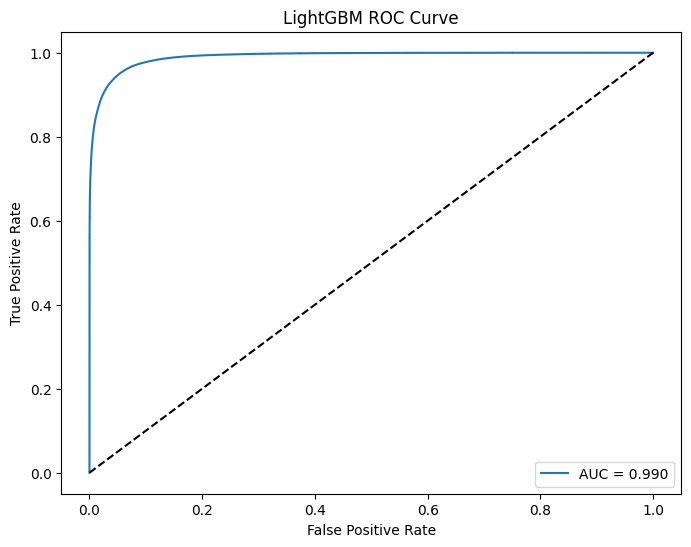

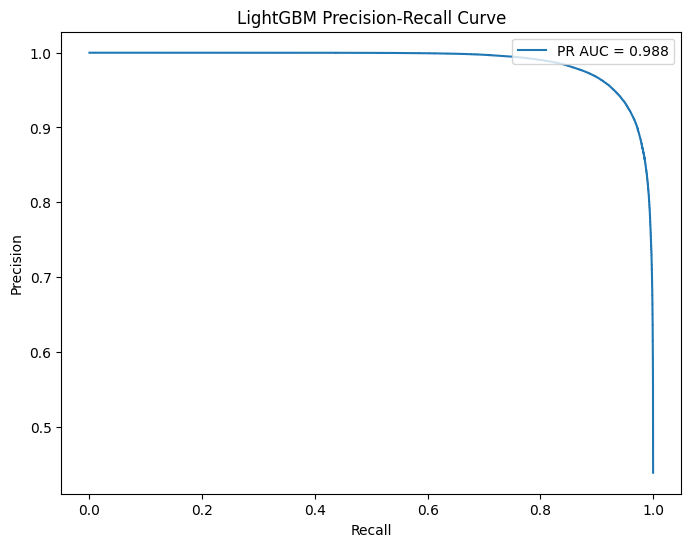


CatBoost Evaluation:
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94    287587
         1.0       0.92      0.93      0.93    224311

    accuracy                           0.94    511898
   macro avg       0.94      0.94      0.94    511898
weighted avg       0.94      0.94      0.94    511898



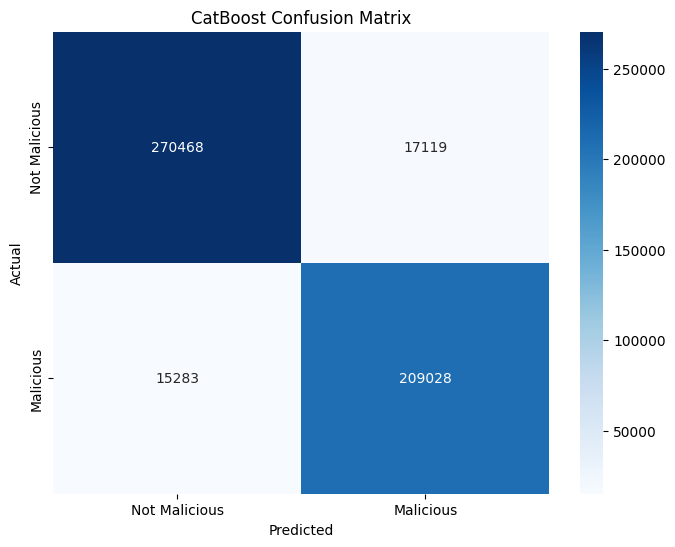

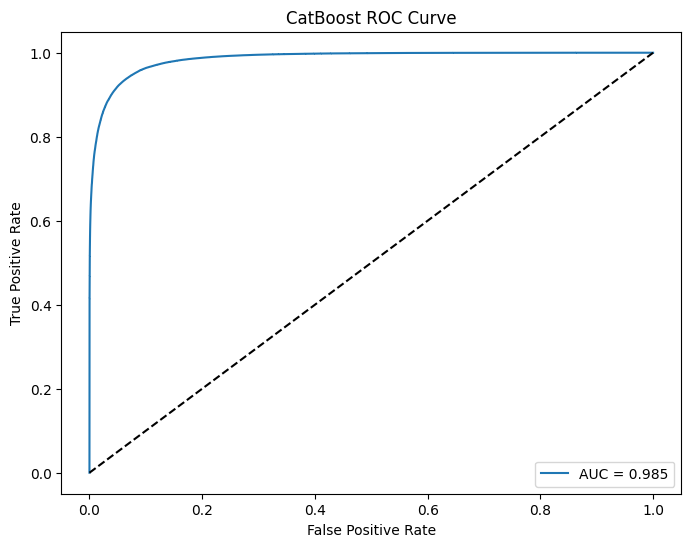

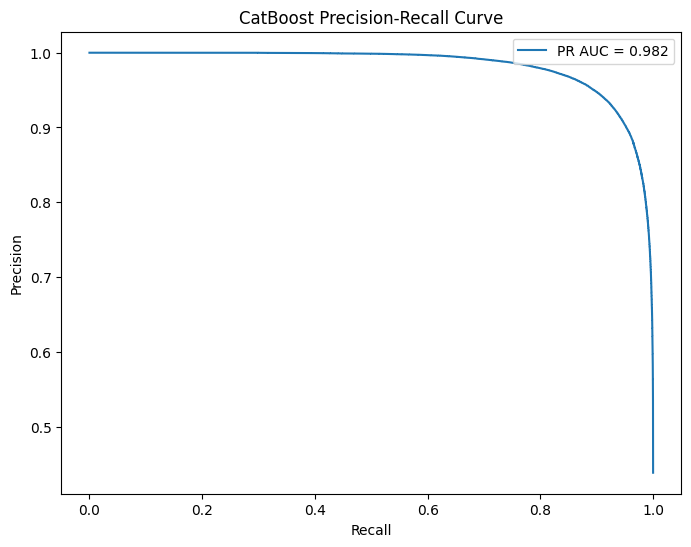


Model Comparison:
           model  accuracy  precision    recall        f1       auc    pr_auc
0        XGBoost  0.925917   0.902768  0.931234  0.916780  0.981025  0.977153
1  Random Forest  0.921820   0.899817  0.924520  0.912001  0.978787  0.974542
2       LightGBM  0.948402   0.934189  0.949111  0.941591  0.990283  0.988385
3       CatBoost  0.936702   0.924301  0.931867  0.928069  0.985264  0.982234


<Figure size 1200x600 with 0 Axes>

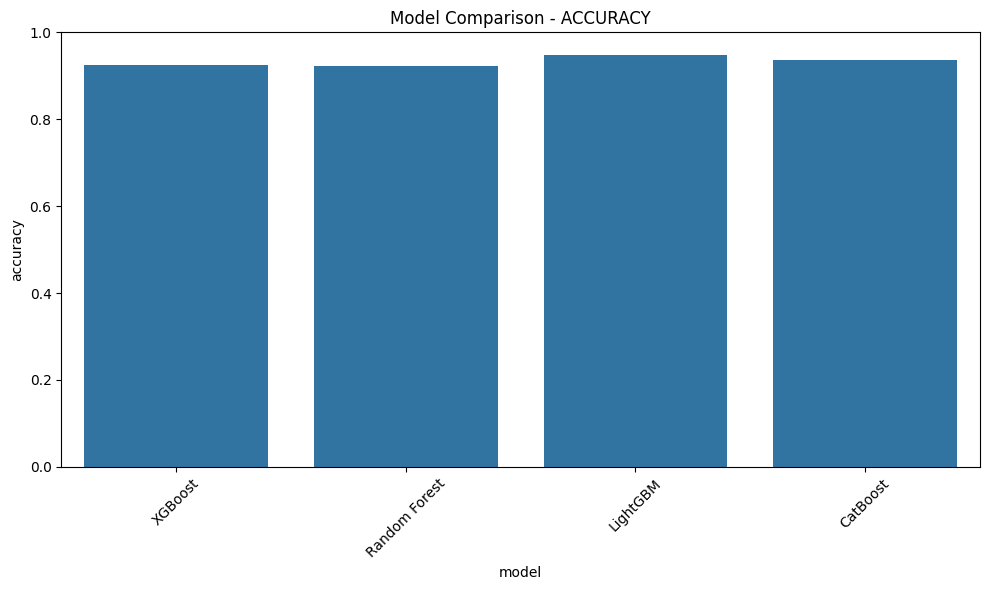

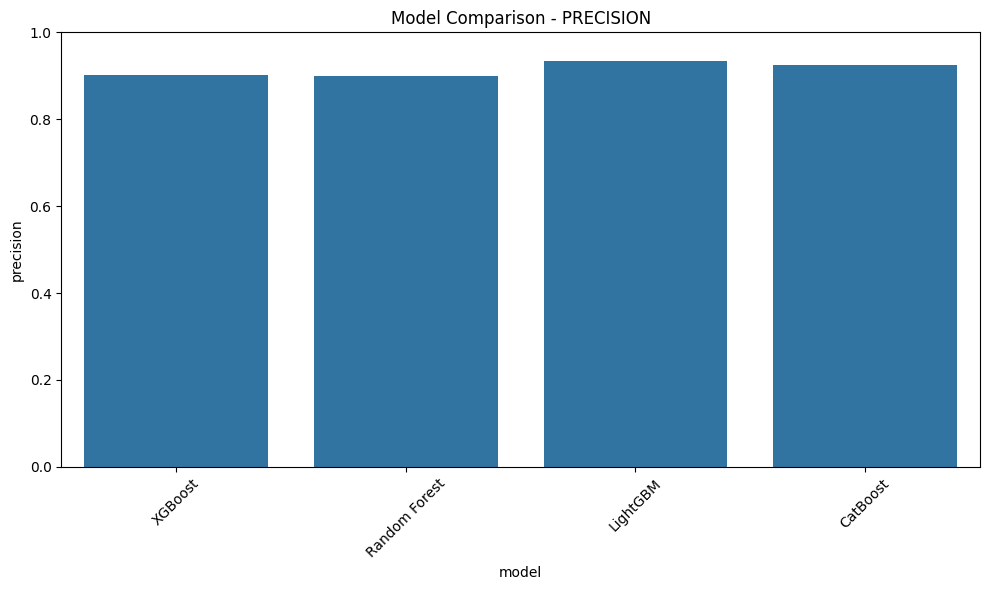

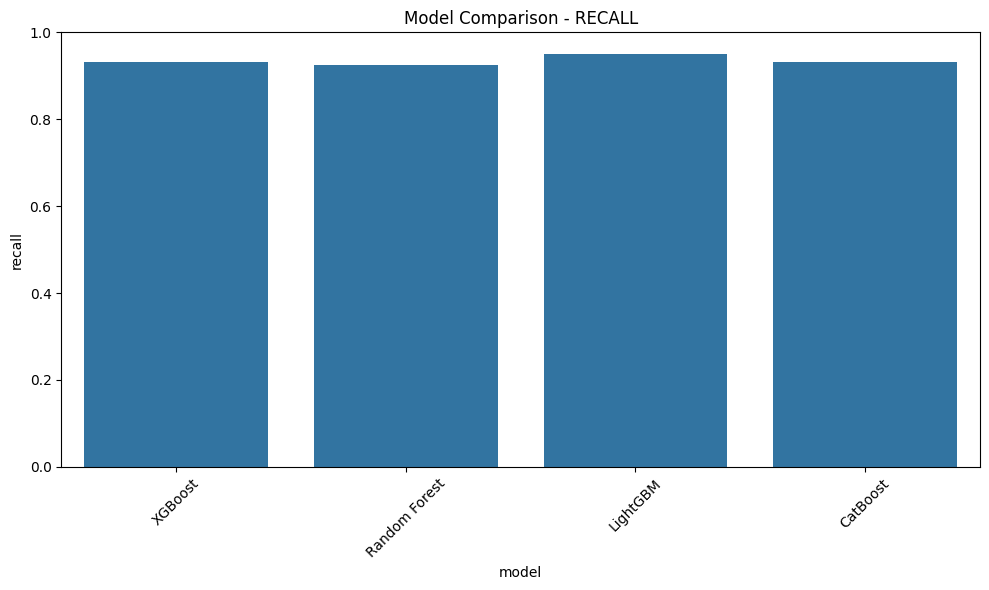

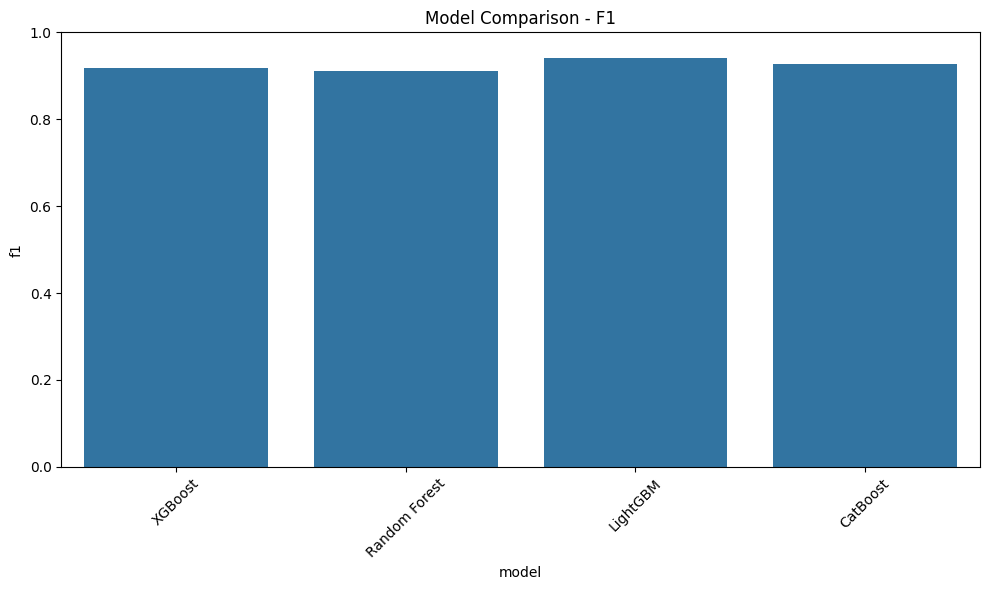

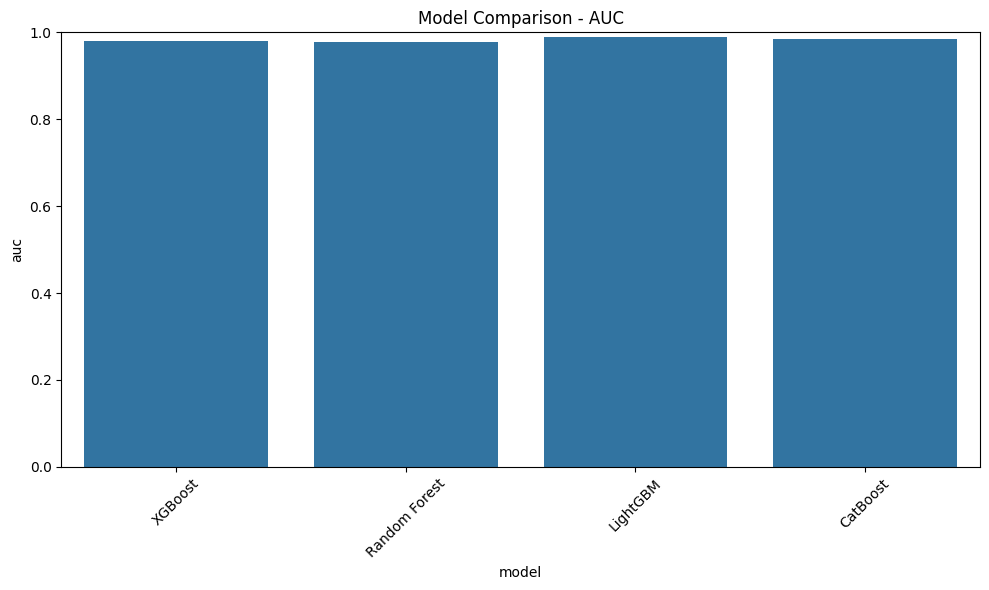

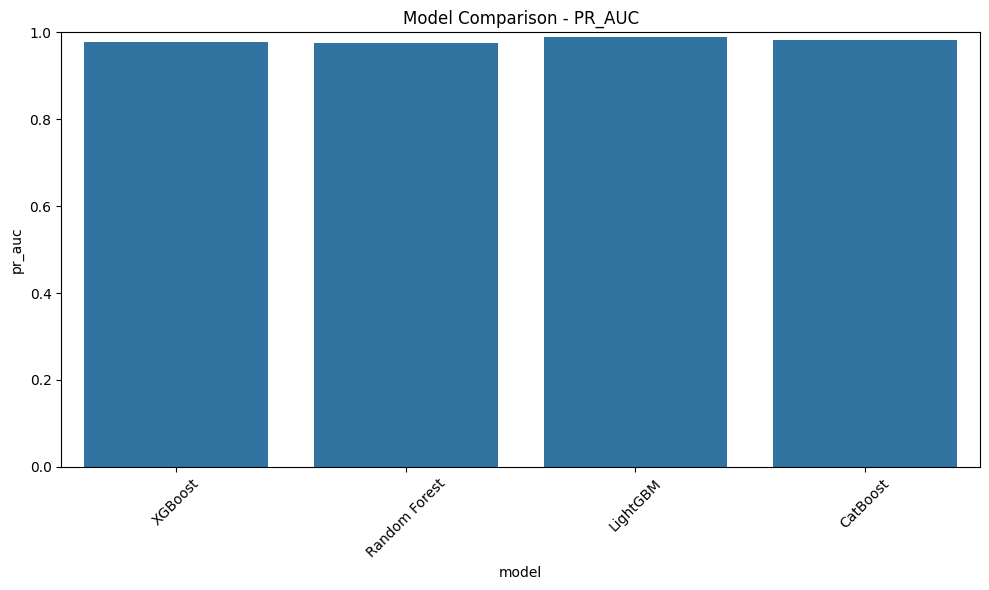

In [66]:
# Compare all models
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score

# Evaluate each model
results = []
results.append(evaluate_model(y_test, y_pred_optimal, y_pred_proba, "XGBoost"))
results.append(evaluate_model(y_test, y_pred_rf_optimal, y_pred_proba_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_lgb_optimal, y_pred_proba_lgb, "LightGBM"))
results.append(evaluate_model(y_test, y_pred_cat_optimal, y_pred_proba_cat, "CatBoost"))

# Create comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'pr_auc']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='model', y=metric, data=results_df)
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()# Create a function to evaluate and compare models
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    # Classification metrics
    print(f"\n{model_name} Evaluation:")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Malicious', 'Malicious'],
                yticklabels=['Not Malicious', 'Malicious'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'pr_auc': pr_auc
    }


Berdasarkan hasil evaluasi dan komparasi antar model yang telah dilakukan, Model LightGBM memiliki performa yang lebih bagus jika dibandingkan dengan model-model XGBoost, CatBoost, dan Random Forest. Maka model LightGBM akan digunakan untuk prediksi & deployment lebih lanjut

### Menyimpan hasil prediksi test menjadi .csv

In [67]:
from joblib import load
import pandas as pd

# Load the LightGBM model
lgb_model_loaded = load("lgb_model.joblib")

# Make predictions on the test data
y_pred_proba_final = lgb_model_loaded.predict(X_test, num_iteration=lgb_model_loaded.best_iteration)

# Use the optimal threshold found earlier for binary predictions
y_pred_final = (y_pred_proba_final >= optimal_threshold_lgb).astype(int)

print("Predicted classes for the test data using LightGBM:")
print(y_pred_final)

print("\nFirst 20 predictions:")
print(y_pred_final[:20])

print("\nClassification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_final))

# Prepare results for CSV output
# Ensure y_test has its original index for aligning with df
y_test_indexed = y_test.copy()

# Create a DataFrame for results
results_df = pd.DataFrame({
    'url': df.loc[X_test.index, 'url'], # Get original URLs using the index of X_test
    'actual_label': y_test_indexed,
    'predicted_proba': y_pred_proba_final,
    'predicted_label': y_pred_final,
    'is_correct_prediction': (y_test_indexed == y_pred_final) # Add this new column
})

# Save to CSV
results_df.to_csv('lightgbm_predictions.csv', index=False)
print("\nPredictions saved to lightgbm_predictions.csv")
display(results_df.head())

Predicted classes for the test data using LightGBM:
[0 0 1 ... 0 0 1]

First 20 predictions:
[0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0 1]

Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95    287587
         1.0       0.93      0.95      0.94    224311

    accuracy                           0.95    511898
   macro avg       0.95      0.95      0.95    511898
weighted avg       0.95      0.95      0.95    511898


Predictions saved to lightgbm_predictions.csv


,url,actual_label,predicted_proba,predicted_label,is_correct_prediction
549851,https://www.lesueurministorage.com/,0.0,0.257280,0,True
2356999,https://www.eu-robotics.net/robotics_forum/new...,0.0,0.013279,0,True
707958,http://amazon-sicherheitsaktualisierung.de/383...,1.0,0.998721,1,True
545160,https://www.websiteinvestments.com.au/tag/gifts/,0.0,0.146810,0,True
2084035,http://www.te5.com/bns/2017/175769.html,0.0,0.008345,0,True
